In [1]:
!pip install matplotlib seaborn pandas numpy

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import re

In [3]:
%matplotlib inline
sns.set_theme(style="whitegrid")

In [4]:
def load_tps_data(json_path):
    """Load JSON and flatten it into a tidy Pandas DataFrame."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    rows = []
    for entry in data:
        drift_lvl = entry.get("Drift_Level")
        for key, value in entry.items():
            if key == "Drift_Level" or value is None:
                continue
            
            parts = key.split(" (")
            prompt_name = parts[0]
            category = parts[1].replace(")", "")
            
            if isinstance(value, dict):
                for var_name, score in value.items():
                    rows.append({"Drift": drift_lvl, "Category": category, "Prompt": prompt_name, "Variant": var_name, "Score": score})
            else:
                rows.append({"Drift": drift_lvl, "Category": category, "Prompt": prompt_name, "Variant": "V0", "Score": value})
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df['Prompt_Num'] = df['Prompt'].str.extract('(\d+)').astype(int)
        df = df.sort_values(['Drift', 'Category', 'Prompt_Num'])
    return df

<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nitin\AppData\Local\Temp\ipykernel_26568\639481253.py:25: SyntaxWarning: invalid escape sequence '\d'
  df['Prompt_Num'] = df['Prompt'].str.extract('(\d+)').astype(int)


In [5]:
def plot_stability_view(df, model_name):
    """1. Separate Multi-Line Chart."""
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=df, x="Drift", y="Score", hue="Category", marker="o")
    plt.title(f"Stability View: {model_name}", fontsize=14, pad=15)
    plt.ylim(30, 100)
    plt.ylabel("Average TPS Score")
    # Move legend to the bottom to avoid covering lines
    plt.legend(title="Category", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    plt.show()

In [6]:
def plot_variance_view(df, model_name):
    """
    2. Separate Box Plot (Final Fix).
    X-axis: Categories
    Hue: Drift Levels
    Fix: Uses Matplotlib's autoscale with a margin to ensure no boxes are cut.
    """
    plt.figure(figsize=(14, 7))
    
    # Create the plot
    # showfliers=False removes the individual dots that cause extreme squashing
    ax = sns.boxplot(
        data=df, 
        x="Category", 
        y="Score", 
        hue="Drift", 
        palette="viridis",
        showfliers=False, 
        whis=1.5
    )
    
    # --- THE FIX: DYNAMIC MARGINS ---
    # Instead of manual ylim, we tell Matplotlib to add 10% padding 
    # around the actual data plotted (the boxes and whiskers)
    ax.use_sticky_edges = False
    ax.margins(y=0.1) 
    
    # Optional: Ensure we don't show scores above 100 if the margin pushes it
    current_ymin, current_ymax = ax.get_ylim()
    ax.set_ylim(min(current_ymin, 0), max(current_ymax, 105))

    # --- Formatting ---
    plt.title(f"Score Variance by Category: {model_name}", fontsize=15, pad=20)
    plt.ylabel("TPS Score")
    plt.xlabel("Task Category")
    
    # Grid lines for horizontal comparison
    plt.grid(True, axis='y', linestyle='--', alpha=0.4)
    
    # Clean Legend at the bottom
    plt.legend(title="Drift Level", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=6)
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_bar_grid(df, model_name):
    levels = sorted(df['Drift'].unique())
    fig, axes = plt.subplots(3, 2, figsize=(25, 20), sharey=True)
    axes = axes.flatten()
    
    for i, lvl in enumerate(levels):
        subset = df[df['Drift'] == lvl]
        sns.barplot(data=subset, x="Prompt", y="Score", hue="Category", ax=axes[i])
        axes[i].set_title(f"Drift Level {lvl}", fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        # Move legend below each subplot so it doesn't cover bars
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize='small')
        
    plt.suptitle(f"Category Comparisons (2x3 Grid): {model_name}", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_heatmap_grid(df, model_name):
    levels = sorted(df['Drift'].unique())
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, lvl in enumerate(levels):
        subset = df[df['Drift'] == lvl]
        pivot_df = subset.pivot_table(index="Prompt", columns="Category", values="Score", aggfunc='mean')
        
        # Numeric Sort for Y-axis
        pivot_df['temp_sort'] = pivot_df.index.str.extract('(\d+)').astype(int).values
        pivot_df = pivot_df.sort_values('temp_sort').drop(columns='temp_sort')
        
        sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", vmin=0, vmax=100, fmt=".1f", ax=axes[i])
        axes[i].set_title(f"Anomaly Heatmap: Drift Level {lvl}", fontweight='bold')
        
    plt.suptitle(f"Anomaly Heatmap Grid: {model_name}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nitin\AppData\Local\Temp\ipykernel_26568\2998807695.py:11: SyntaxWarning: invalid escape sequence '\d'
  pivot_df['temp_sort'] = pivot_df.index.str.extract('(\d+)').astype(int).values


In [9]:
def run_visualizations(base_tps_dir):
    base_path = Path(base_tps_dir)
    for json_file in base_path.glob("**/tps_scores_structured.json"):
        model_name = json_file.parent.name
        print(f"\n{'='*80}\nREPORT FOR: {model_name}\n{'='*80}")
        
        df = load_tps_data(json_file)
        if df.empty: continue
            
        plot_stability_view(df, model_name)
        plot_variance_view(df, model_name)
        plot_bar_grid(df, model_name)
        plot_heatmap_grid(df, model_name)


REPORT FOR: Meta-Llama-3-8B-Instruct_4bit


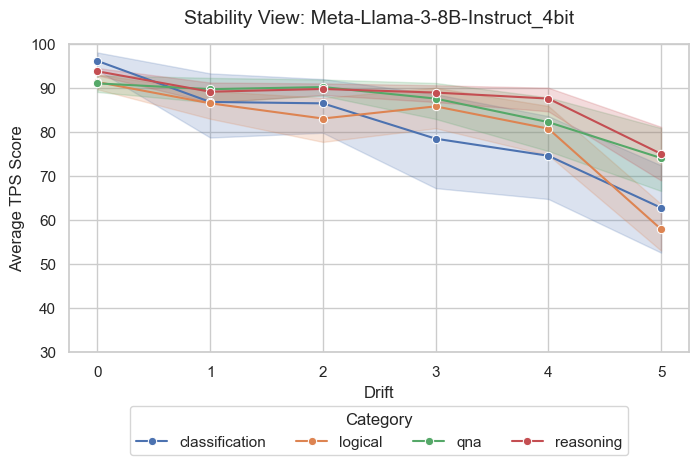

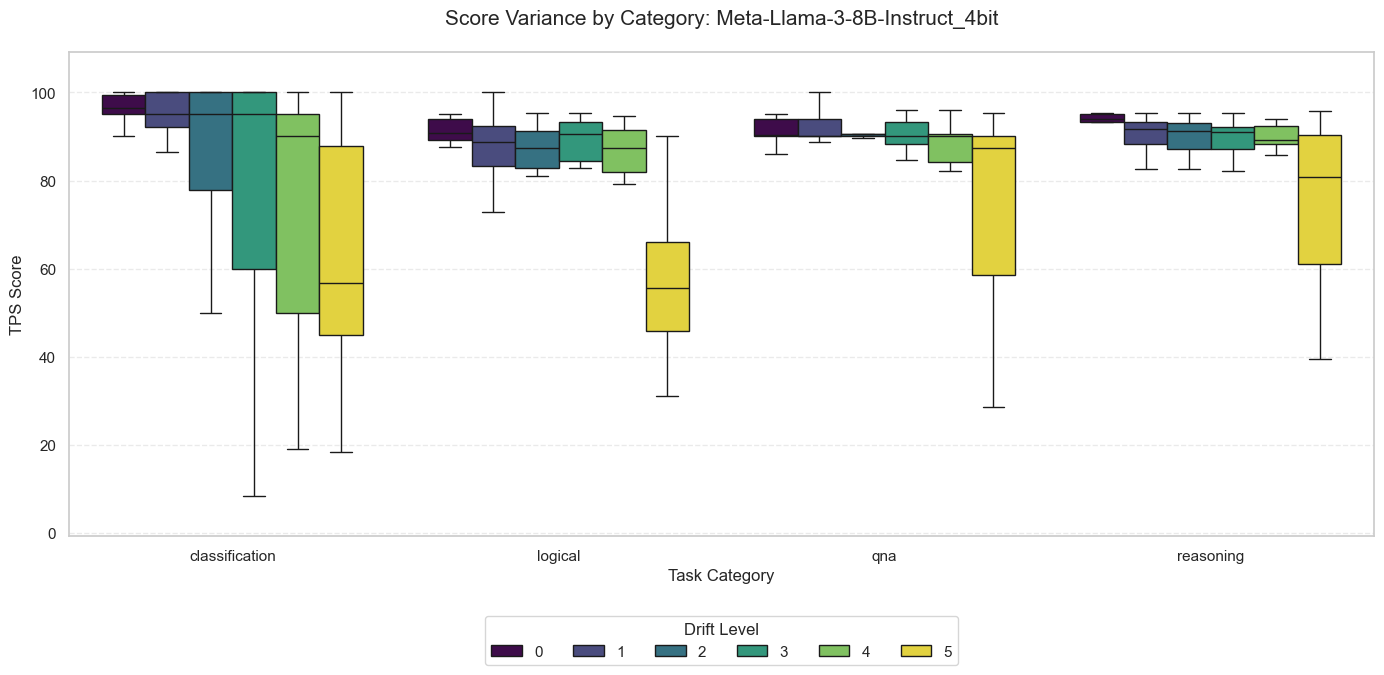

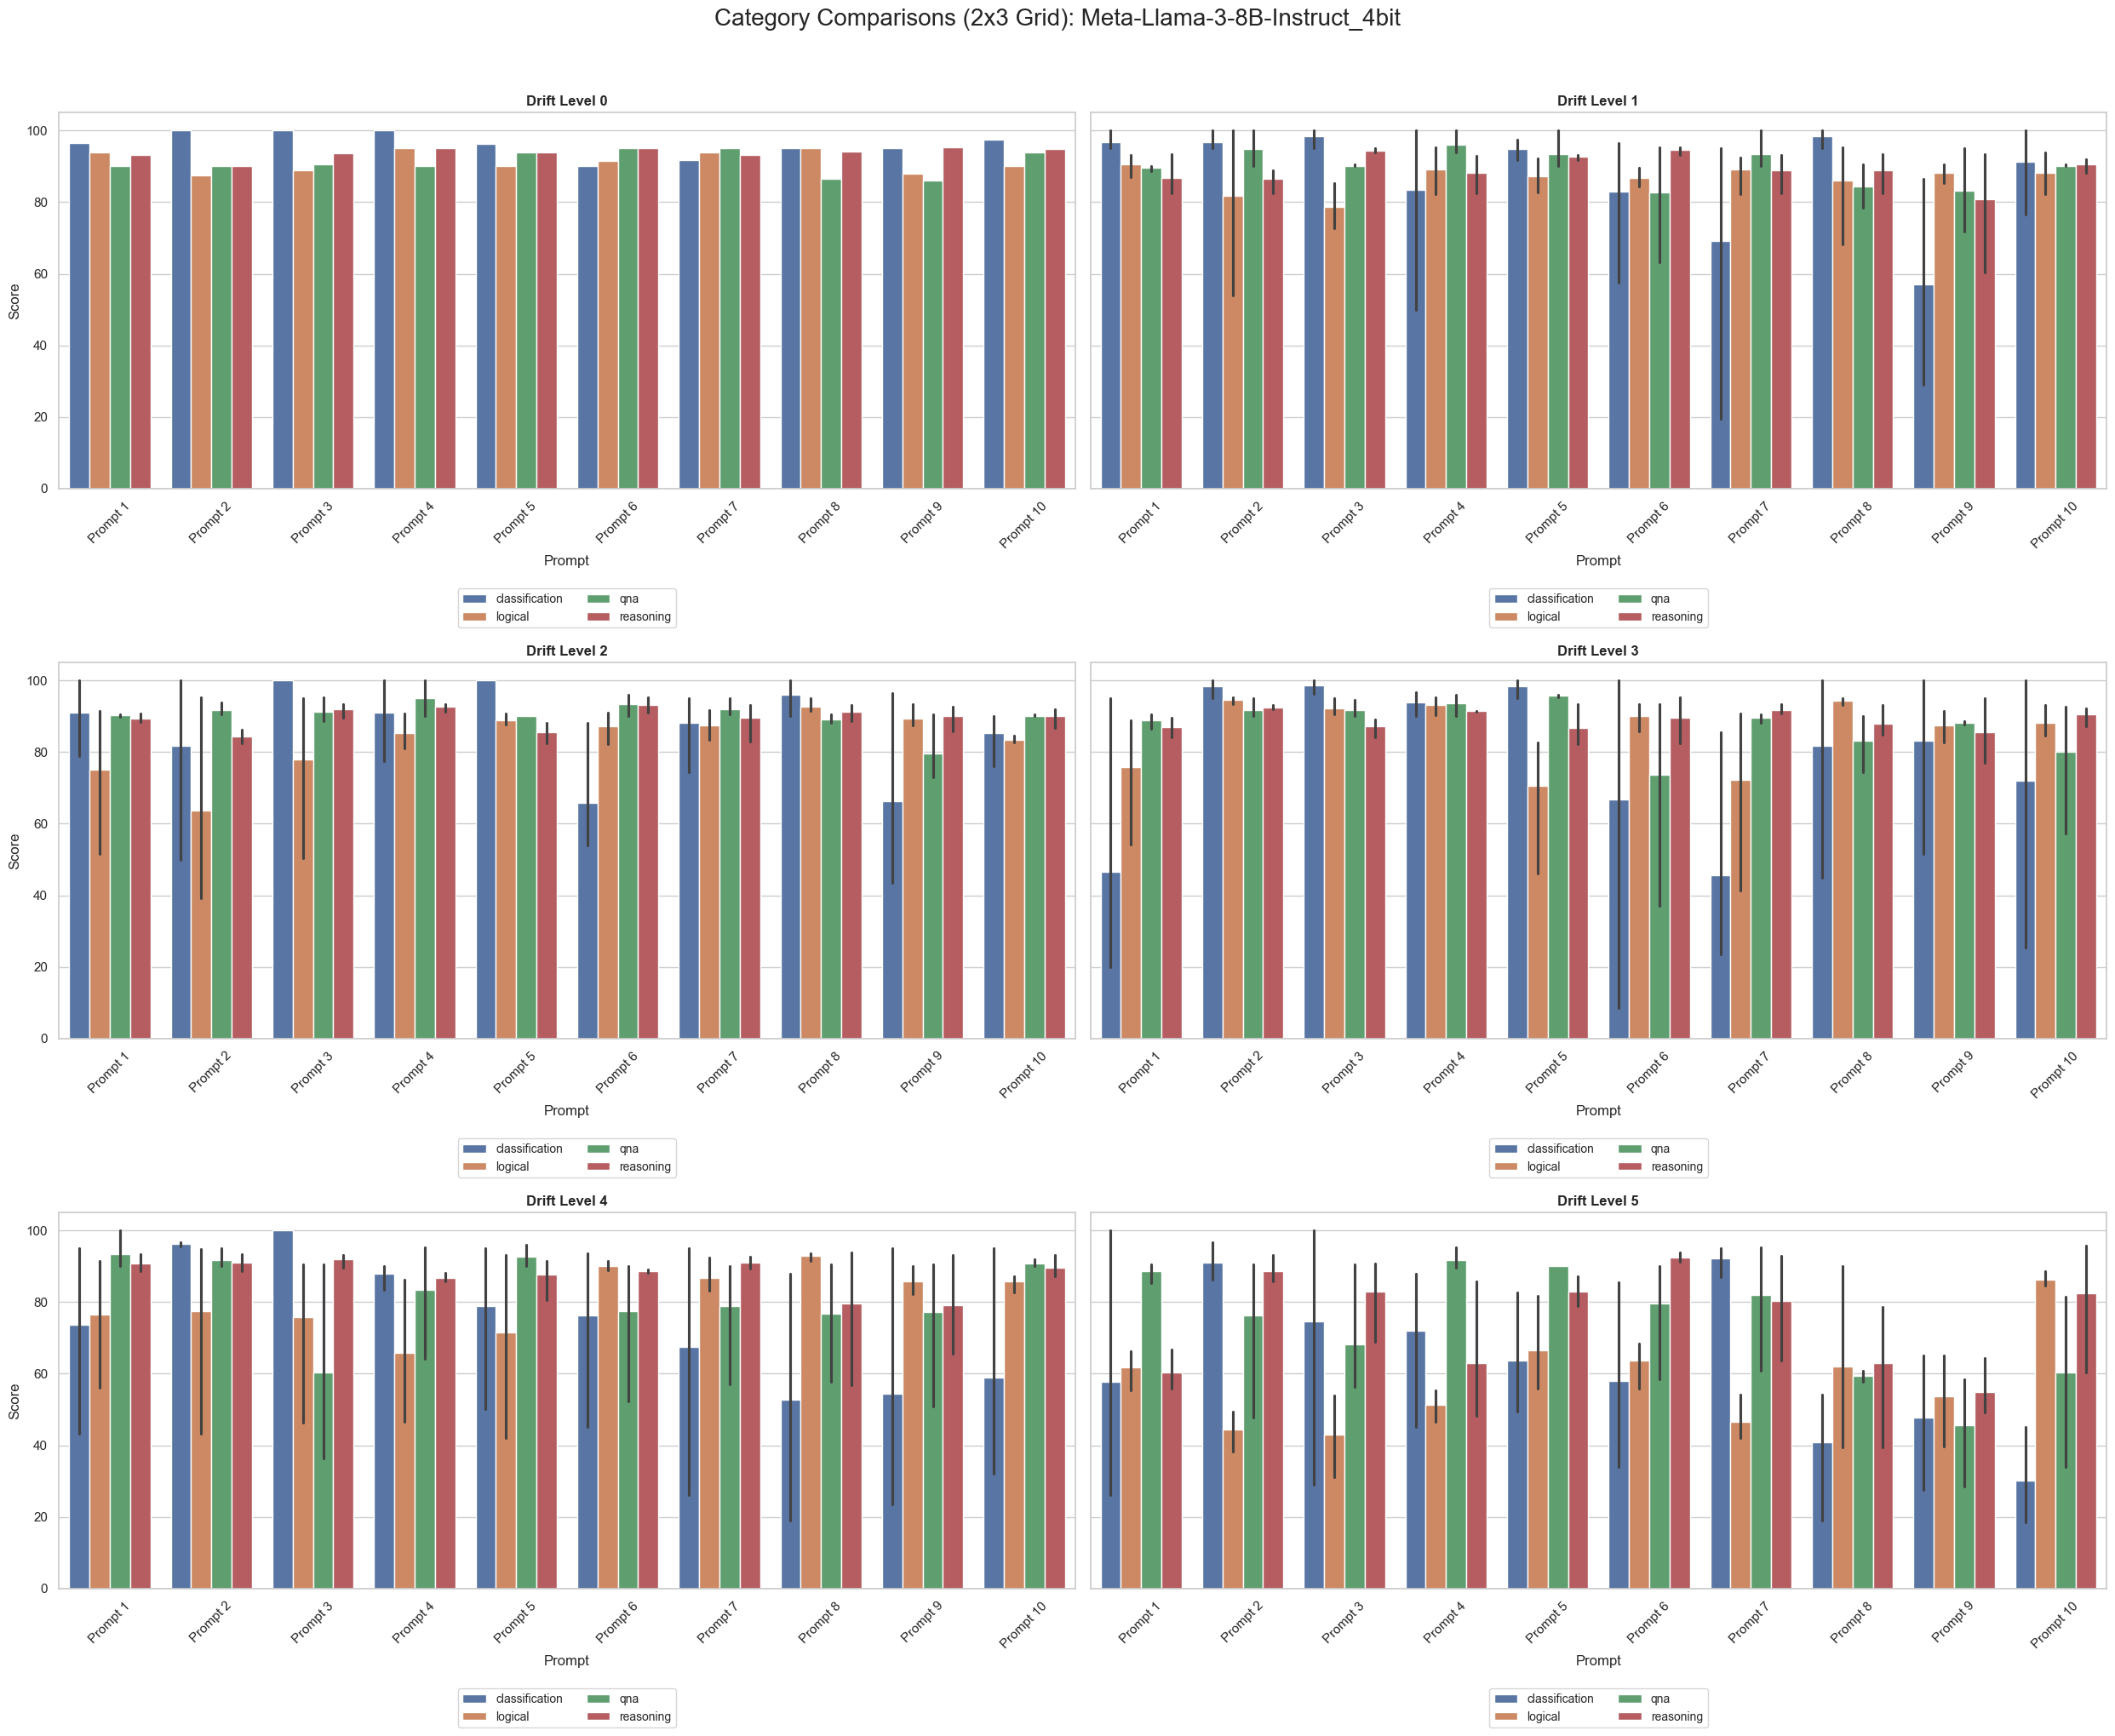

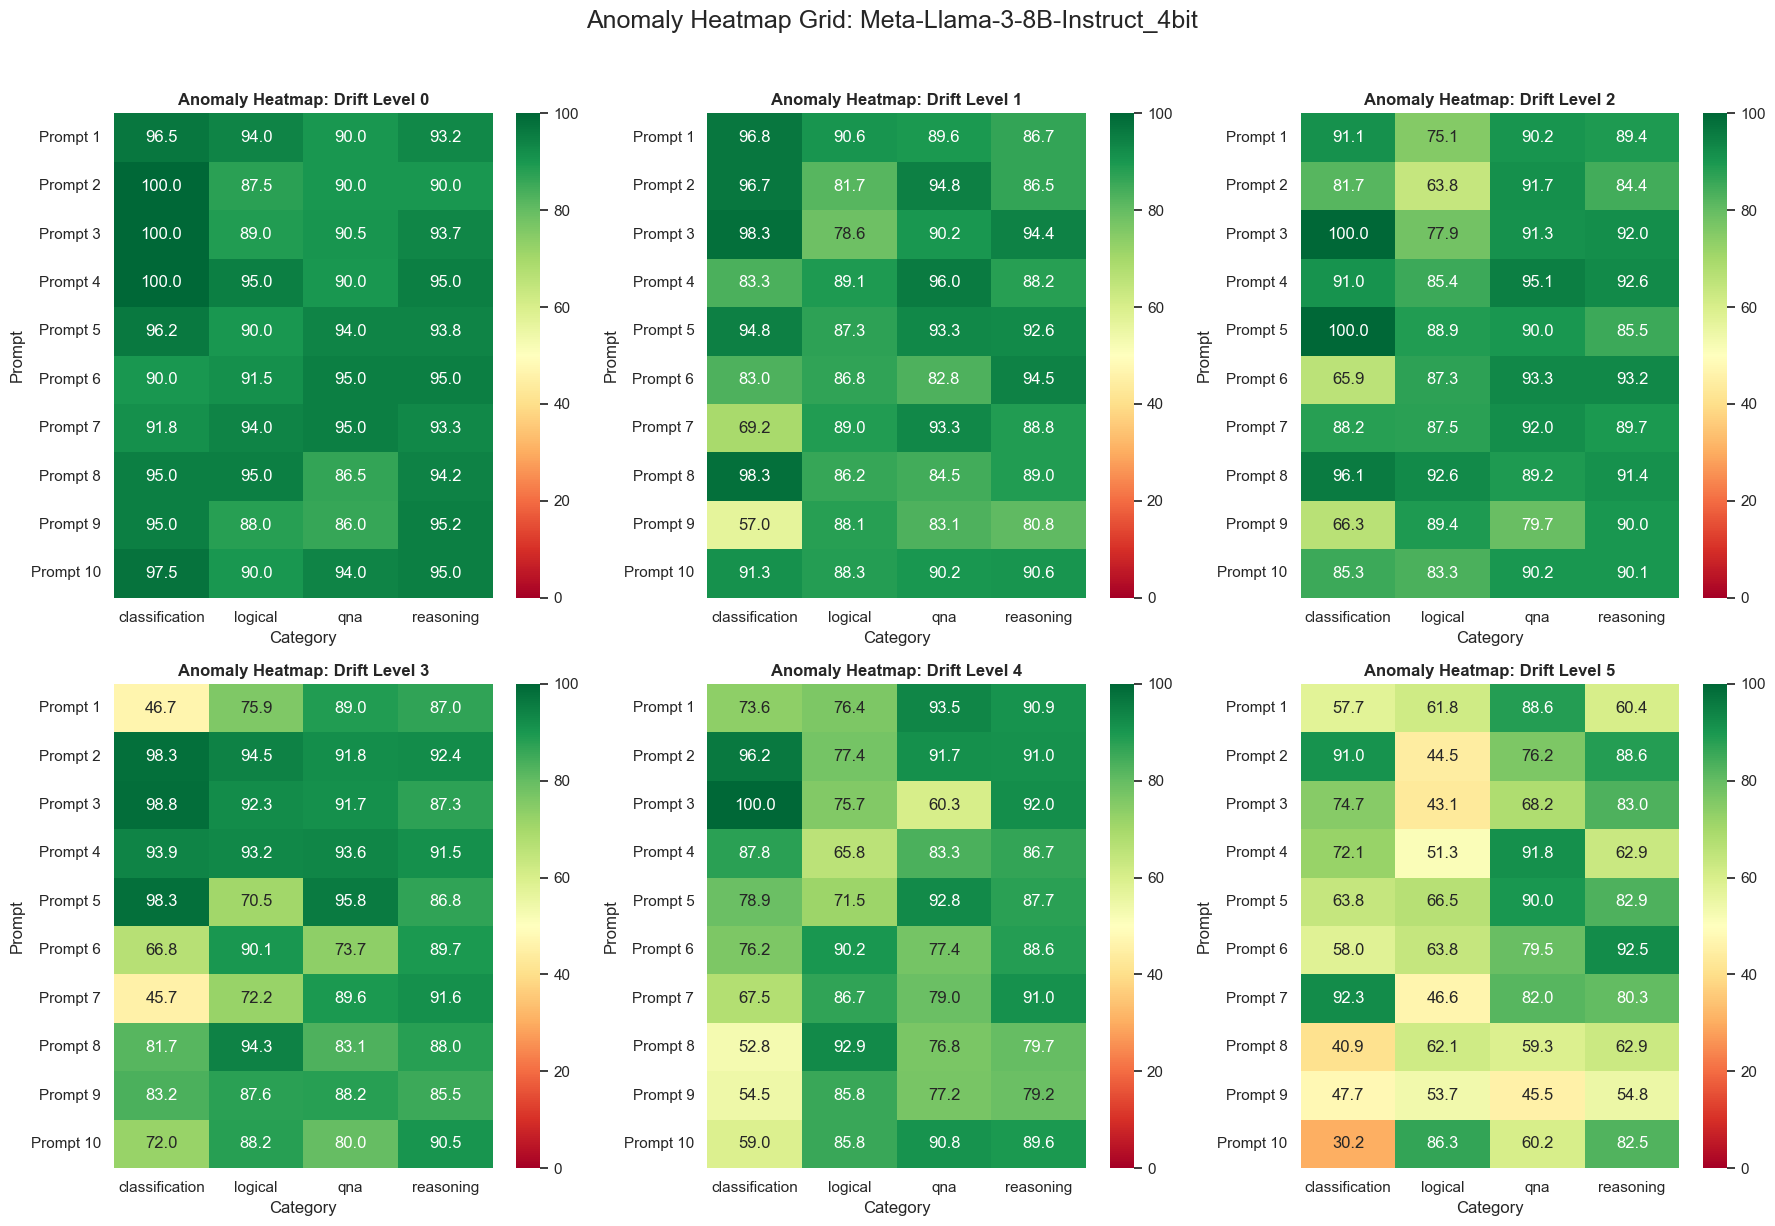


REPORT FOR: Meta-Llama-3-8B-Instruct_8bit


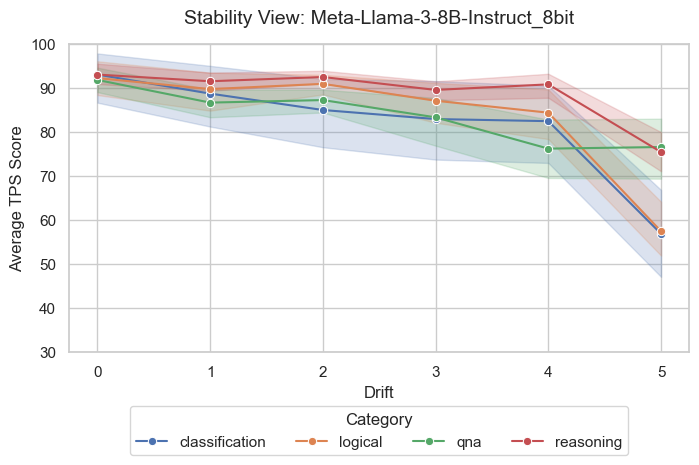

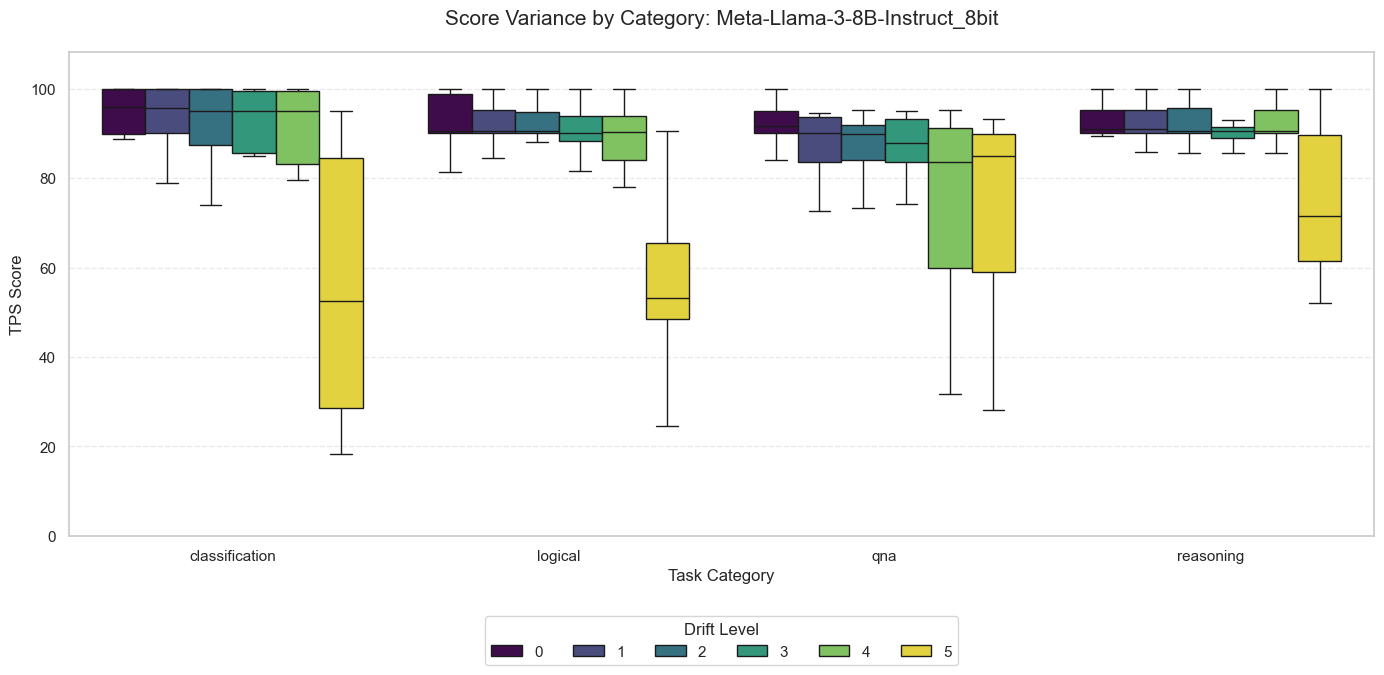

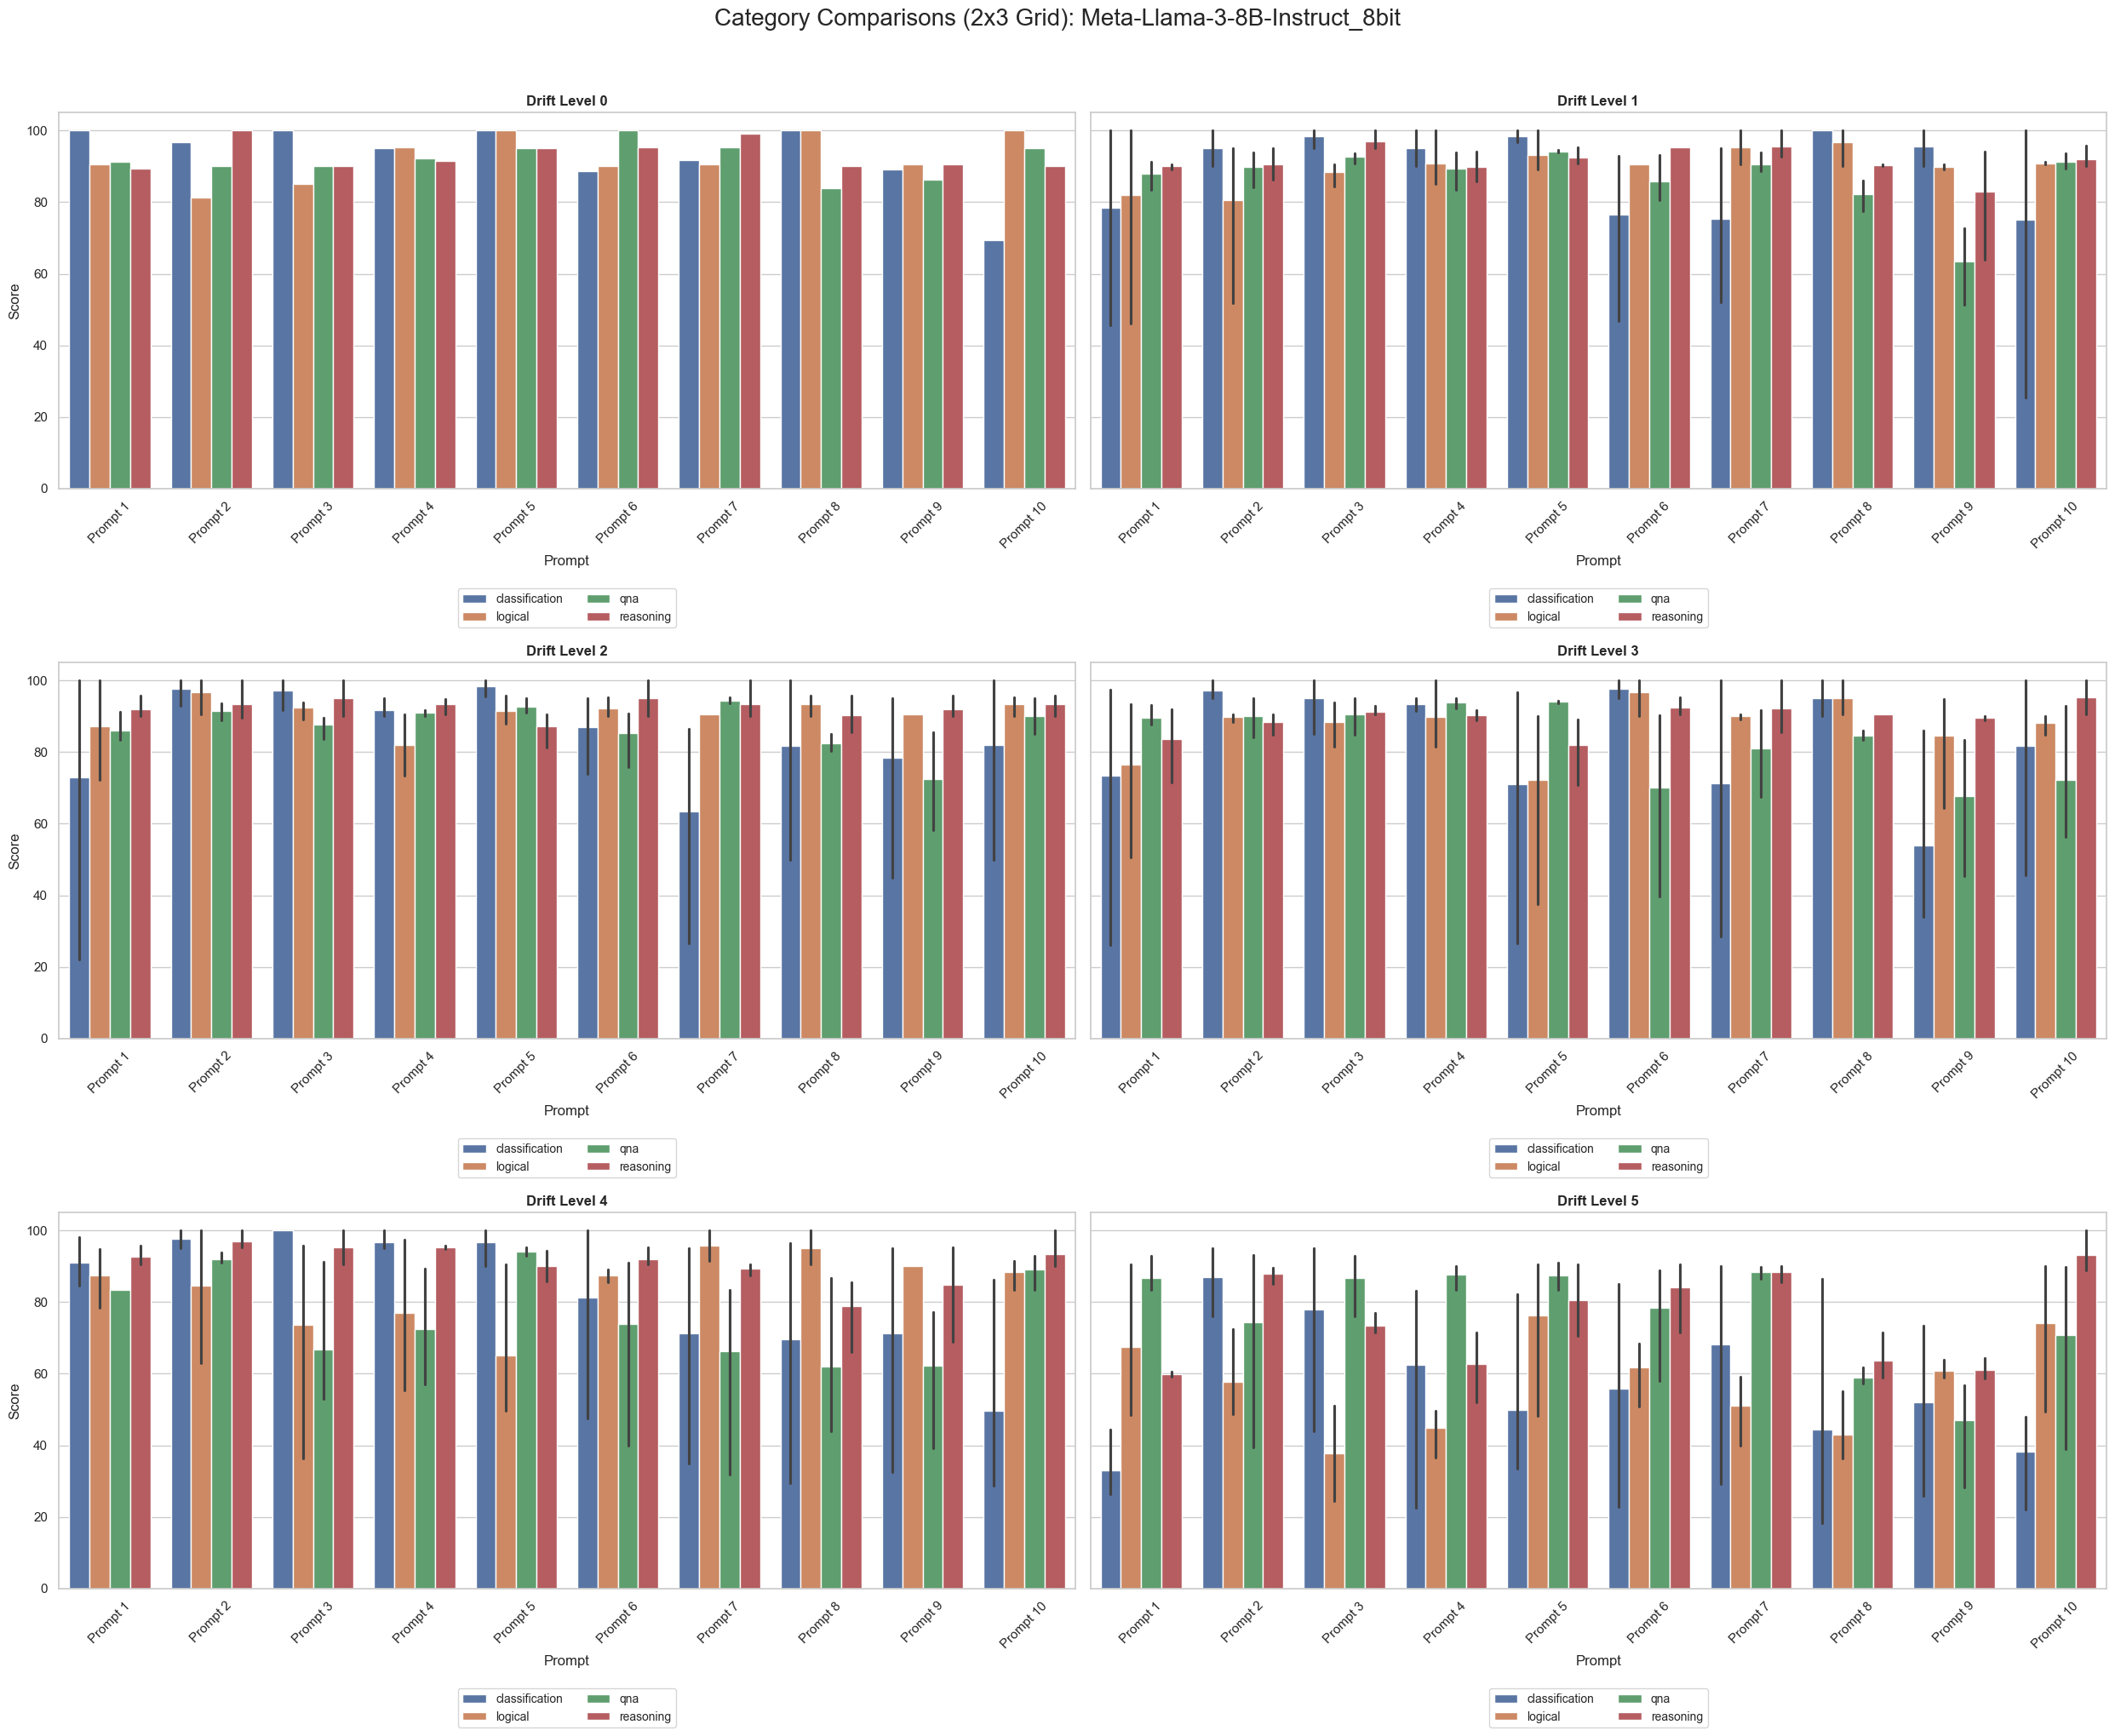

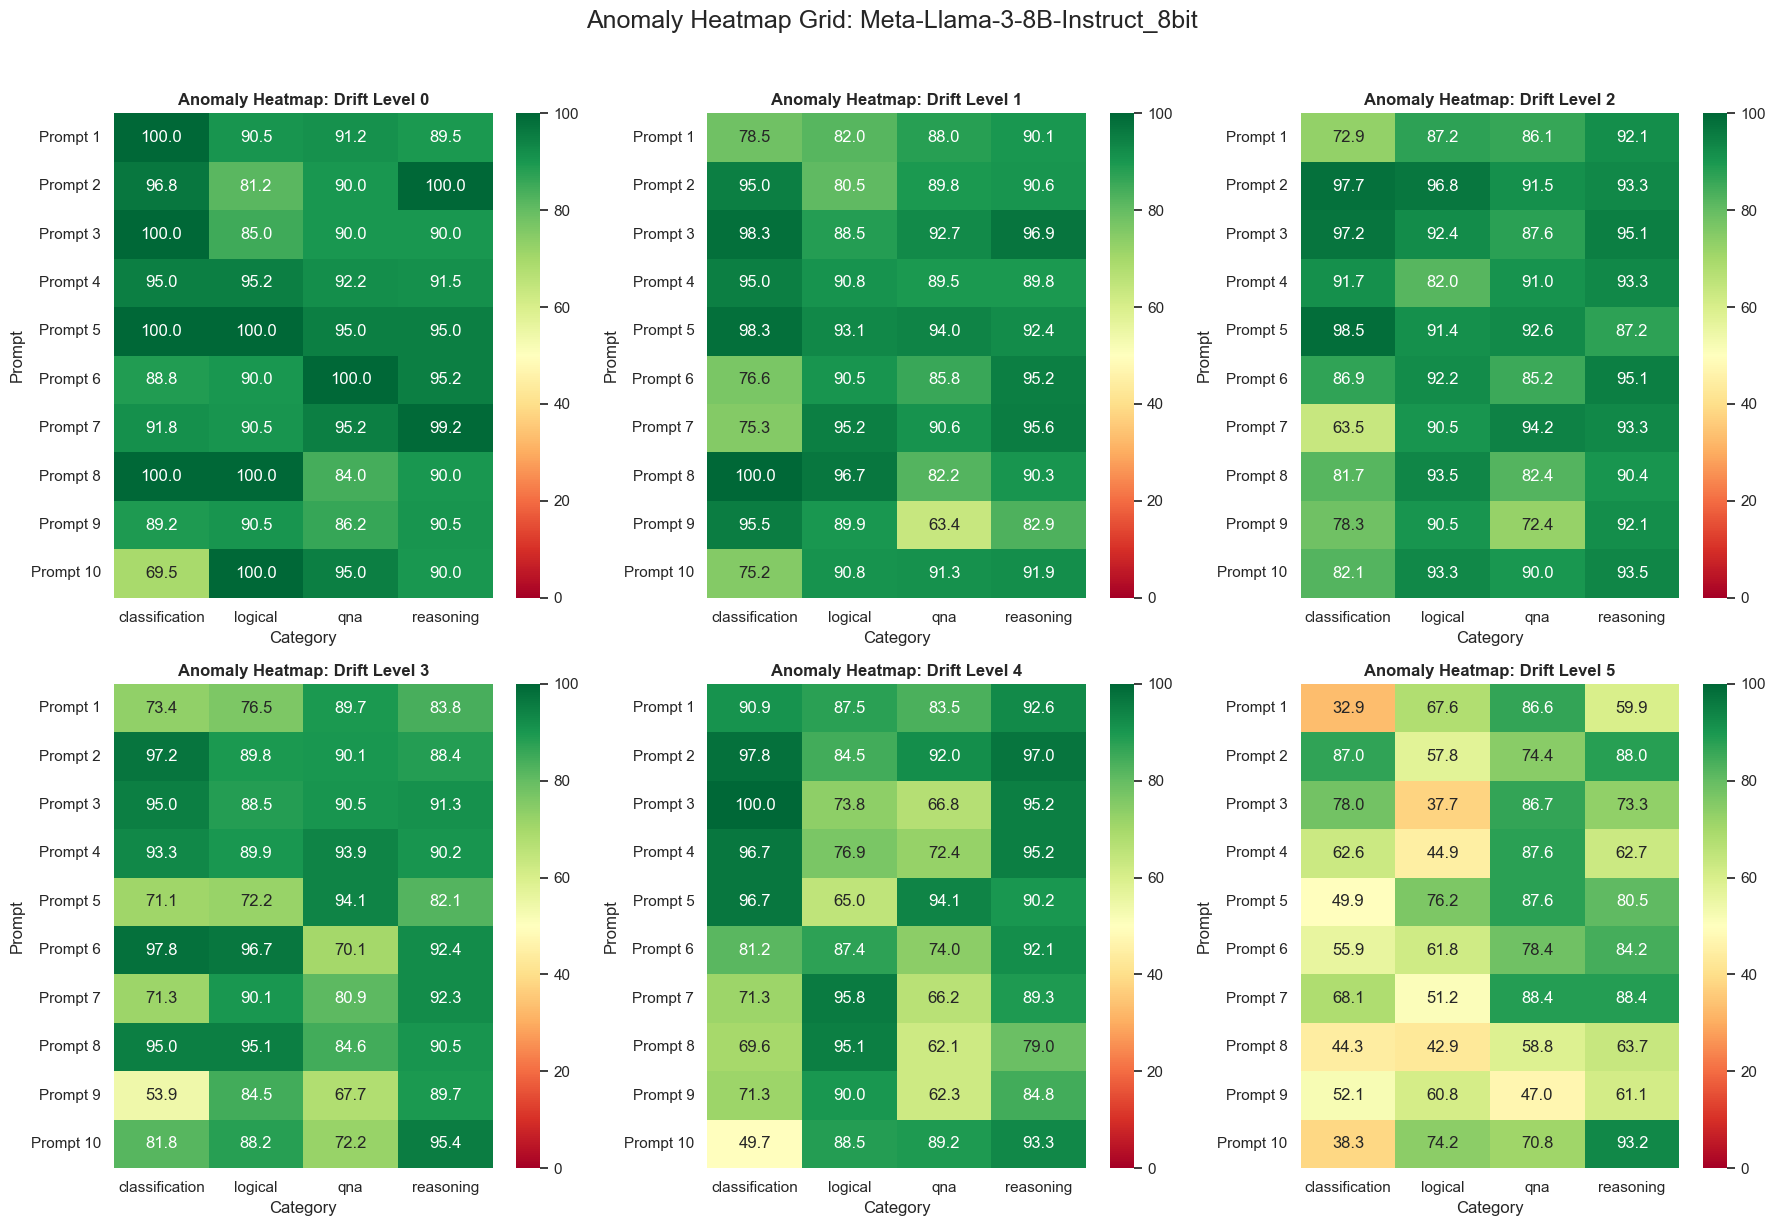


REPORT FOR: Meta-Llama-3-8B-Instruct_fp16


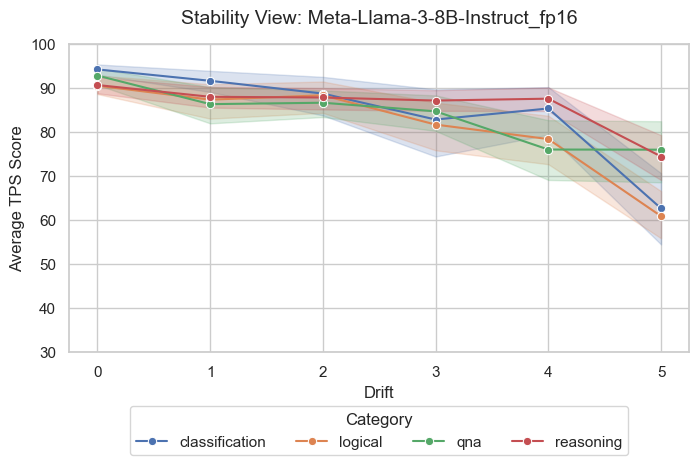

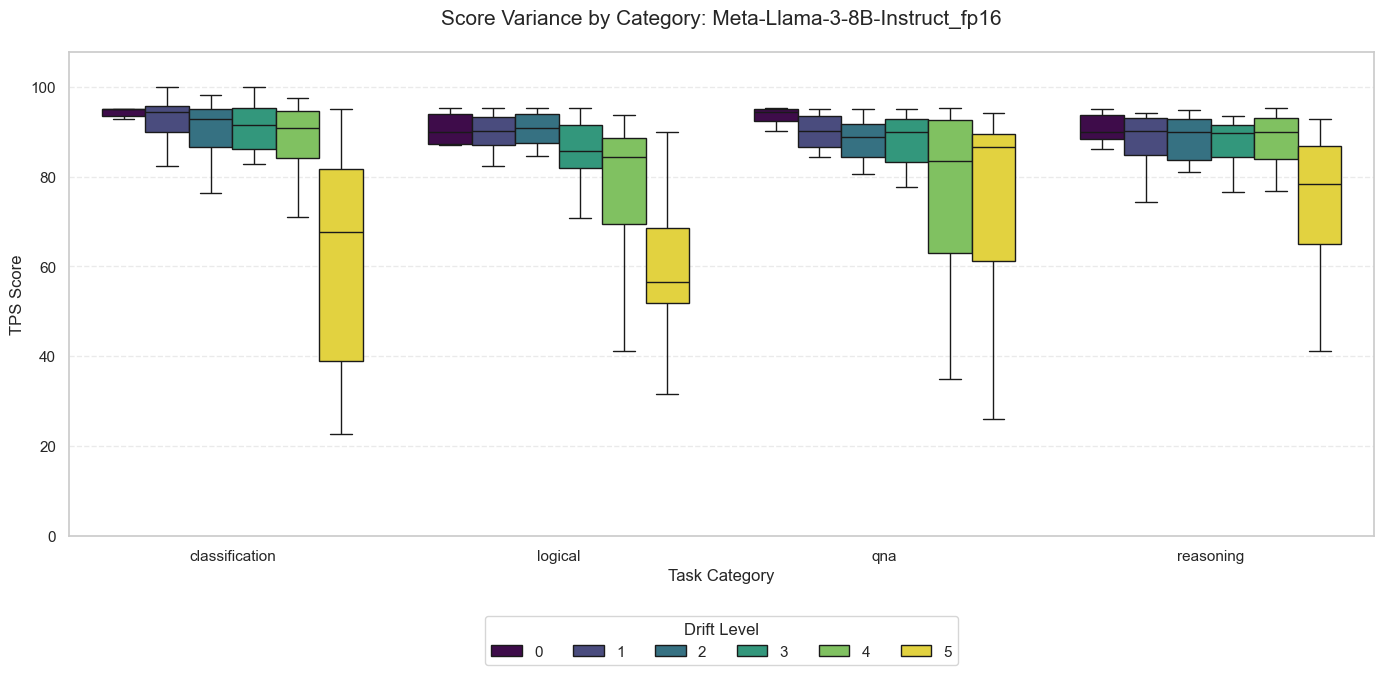

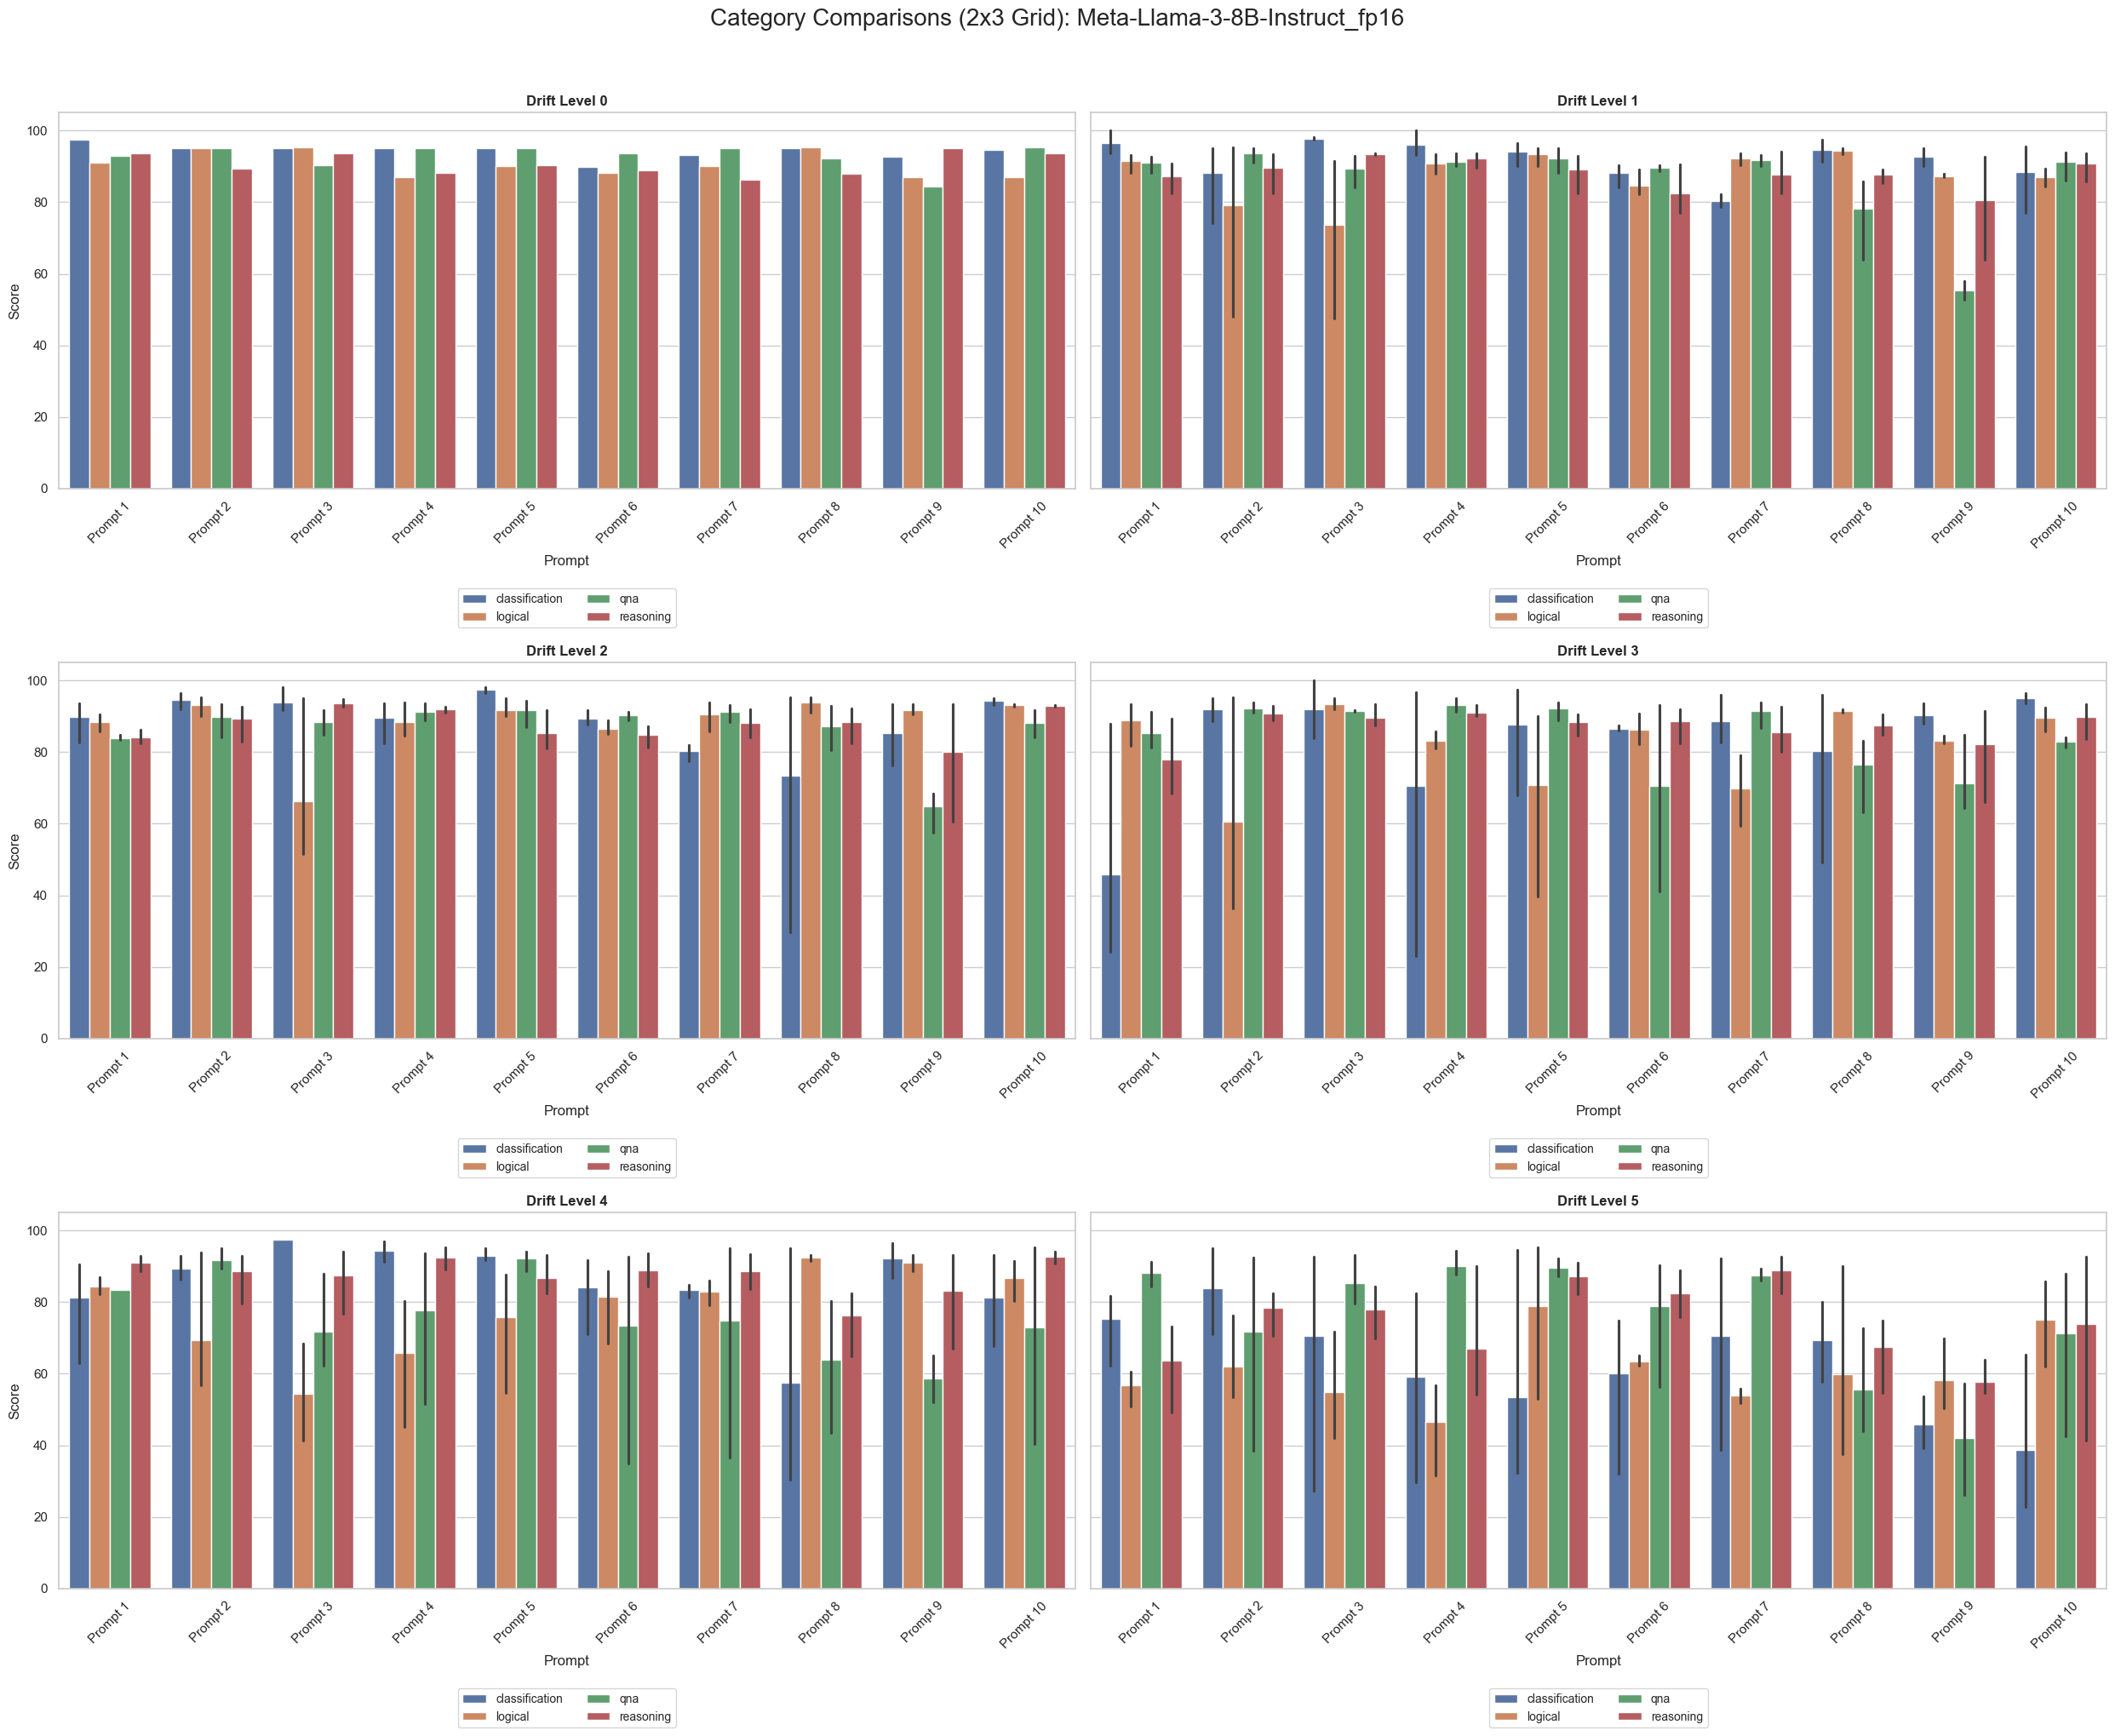

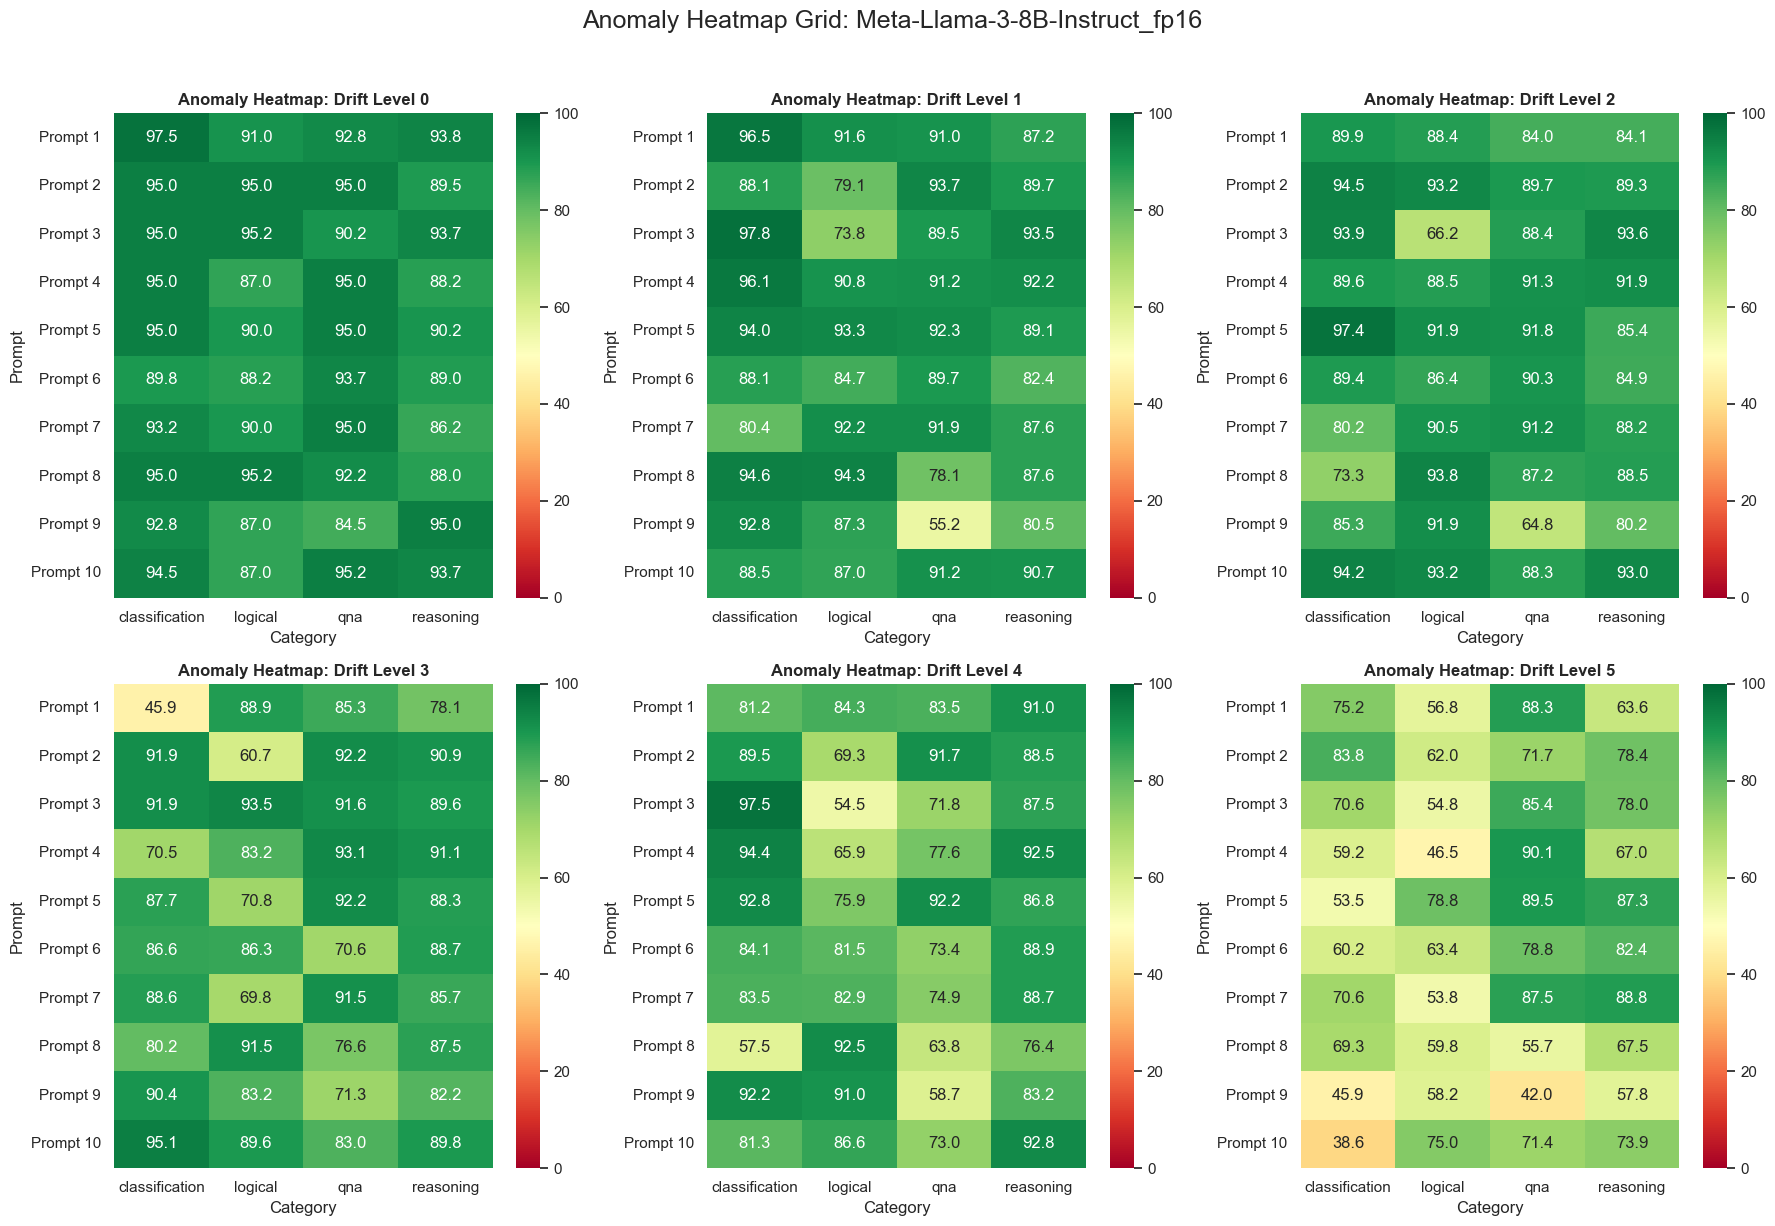


REPORT FOR: Phi-3-mini-4k-instruct_4bit


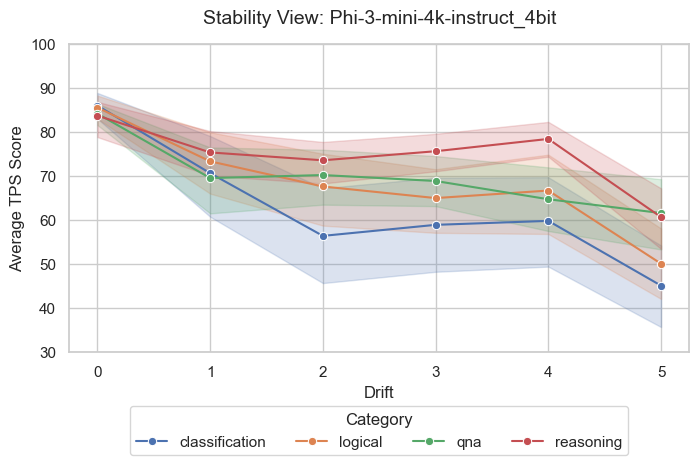

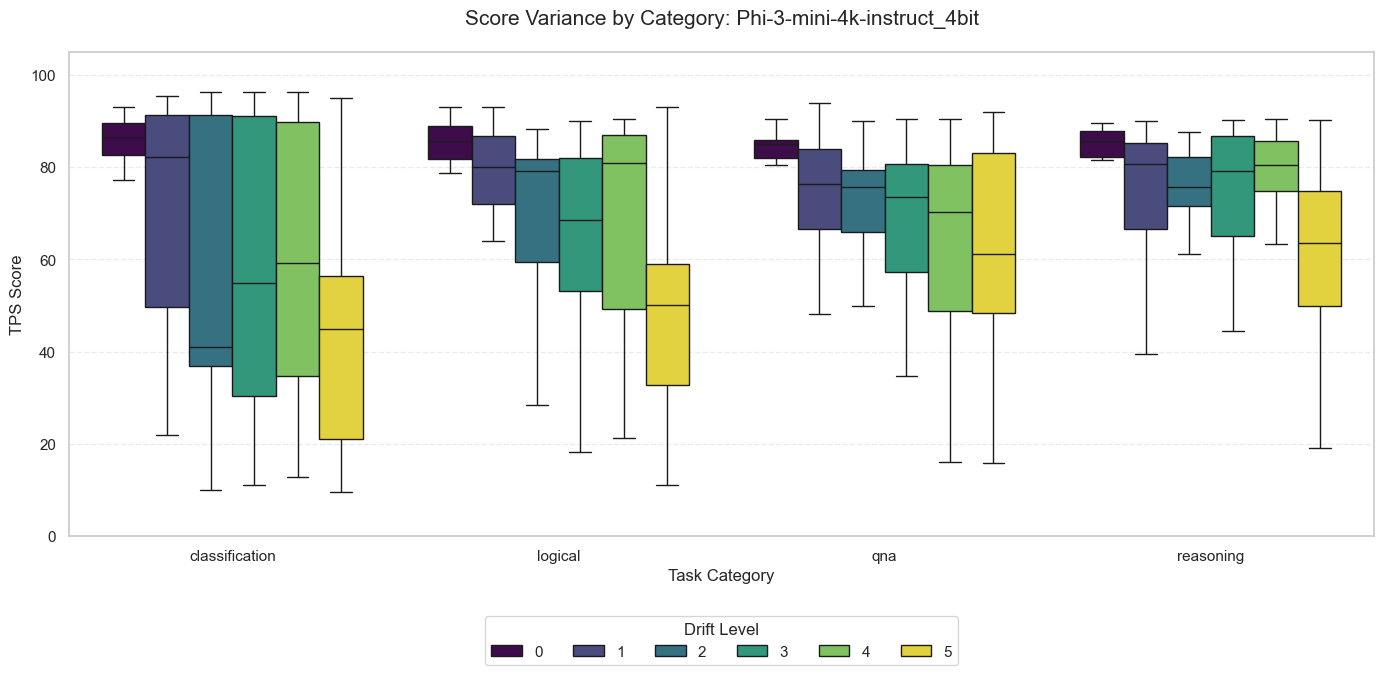

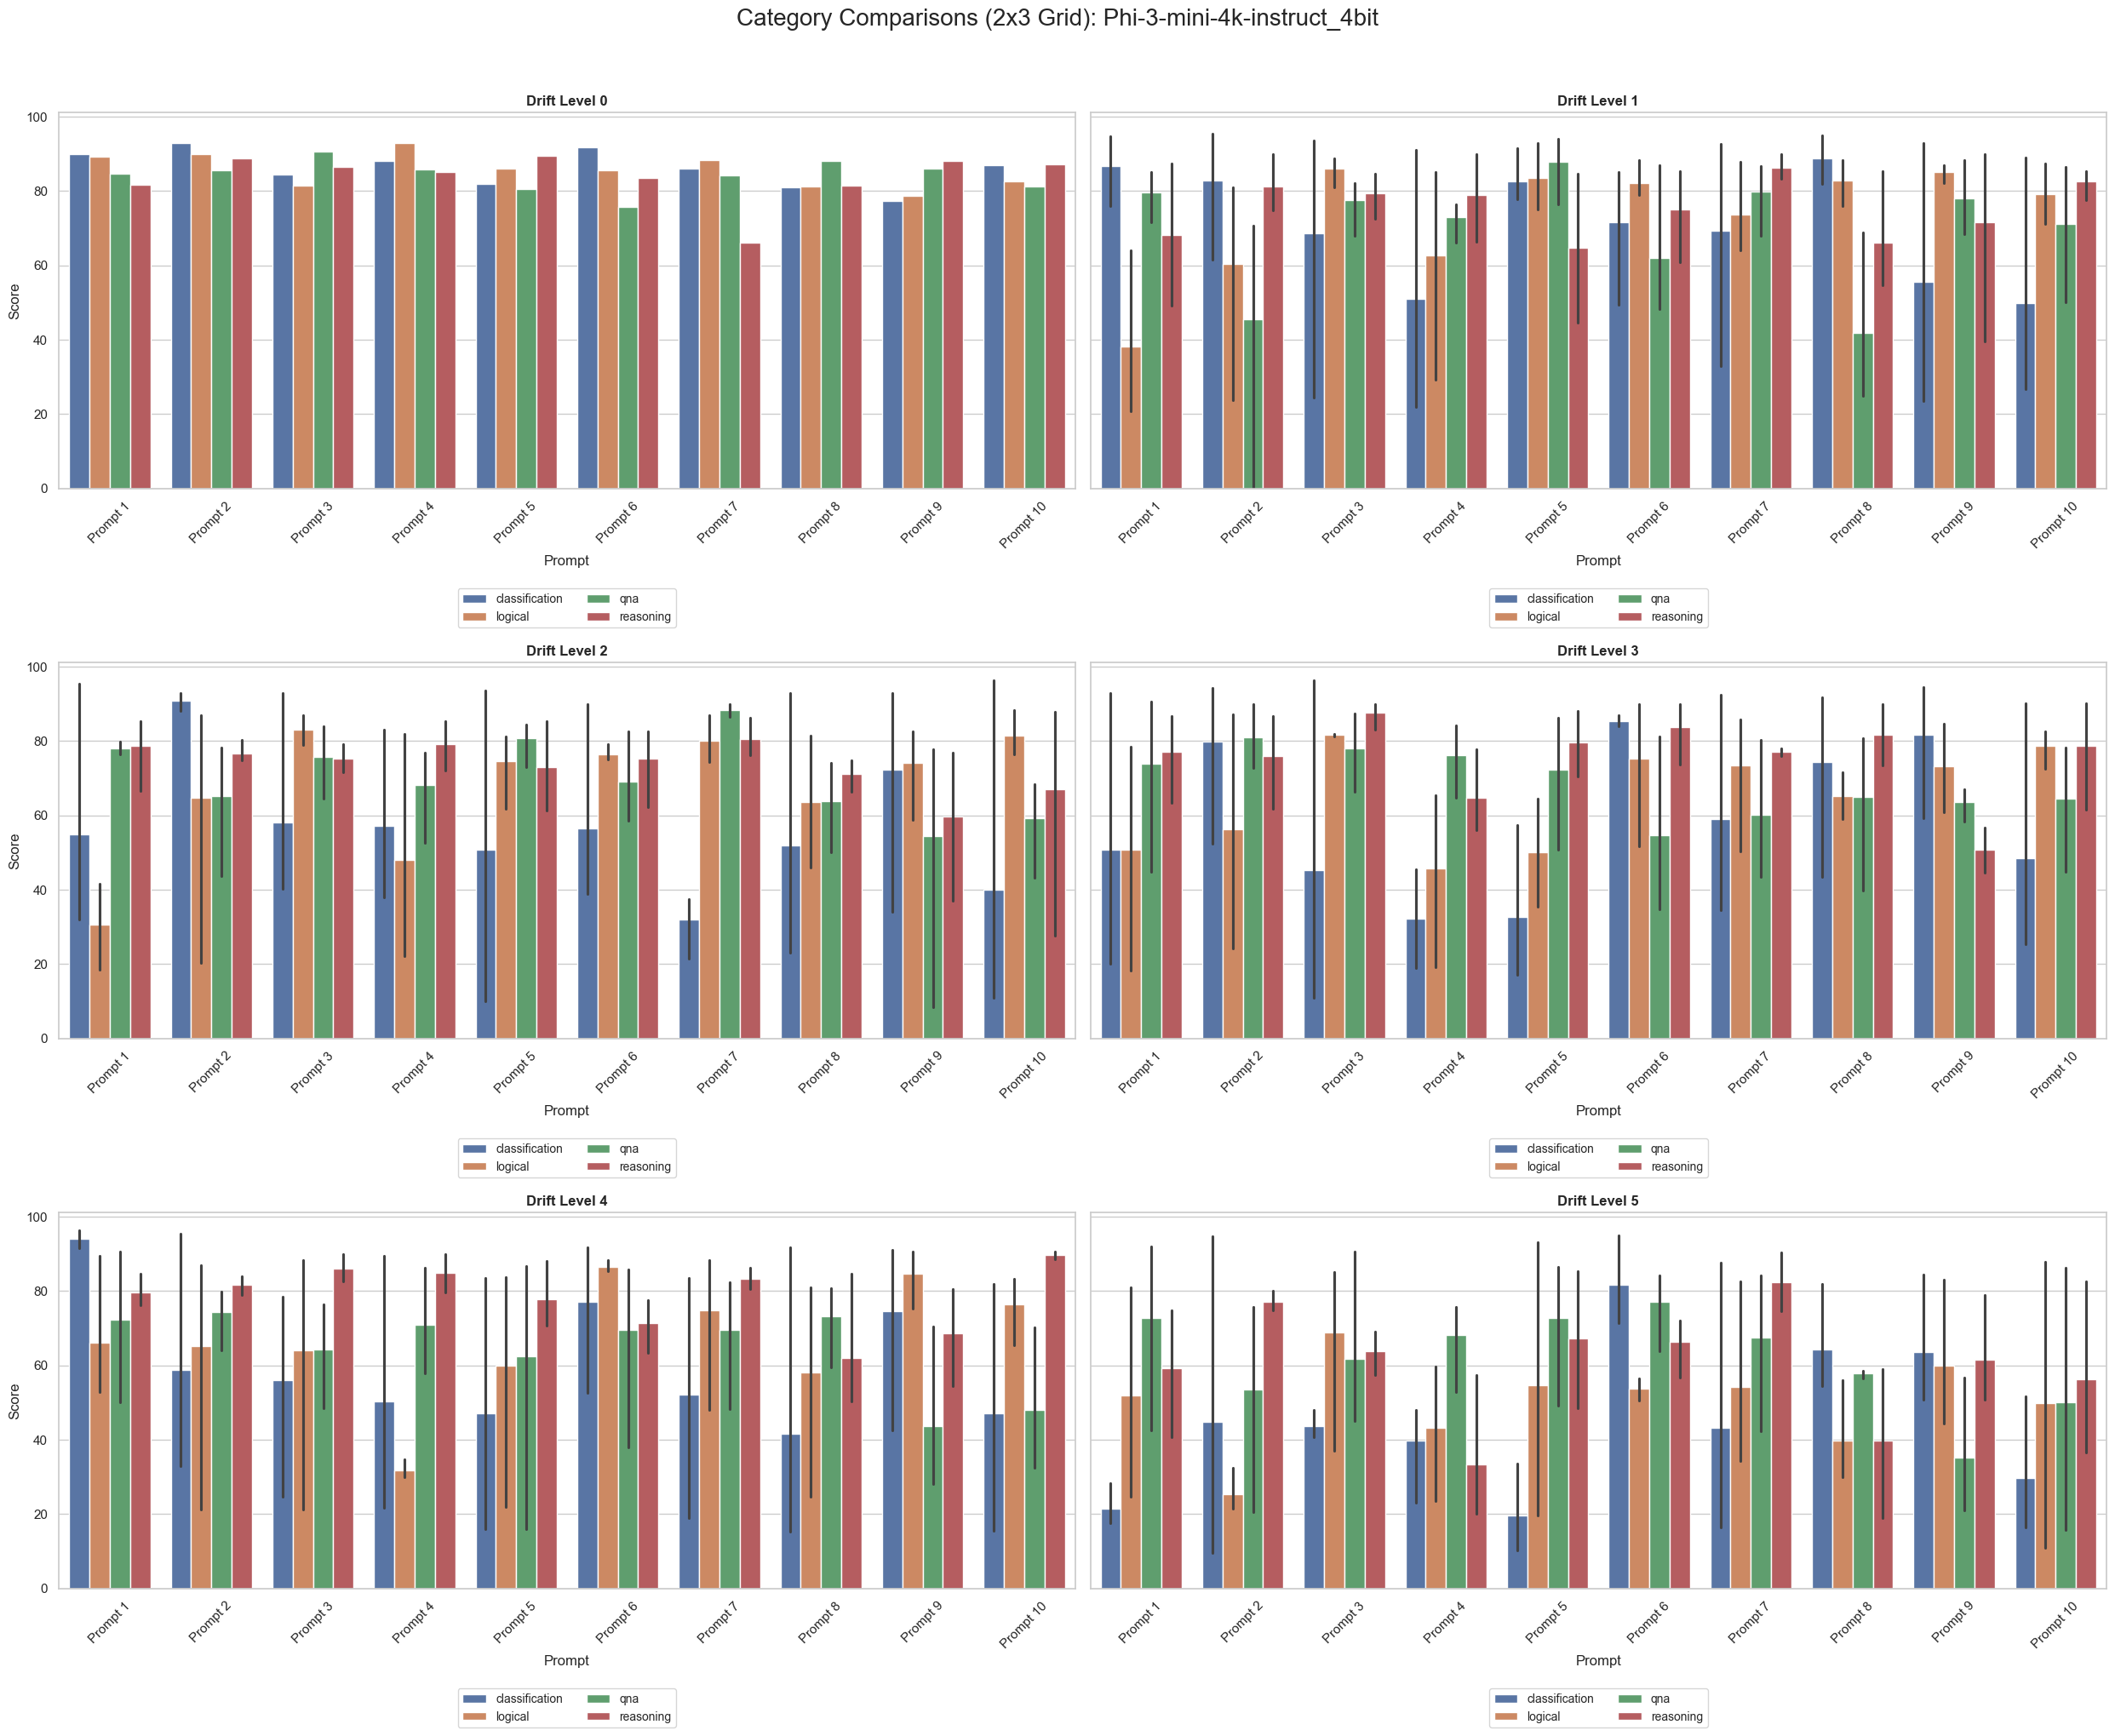

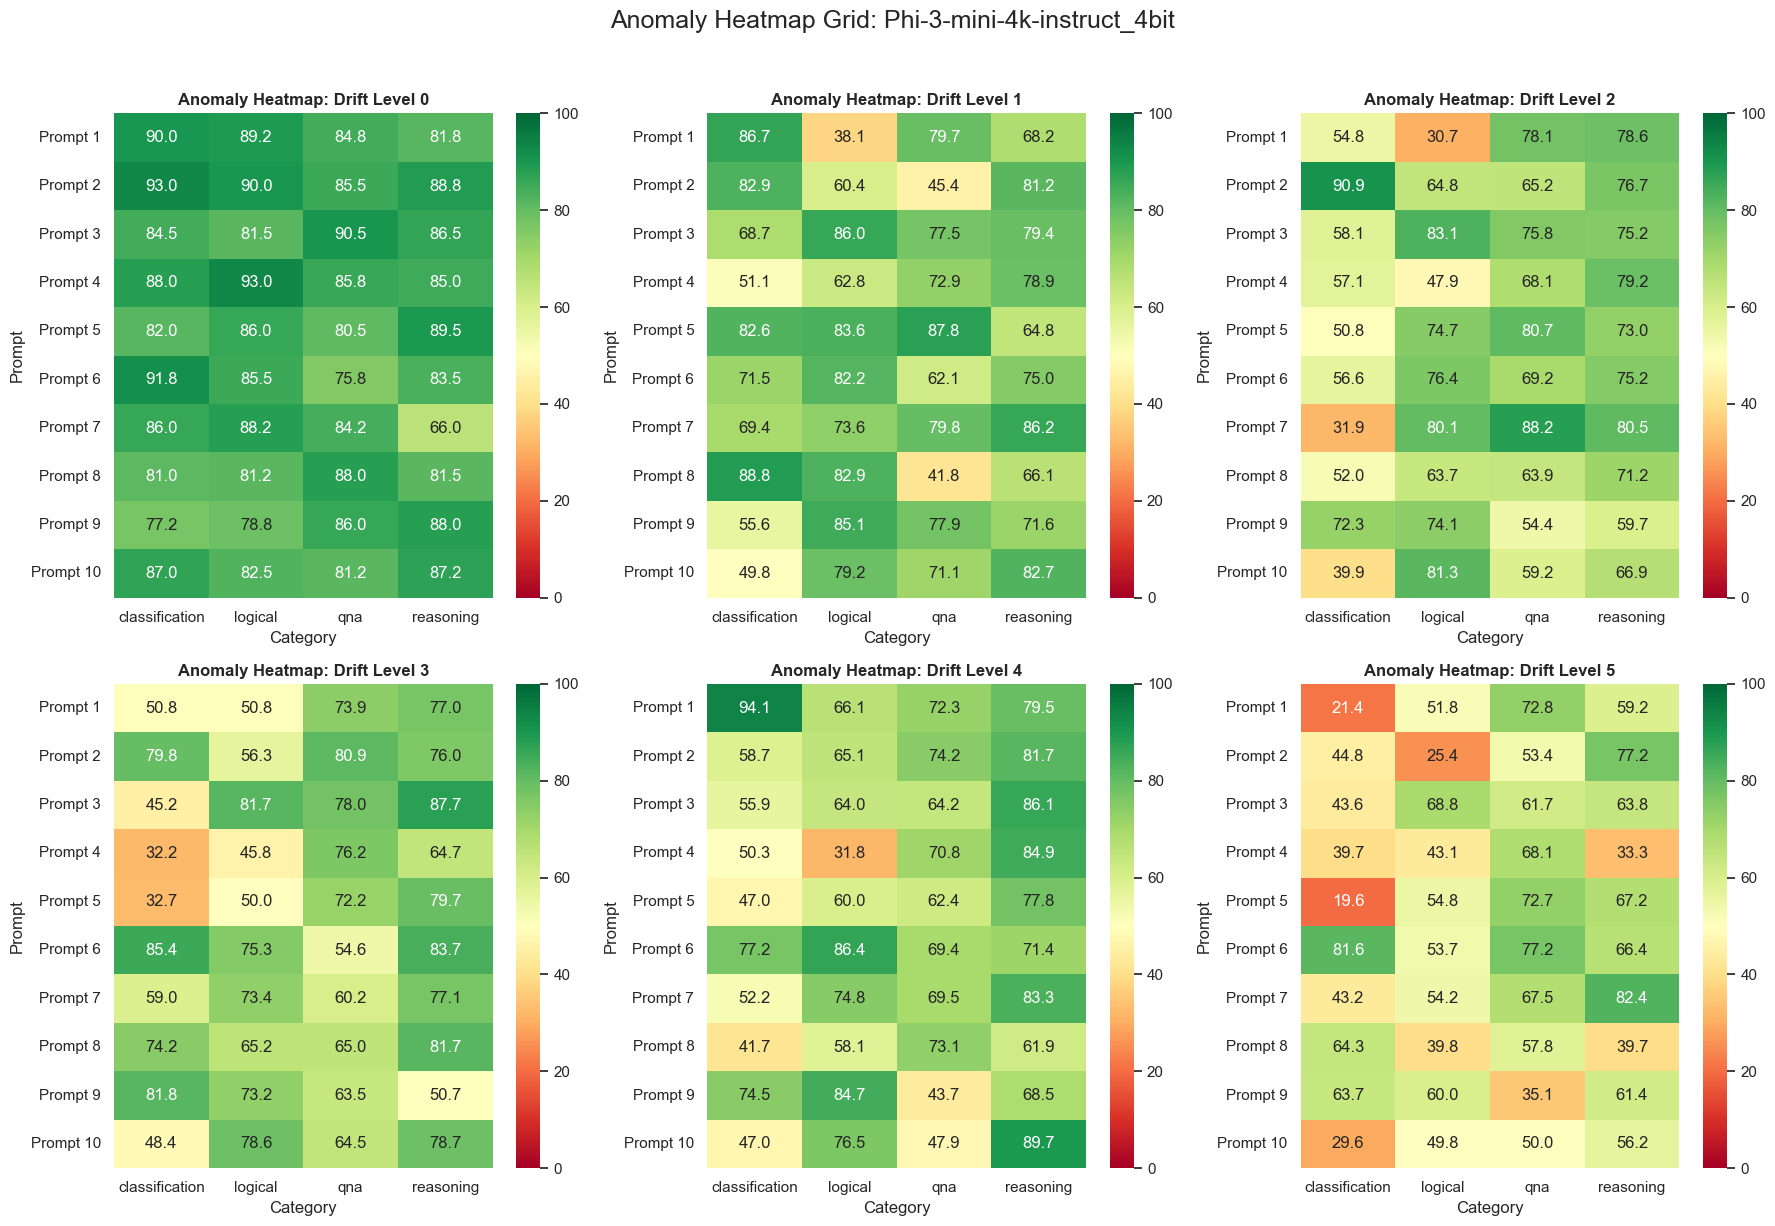


REPORT FOR: Phi-3-mini-4k-instruct_8bit


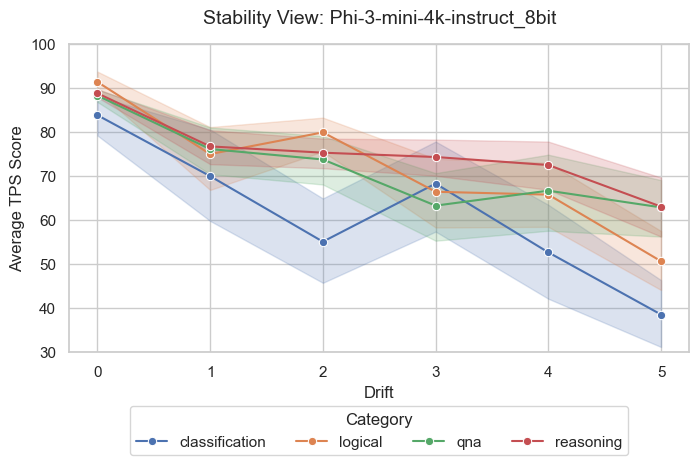

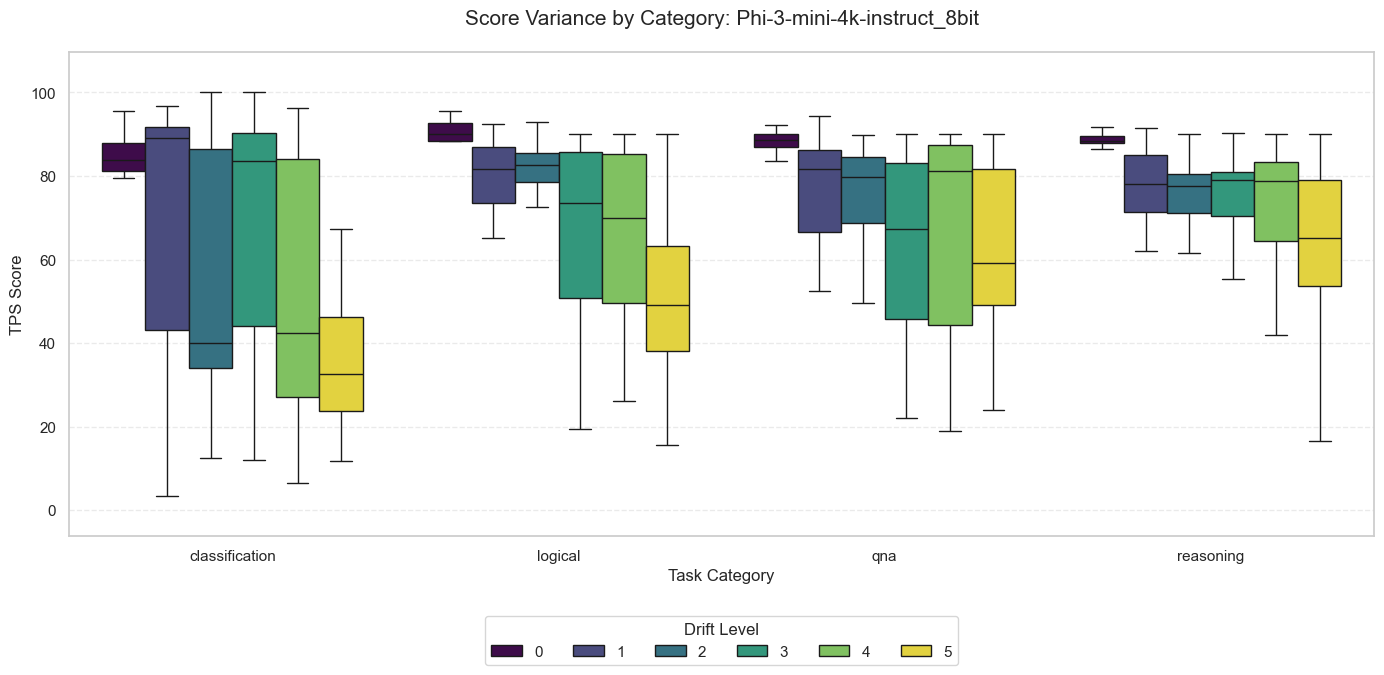

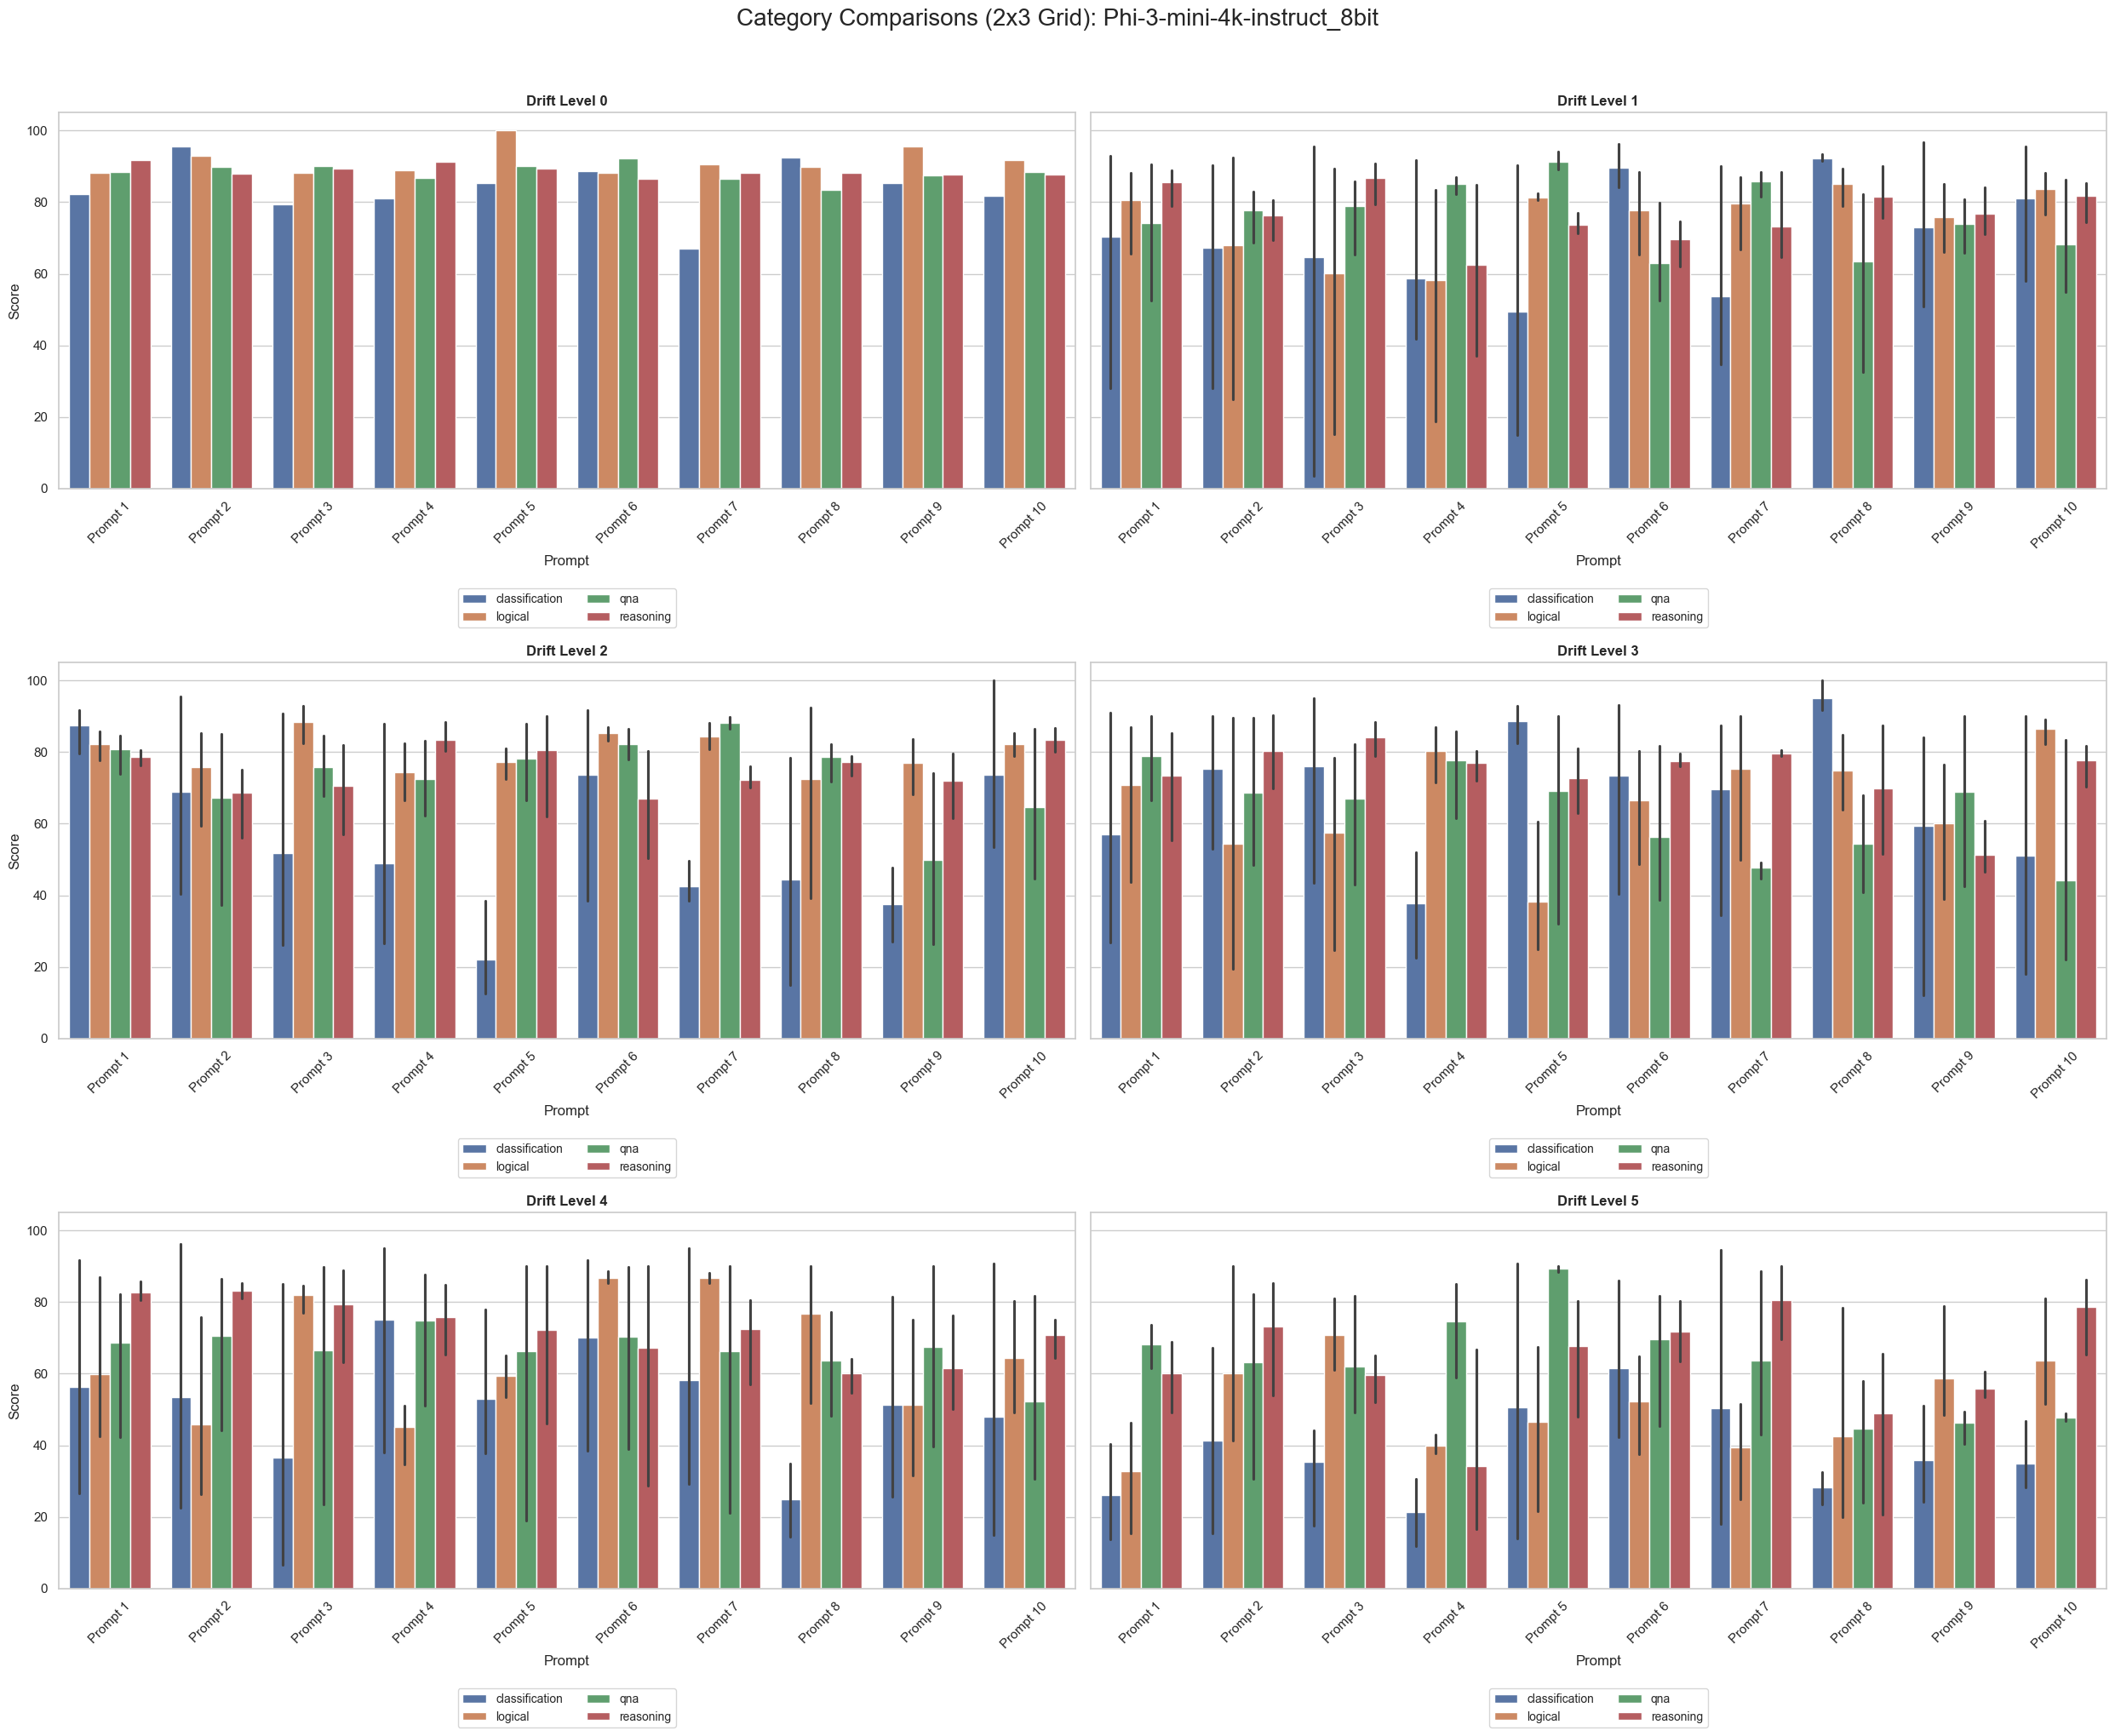

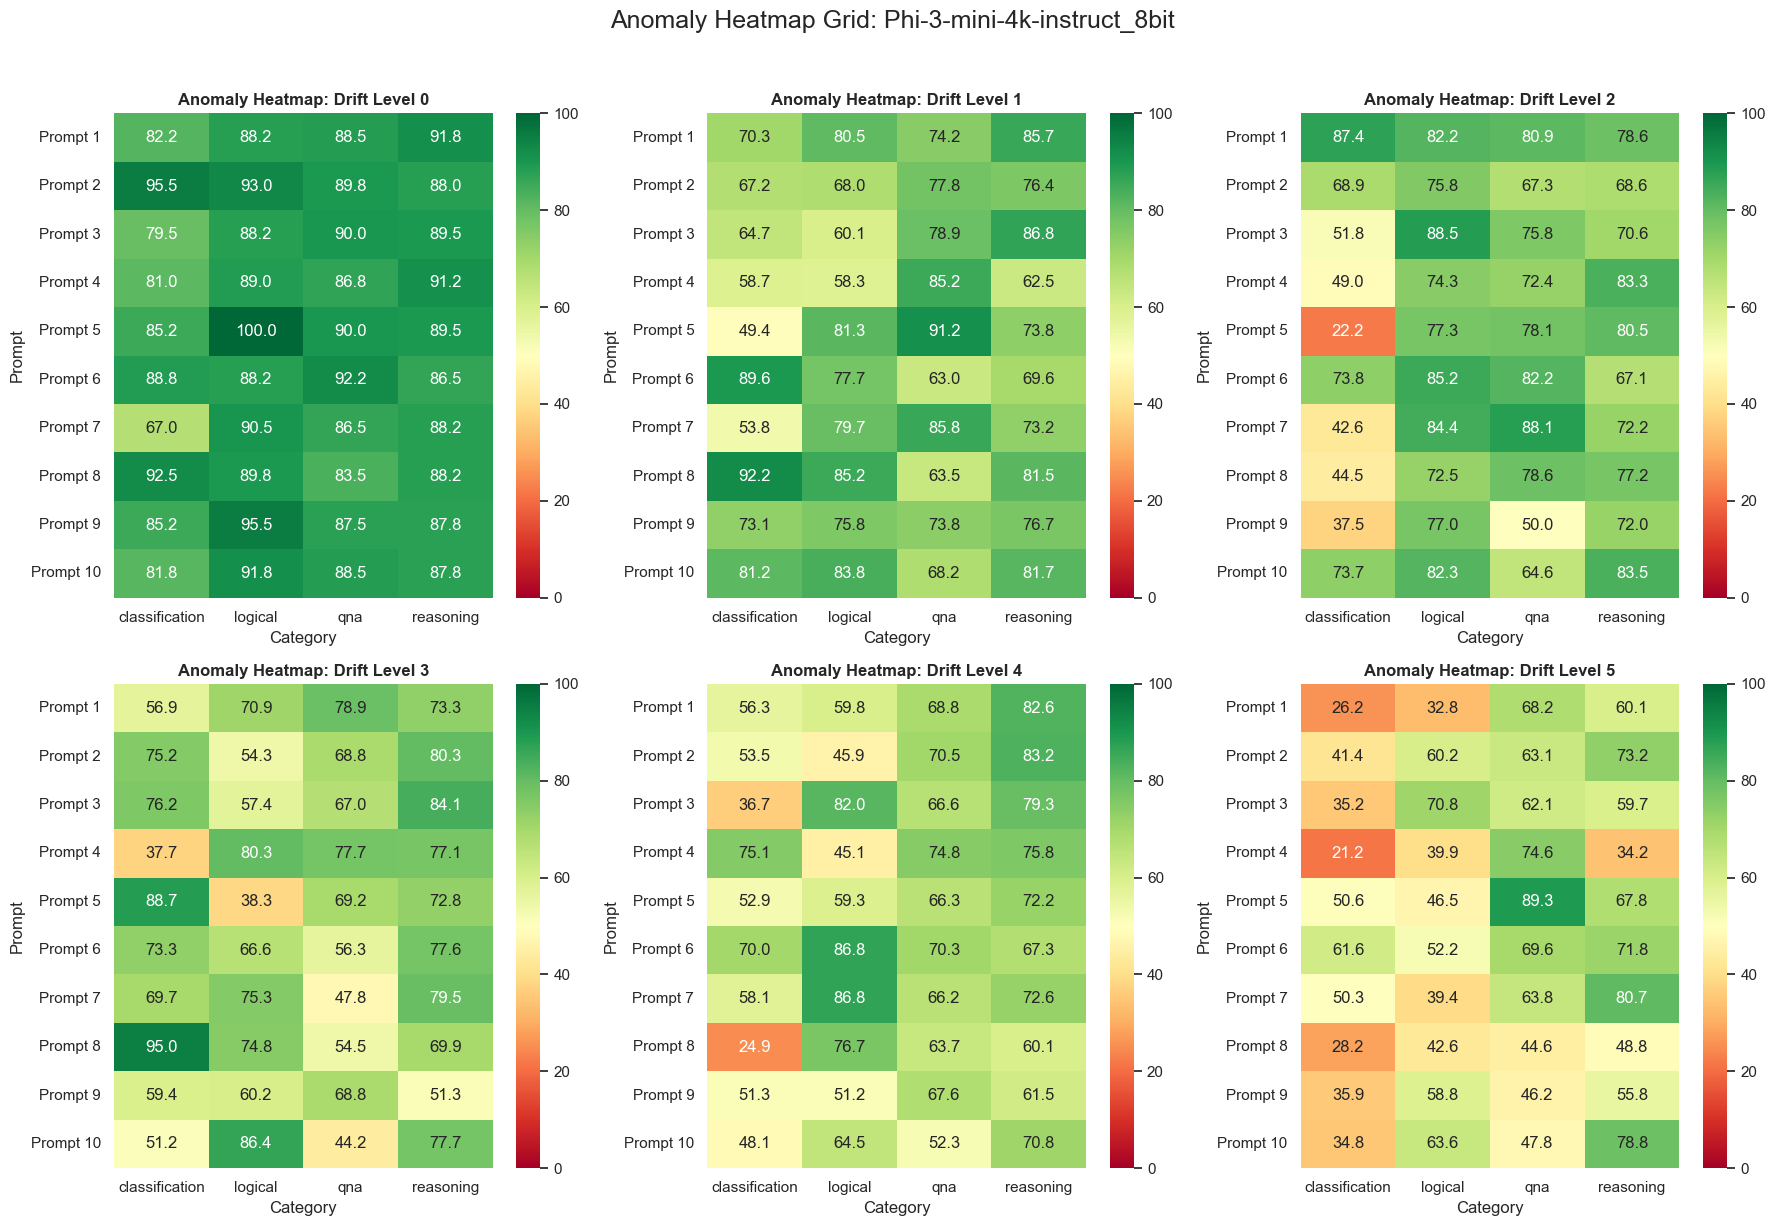


REPORT FOR: Phi-3-mini-4k-instruct_fp16


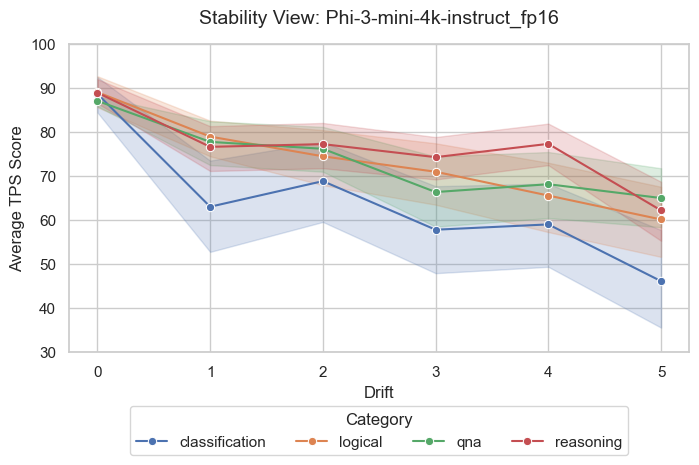

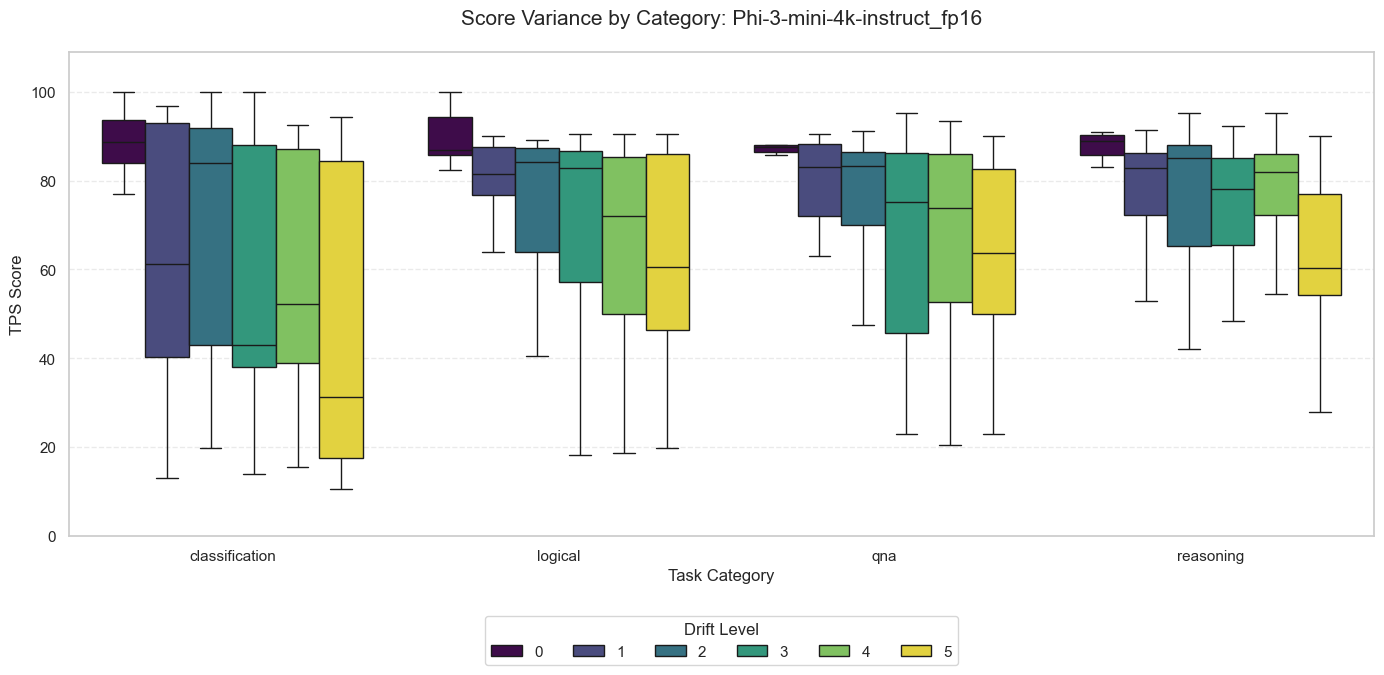

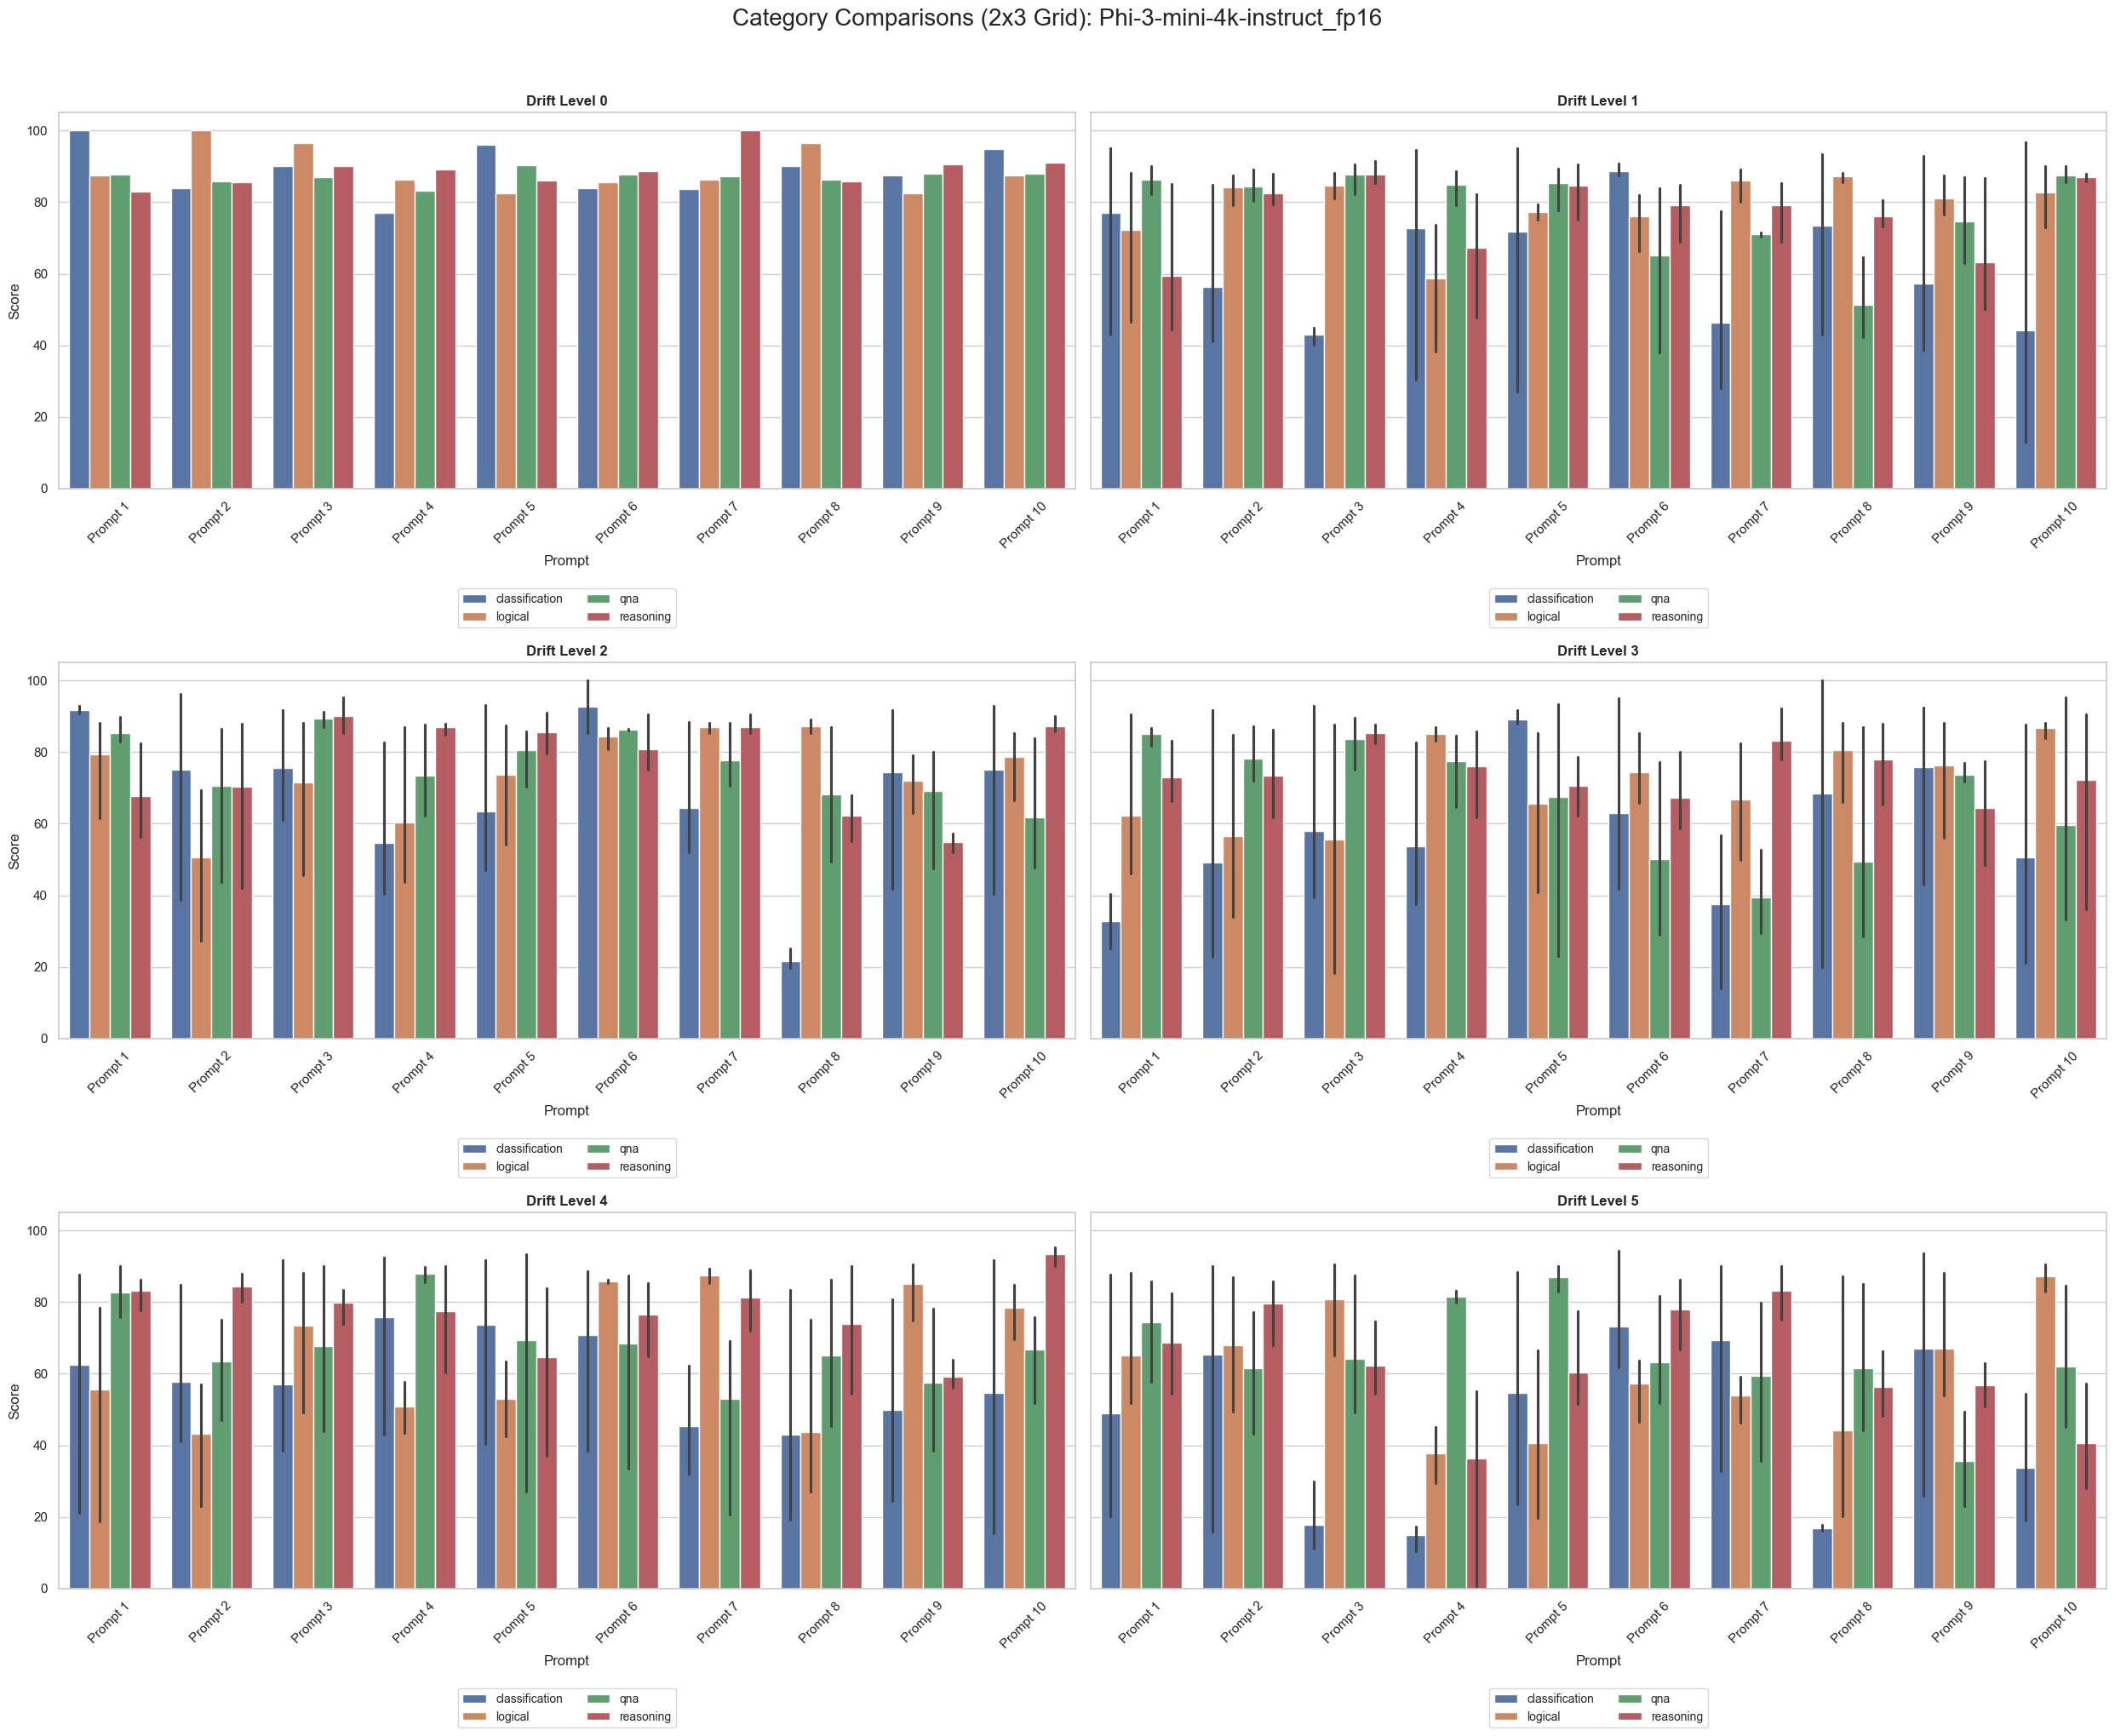

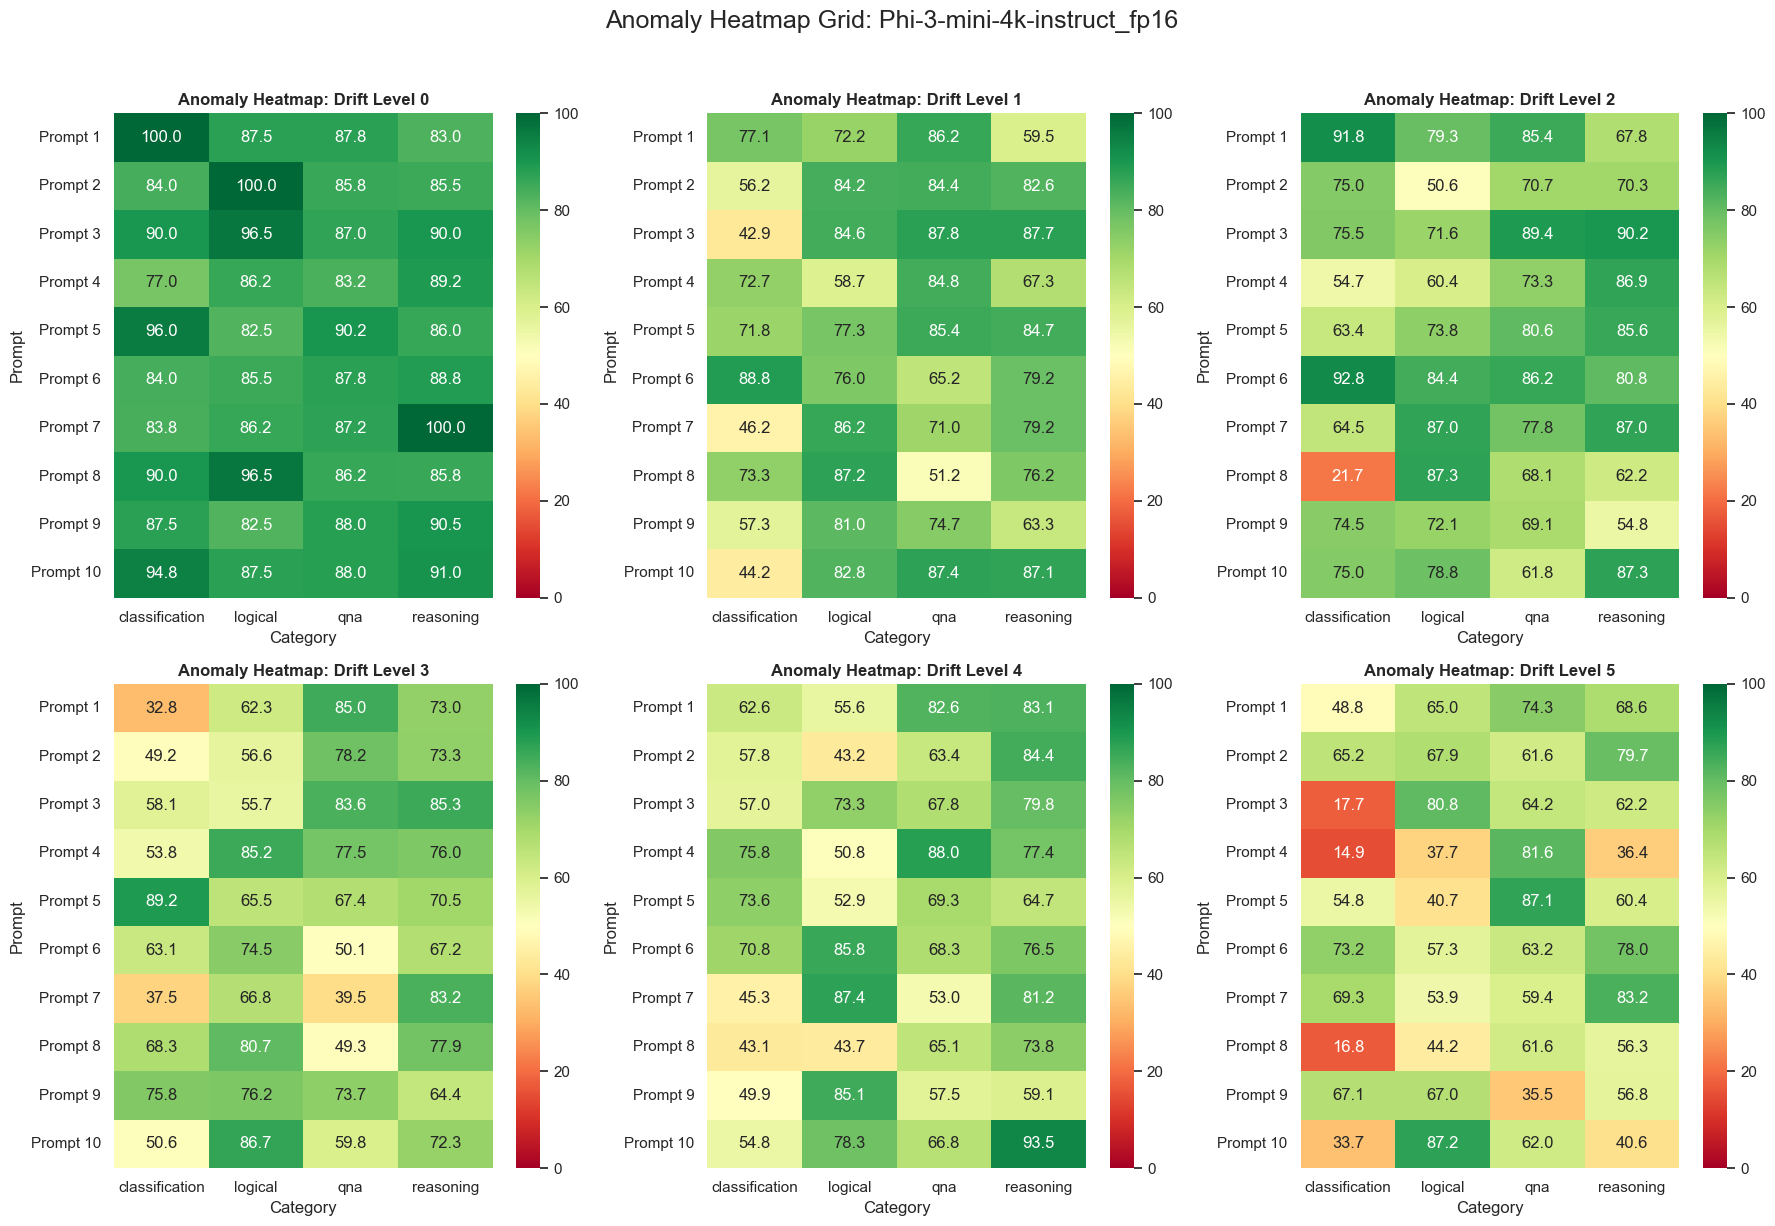


REPORT FOR: Mistral-7B-Instruct-v0.2_4bit


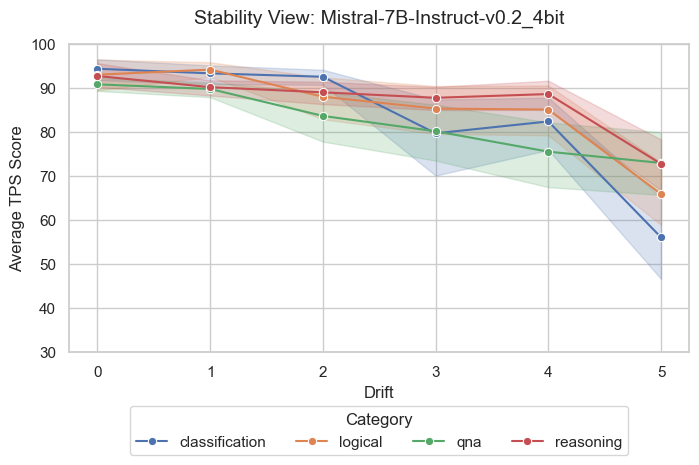

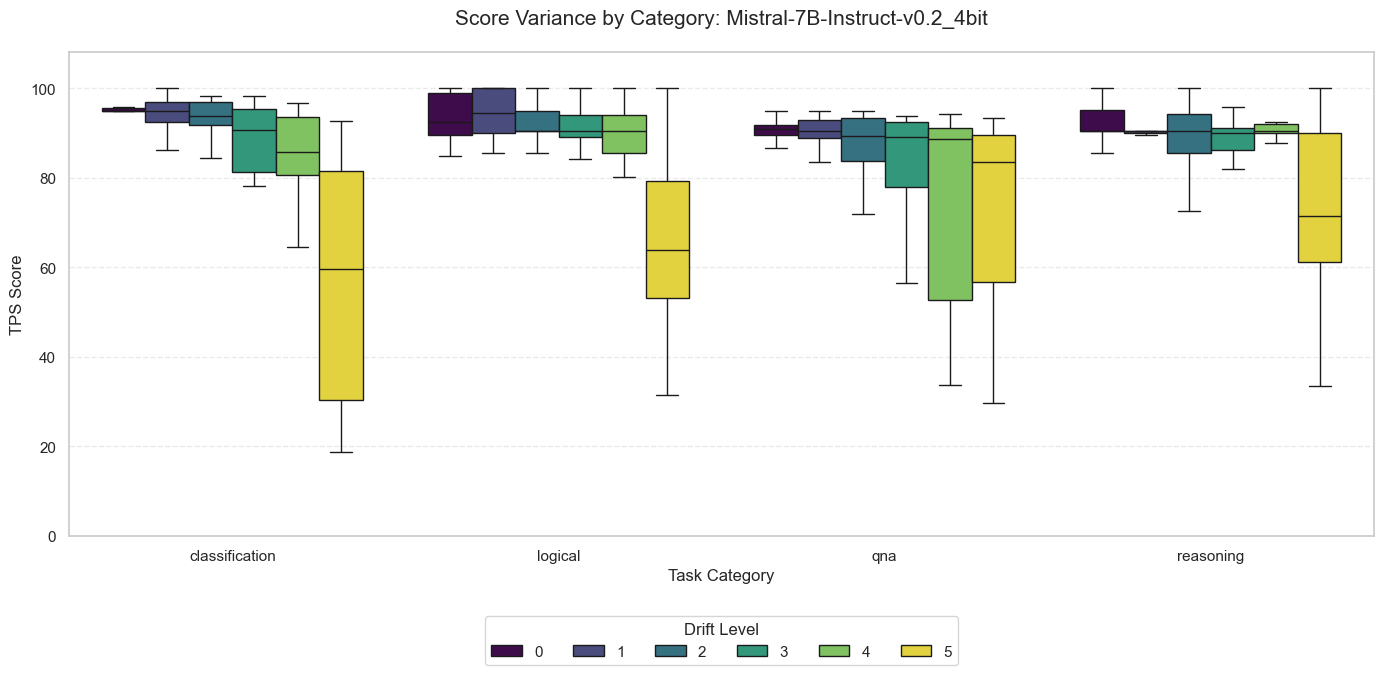

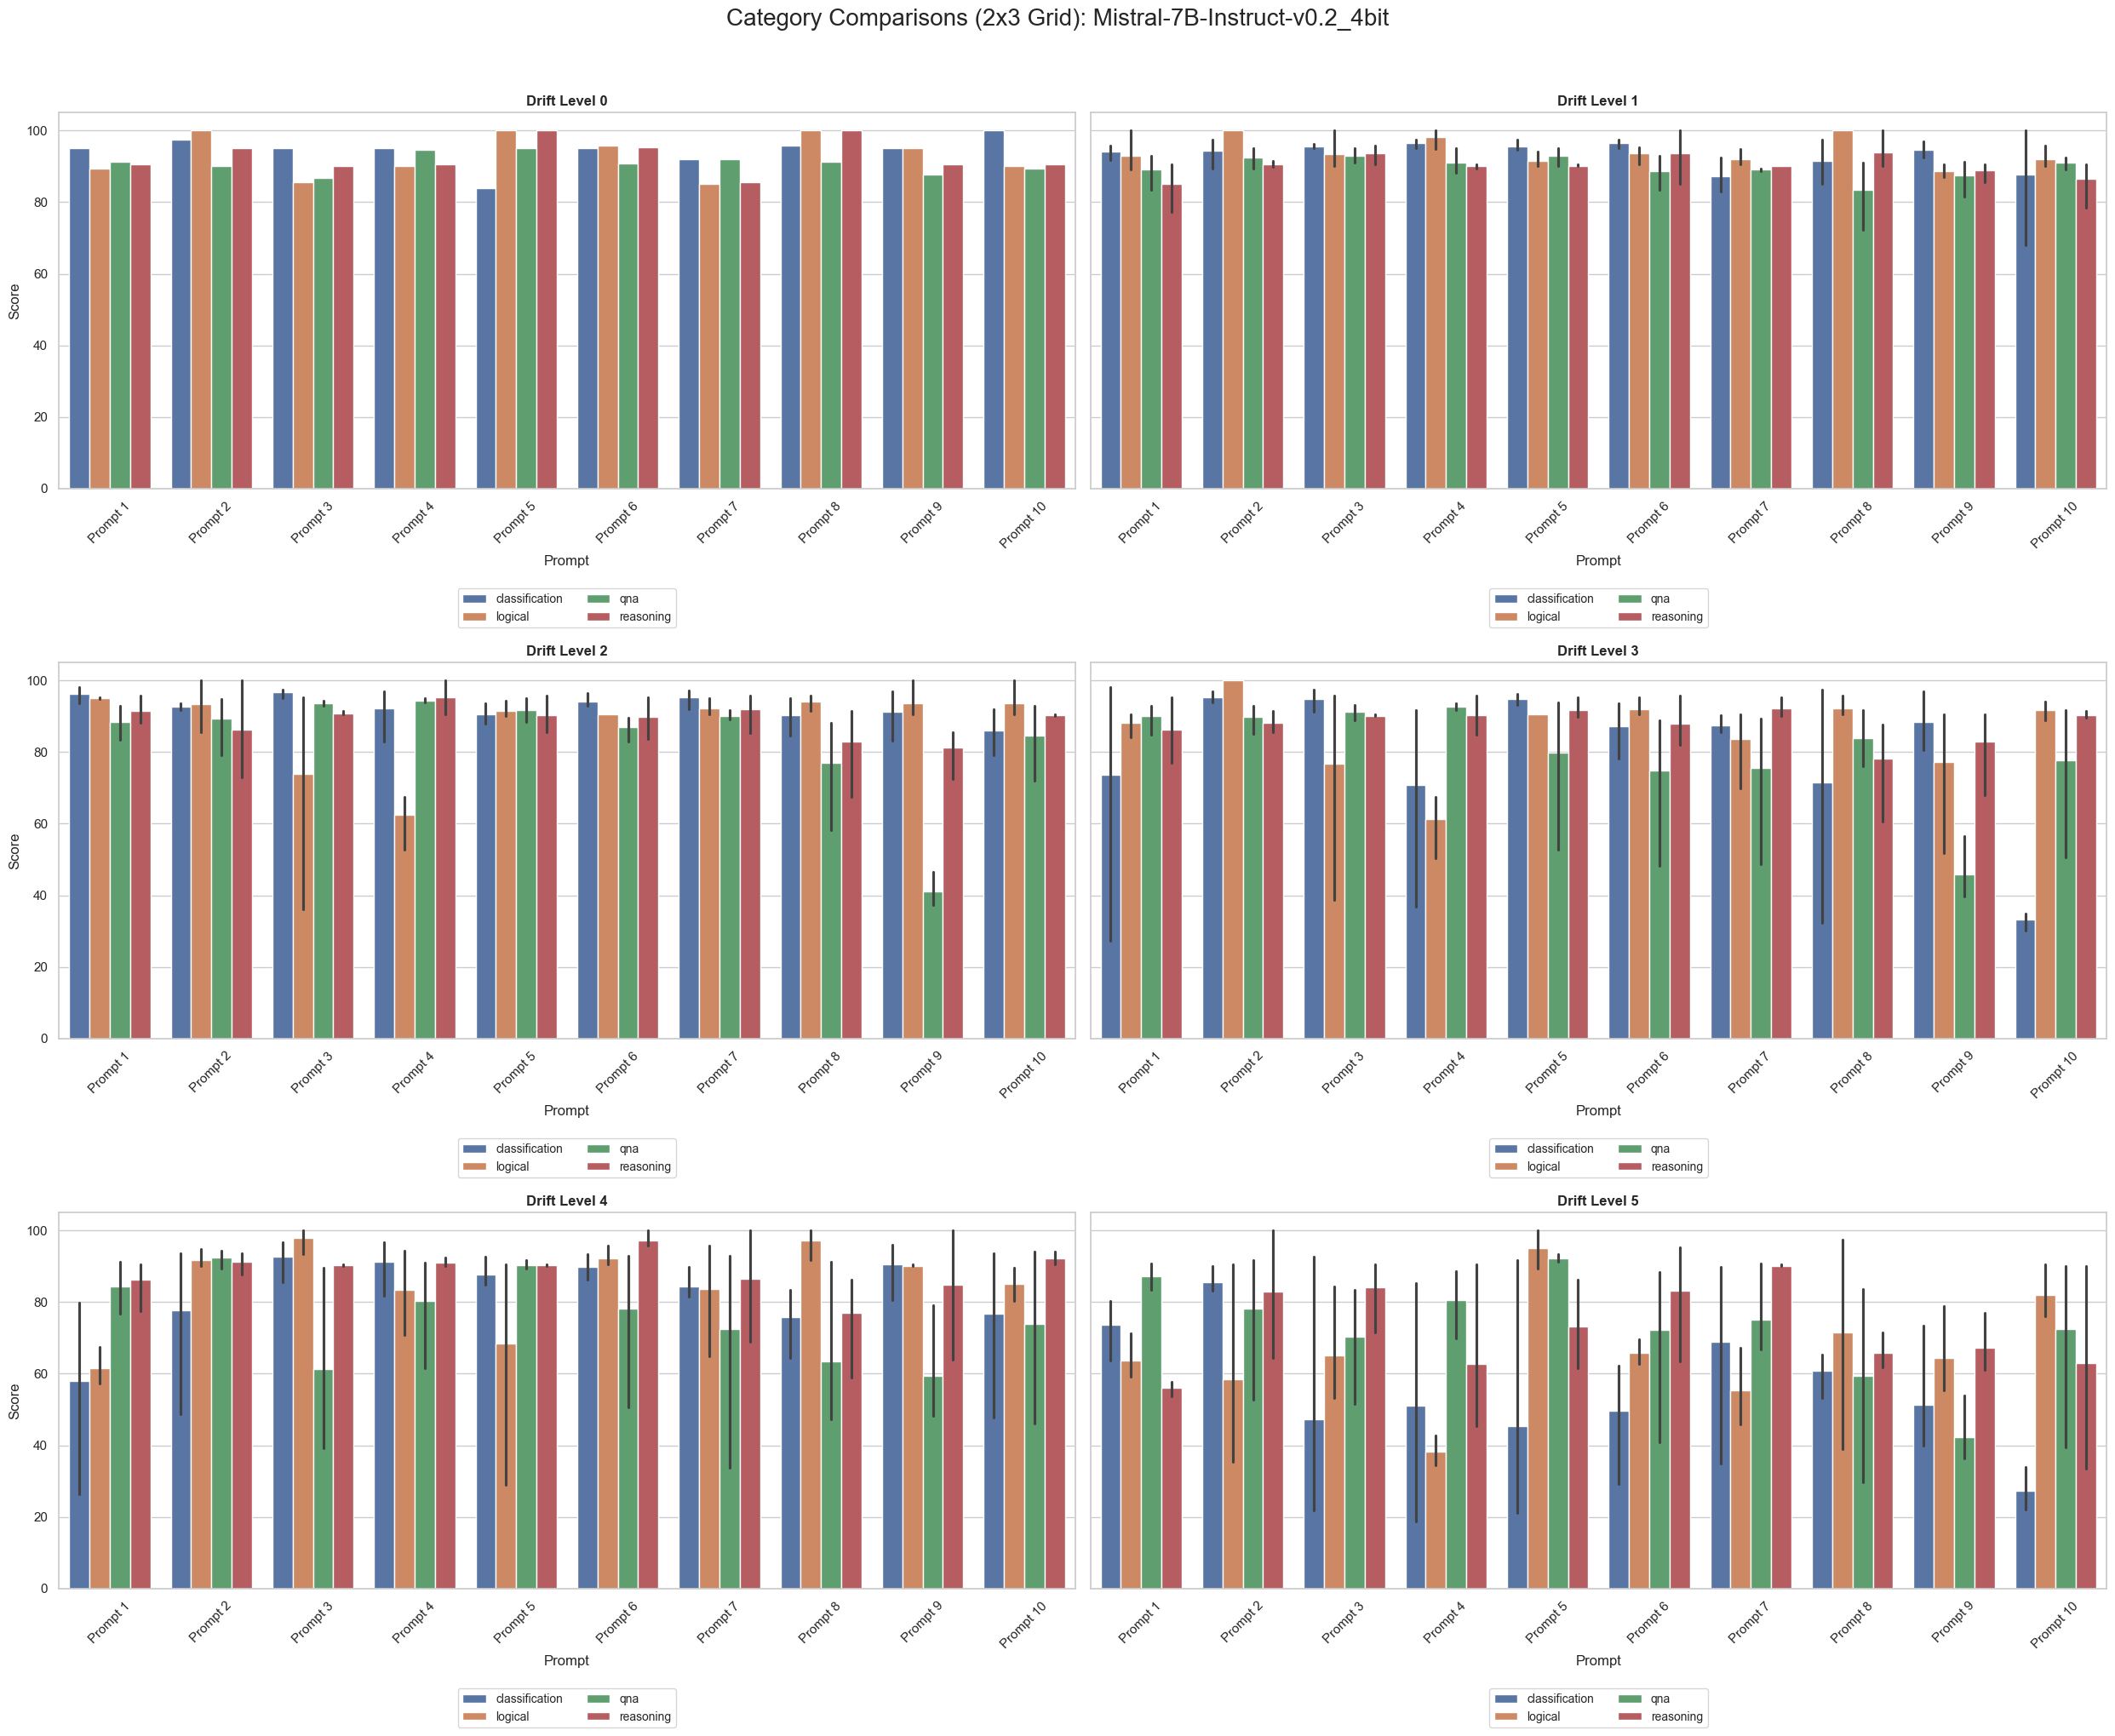

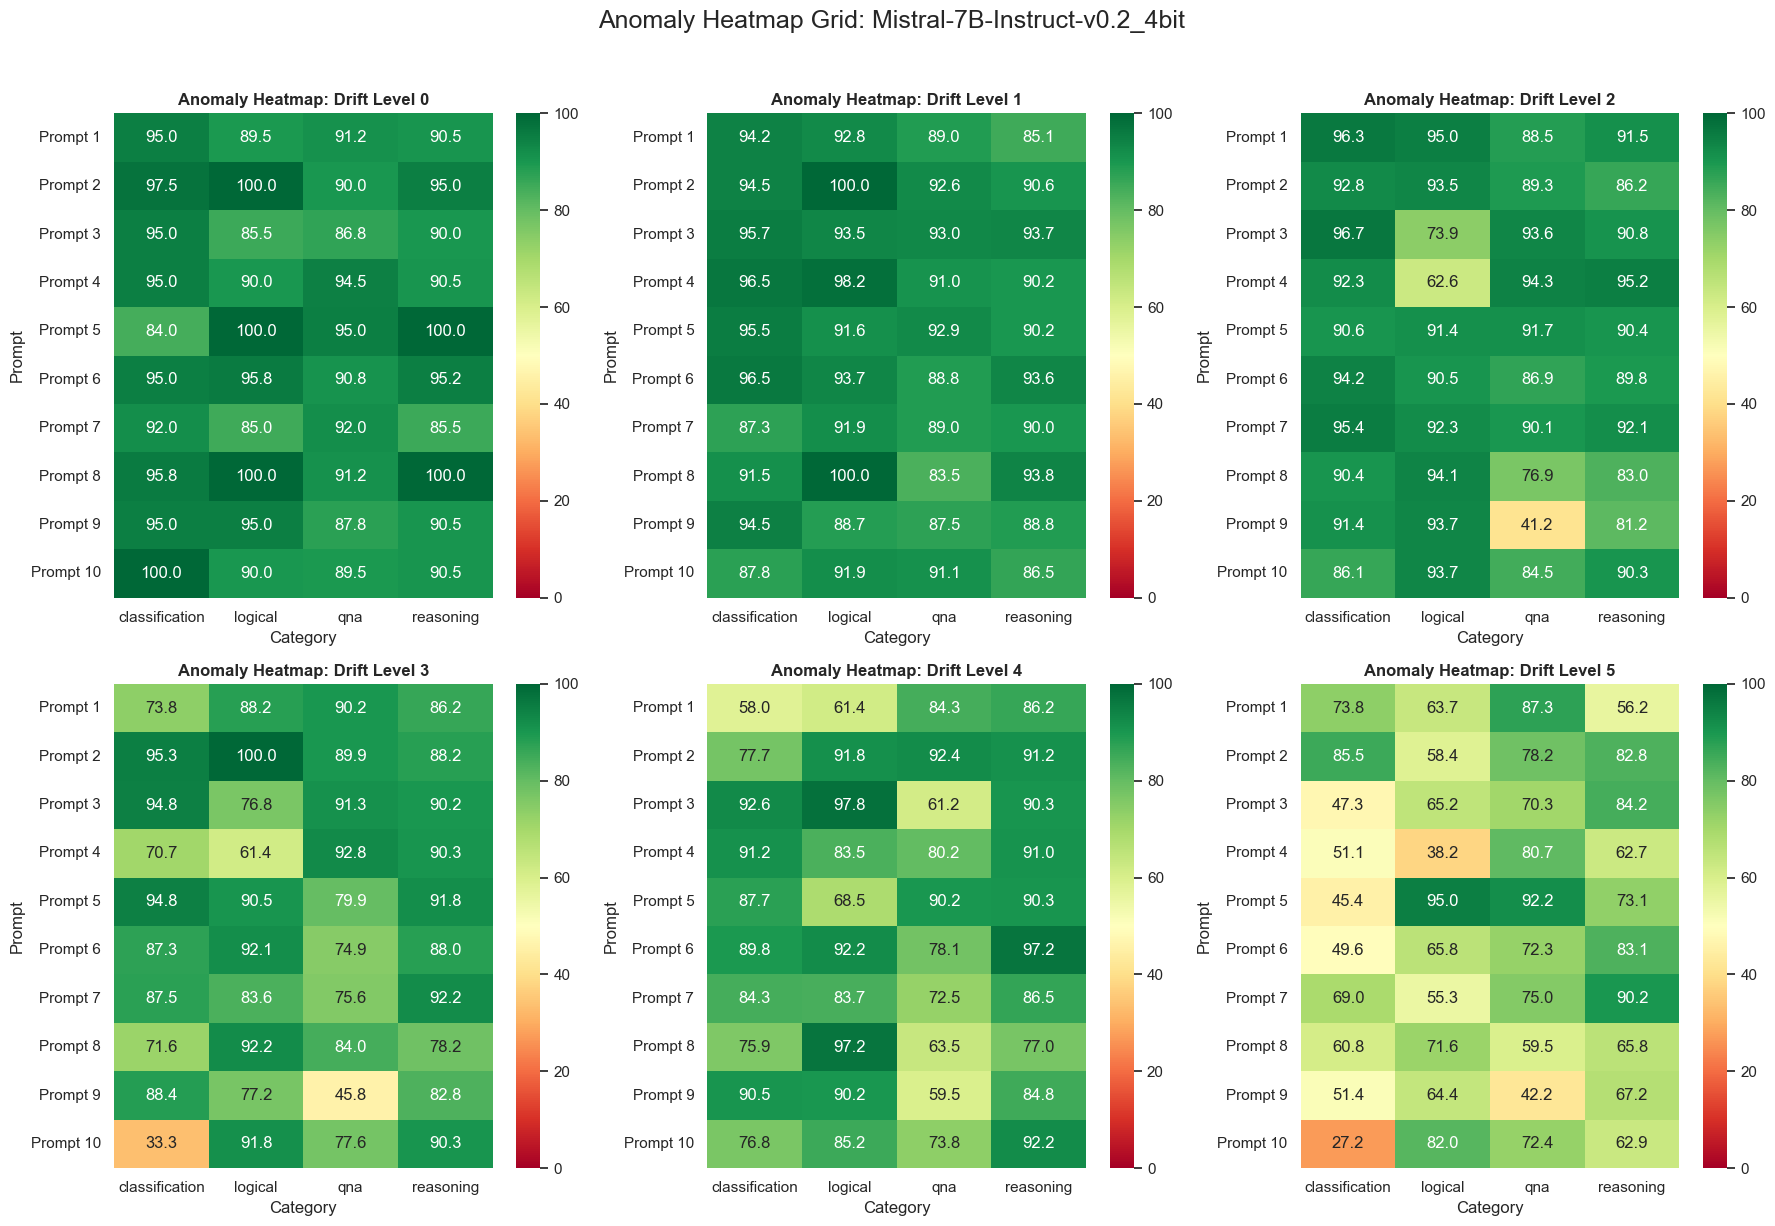


REPORT FOR: Mistral-7B-Instruct-v0.2_8bit


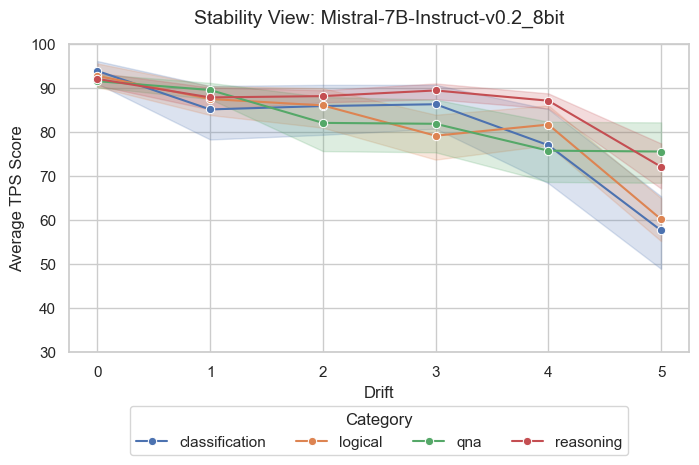

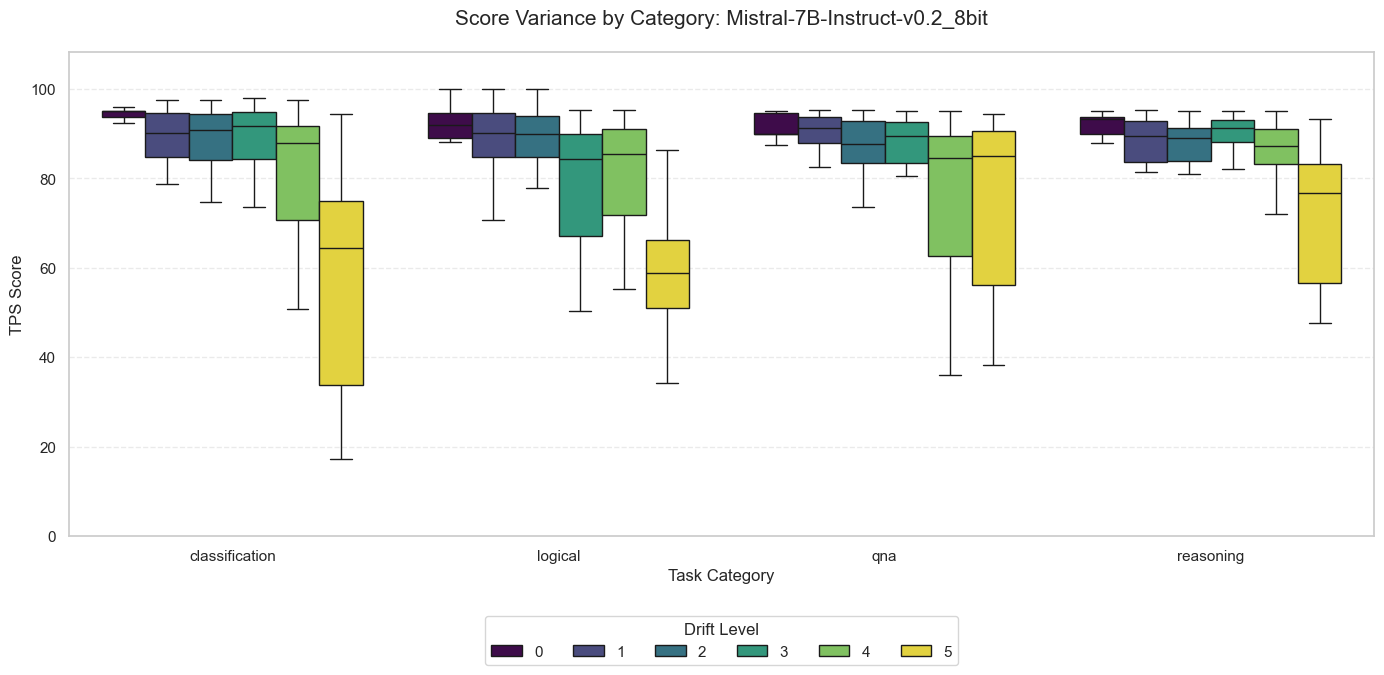

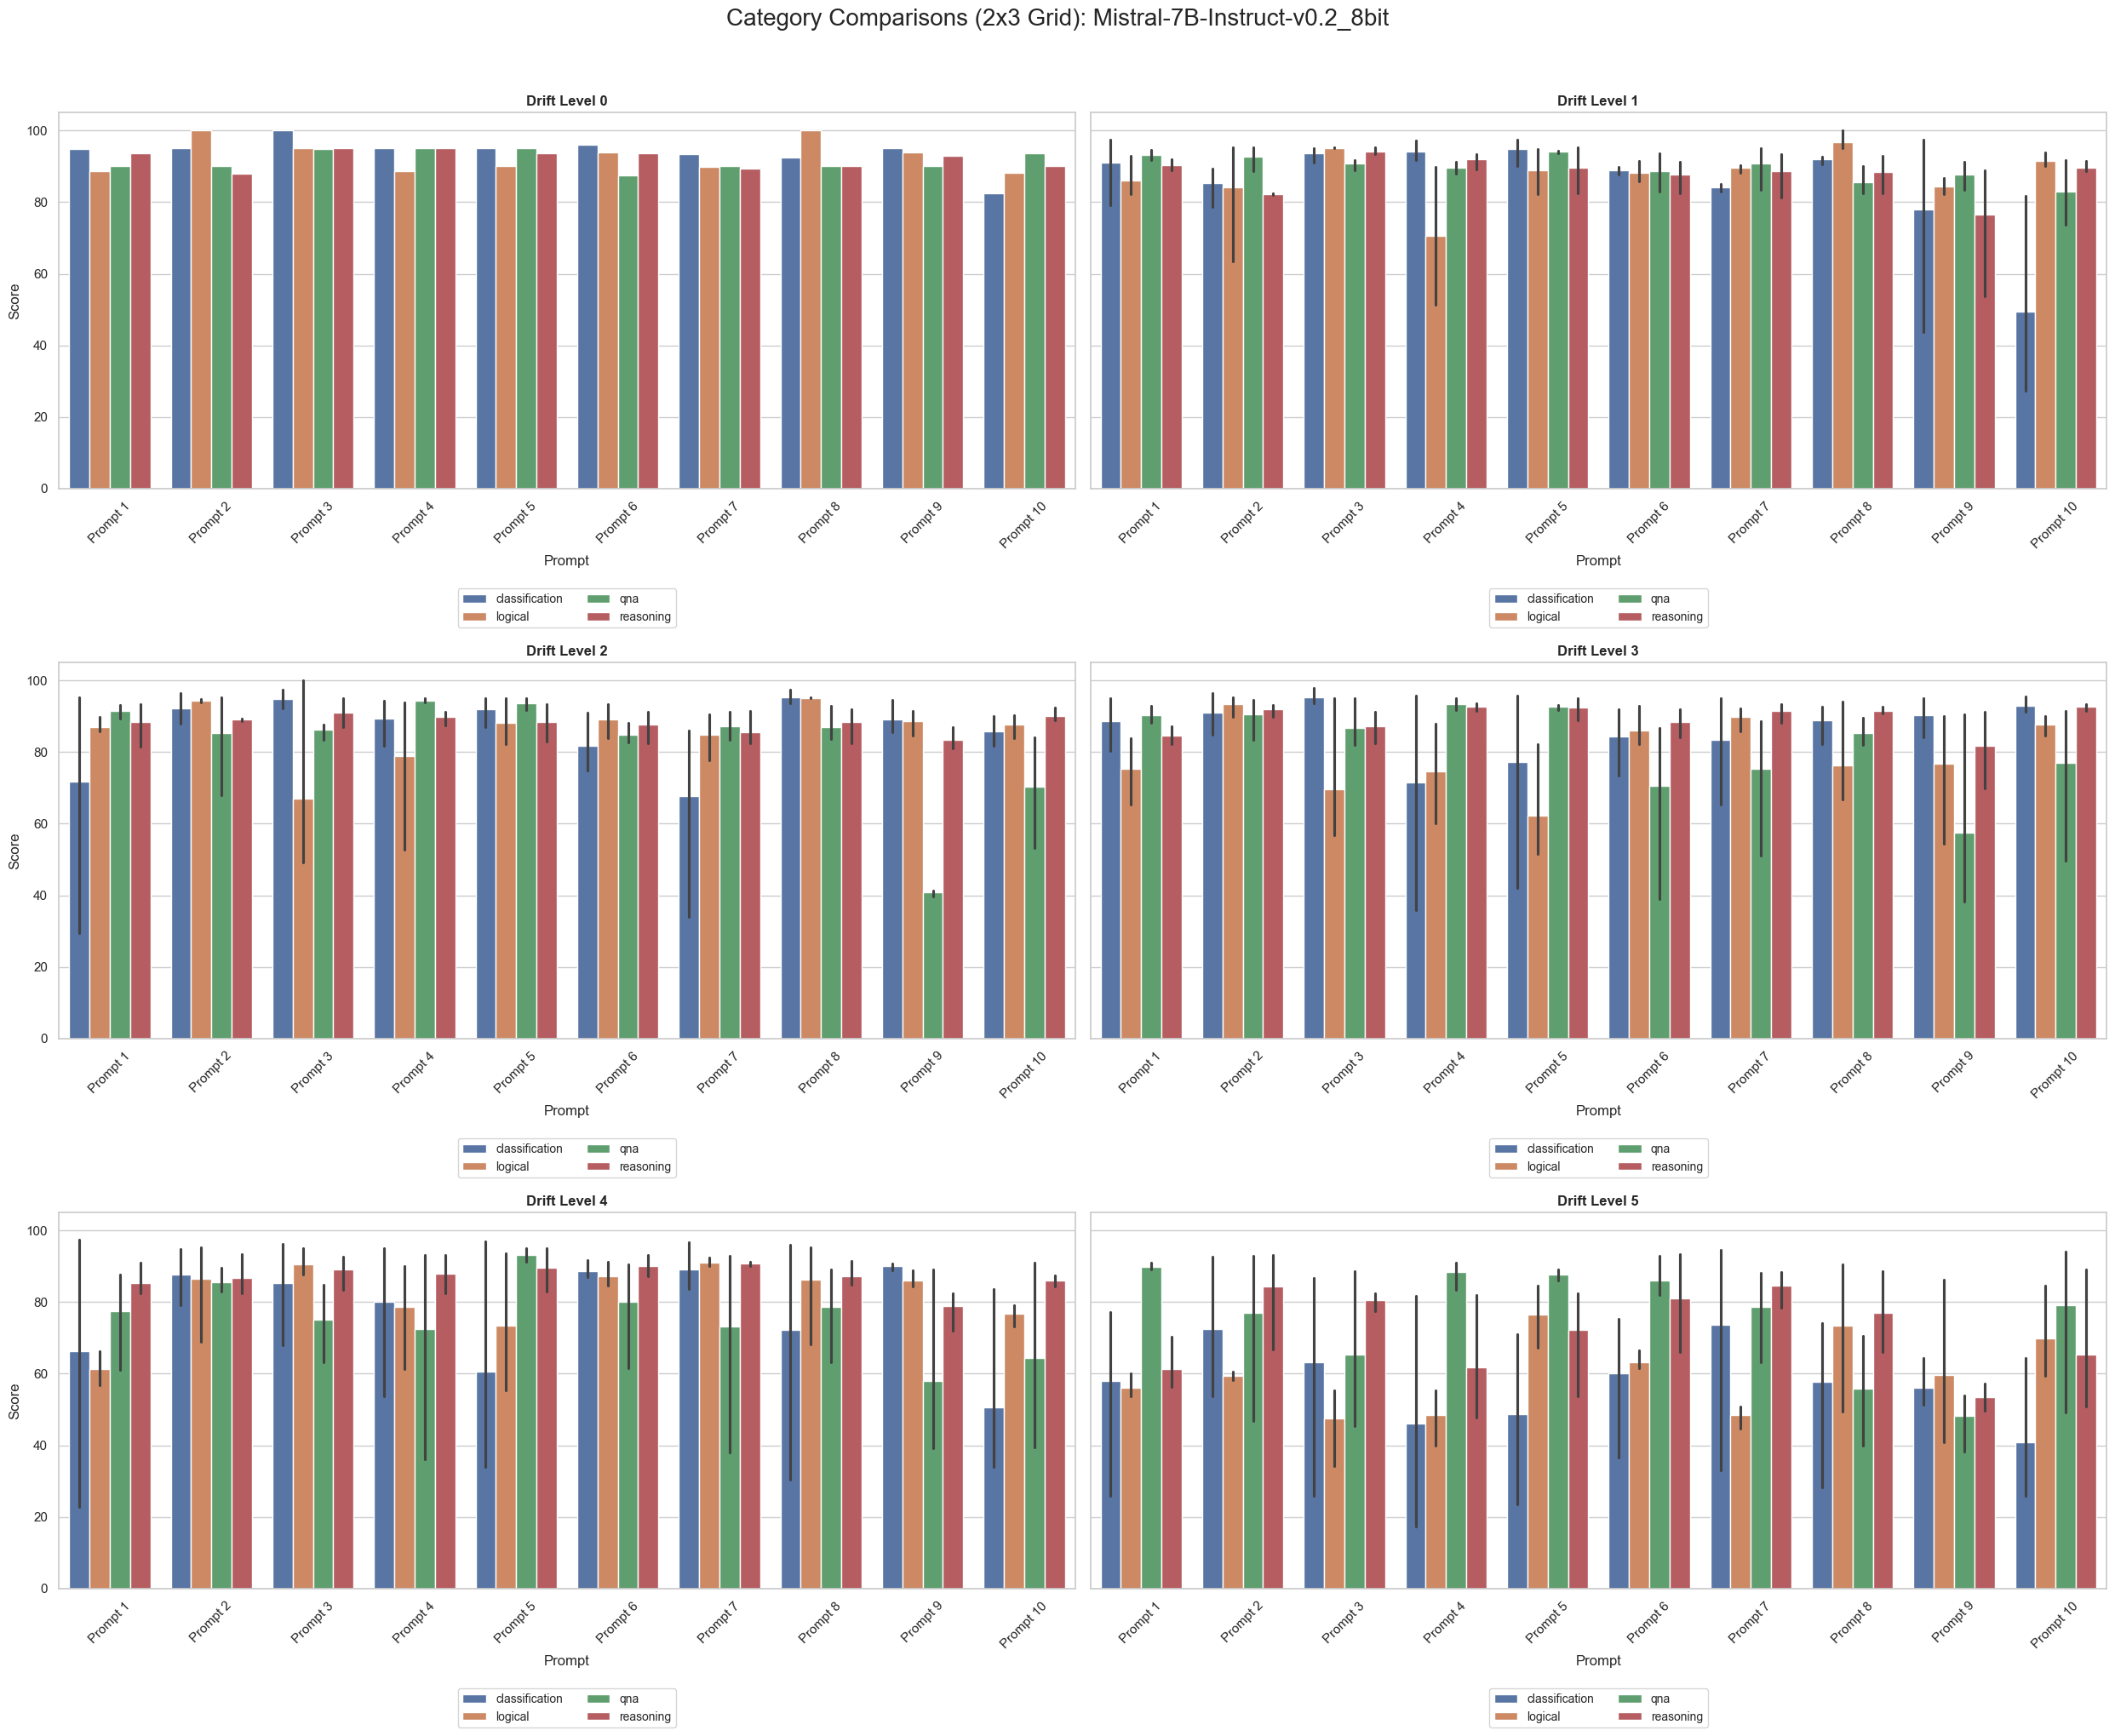

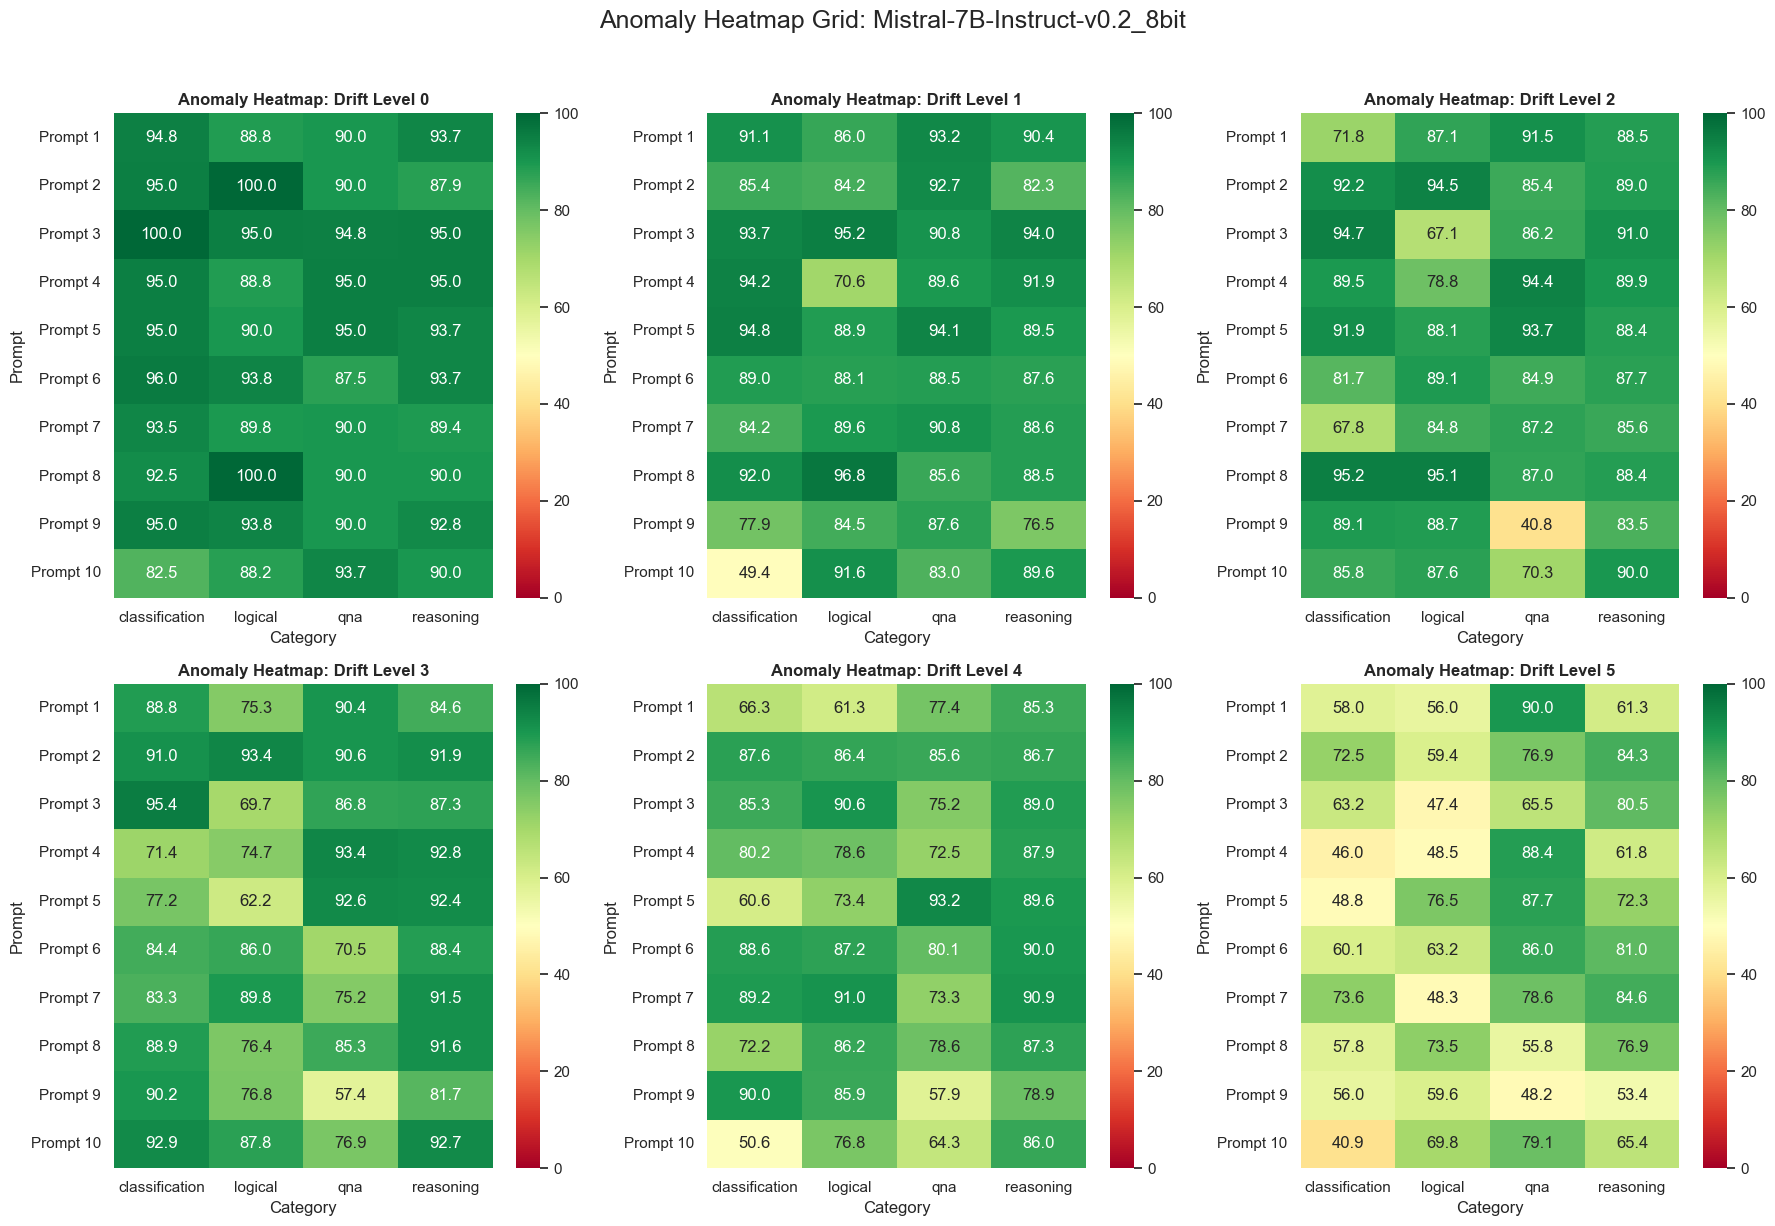


REPORT FOR: Mistral-7B-Instruct-v0.2_fp16


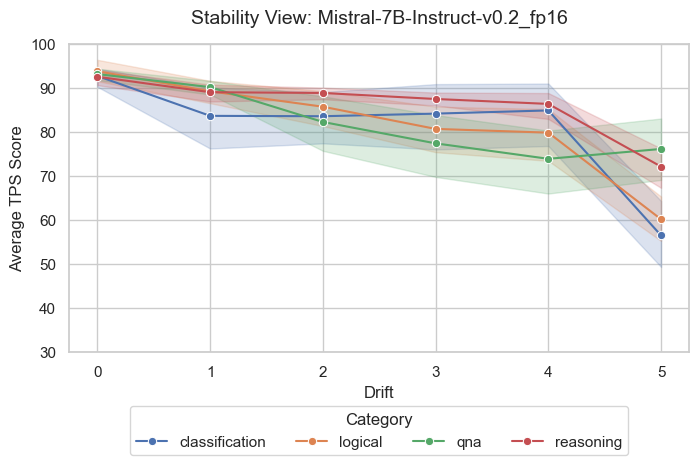

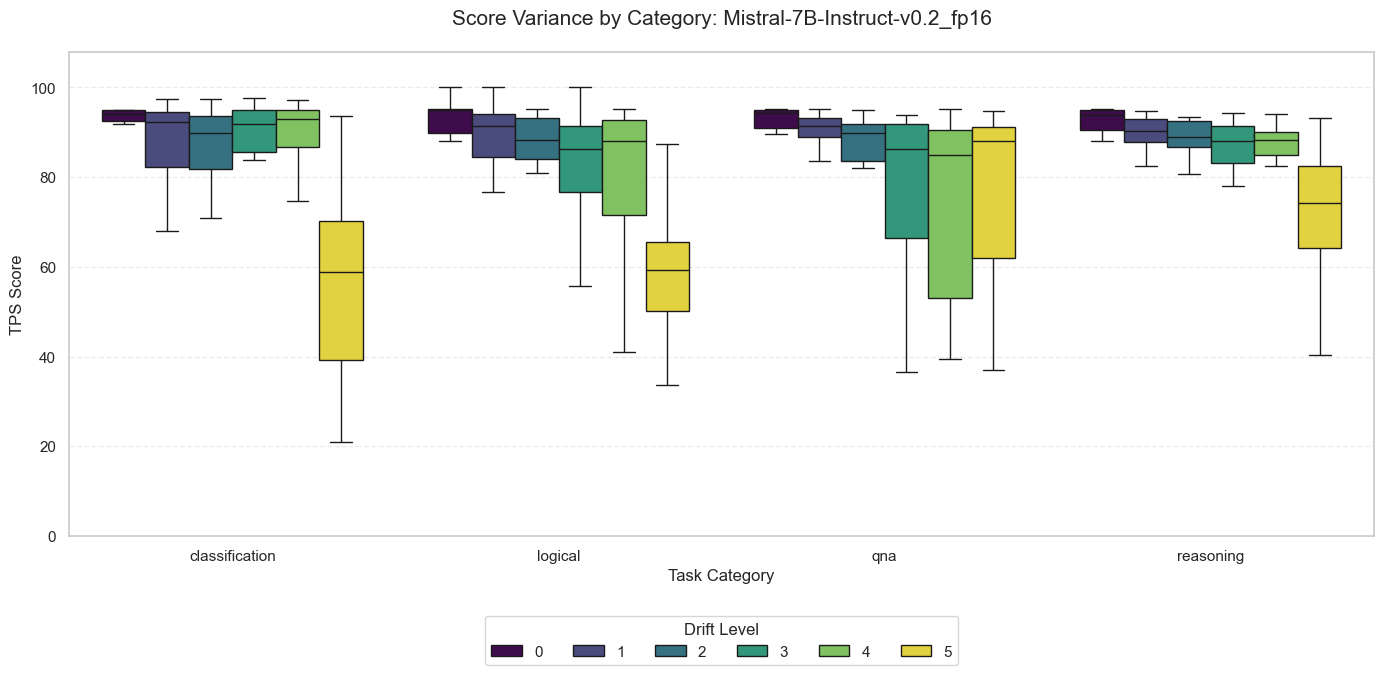

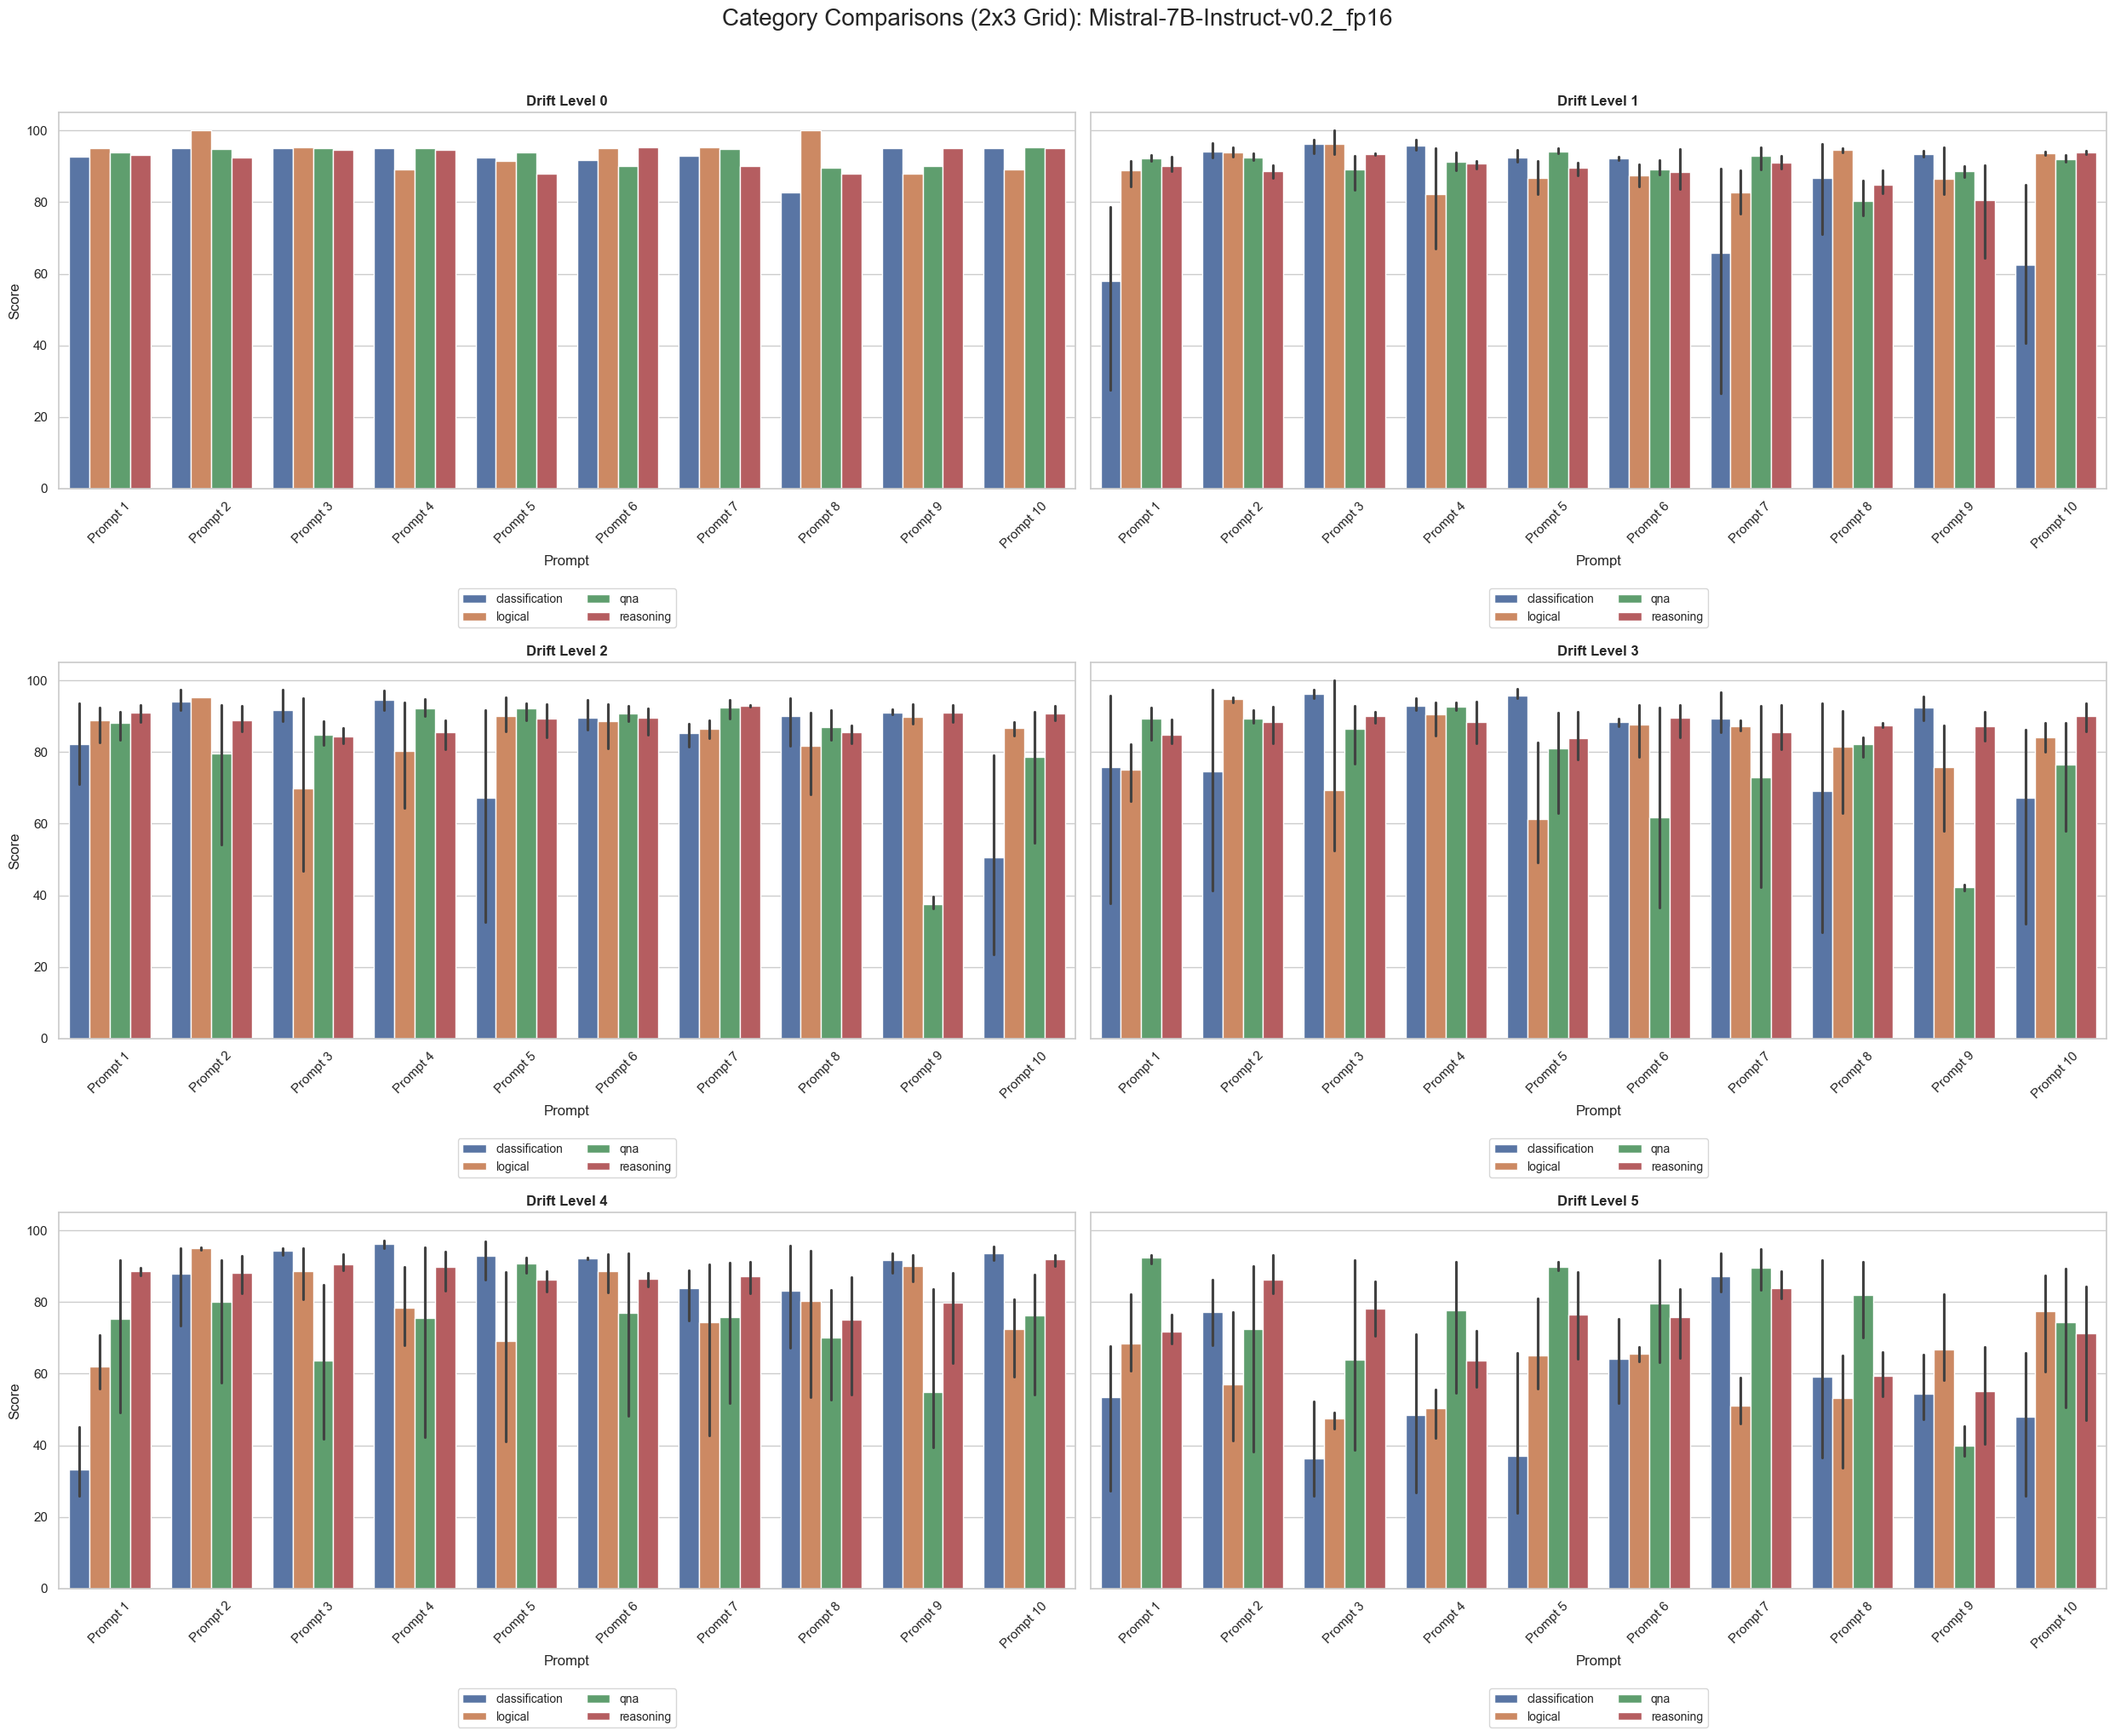

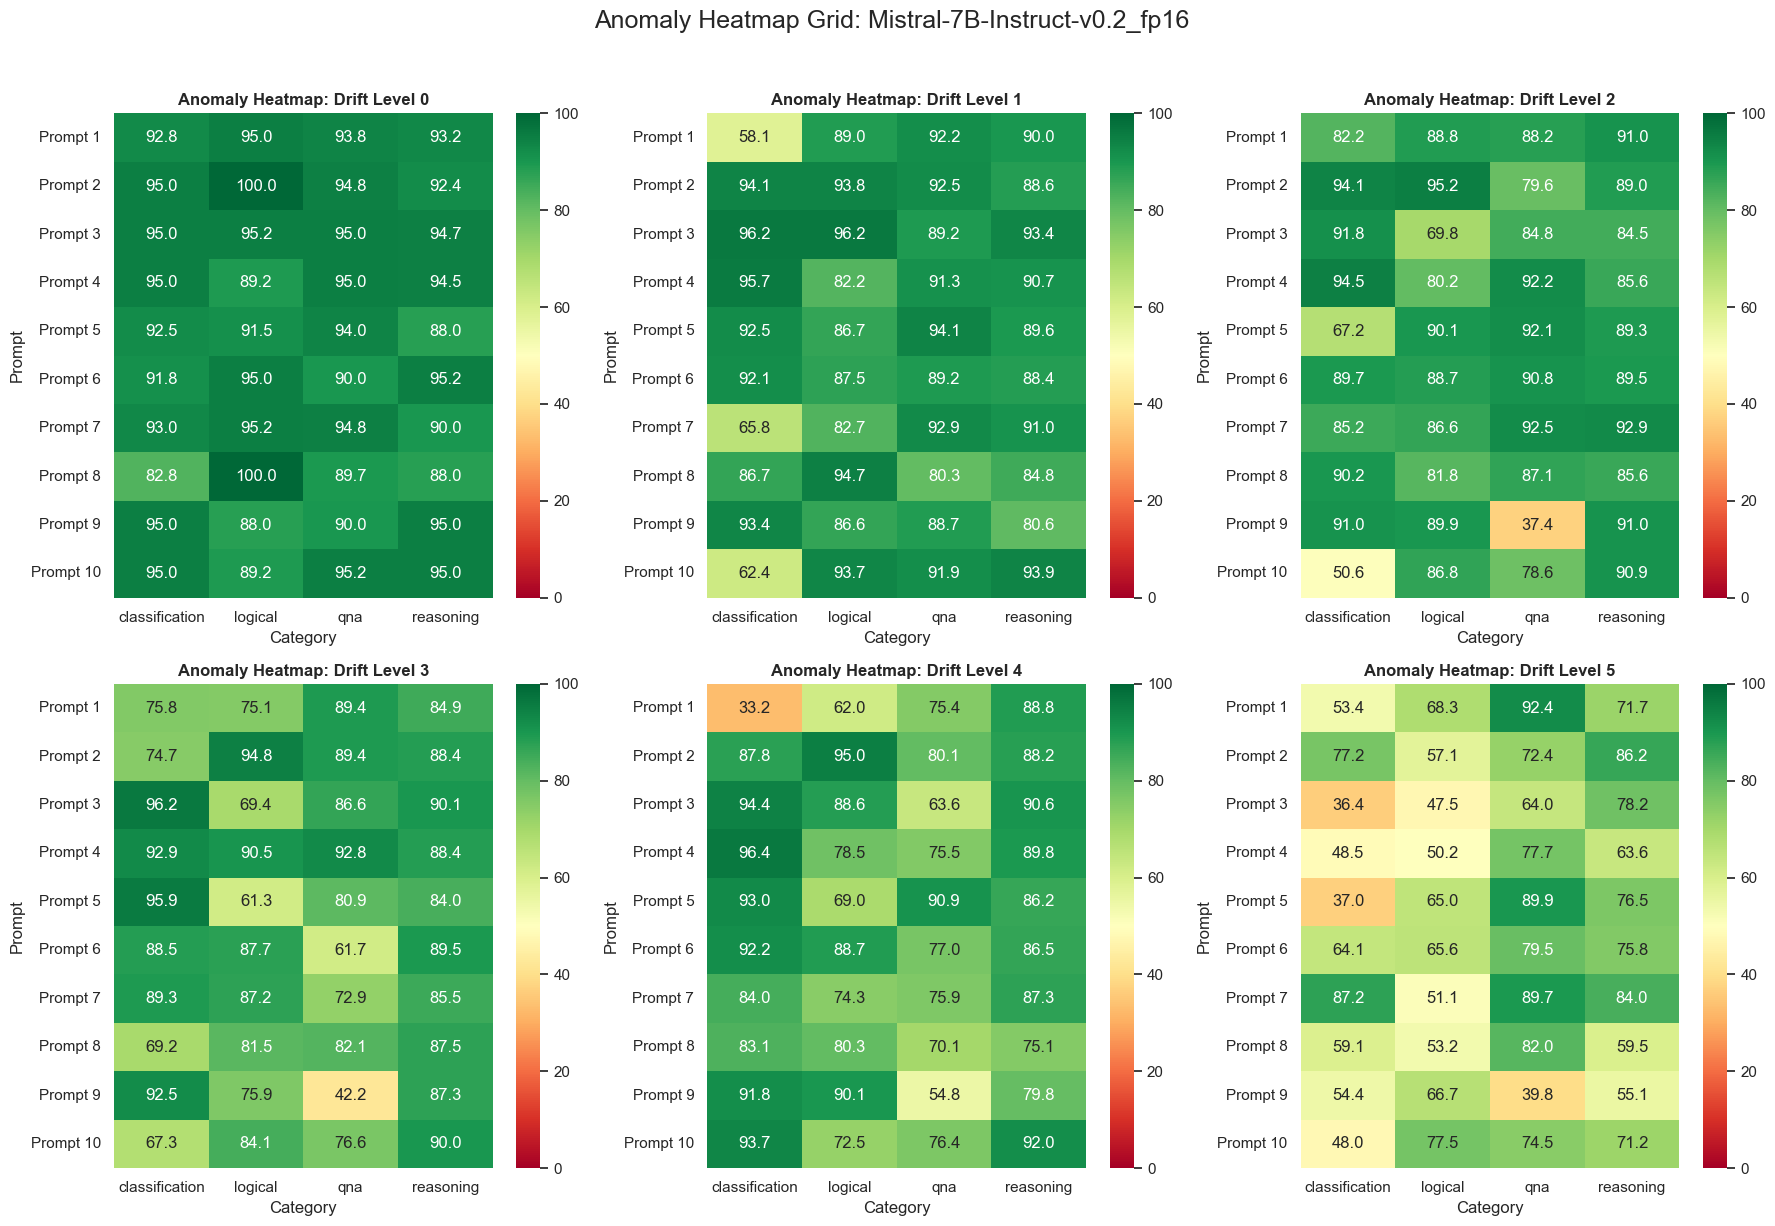

In [10]:
run_visualizations(r"../5_TPS_calculation/TPS")

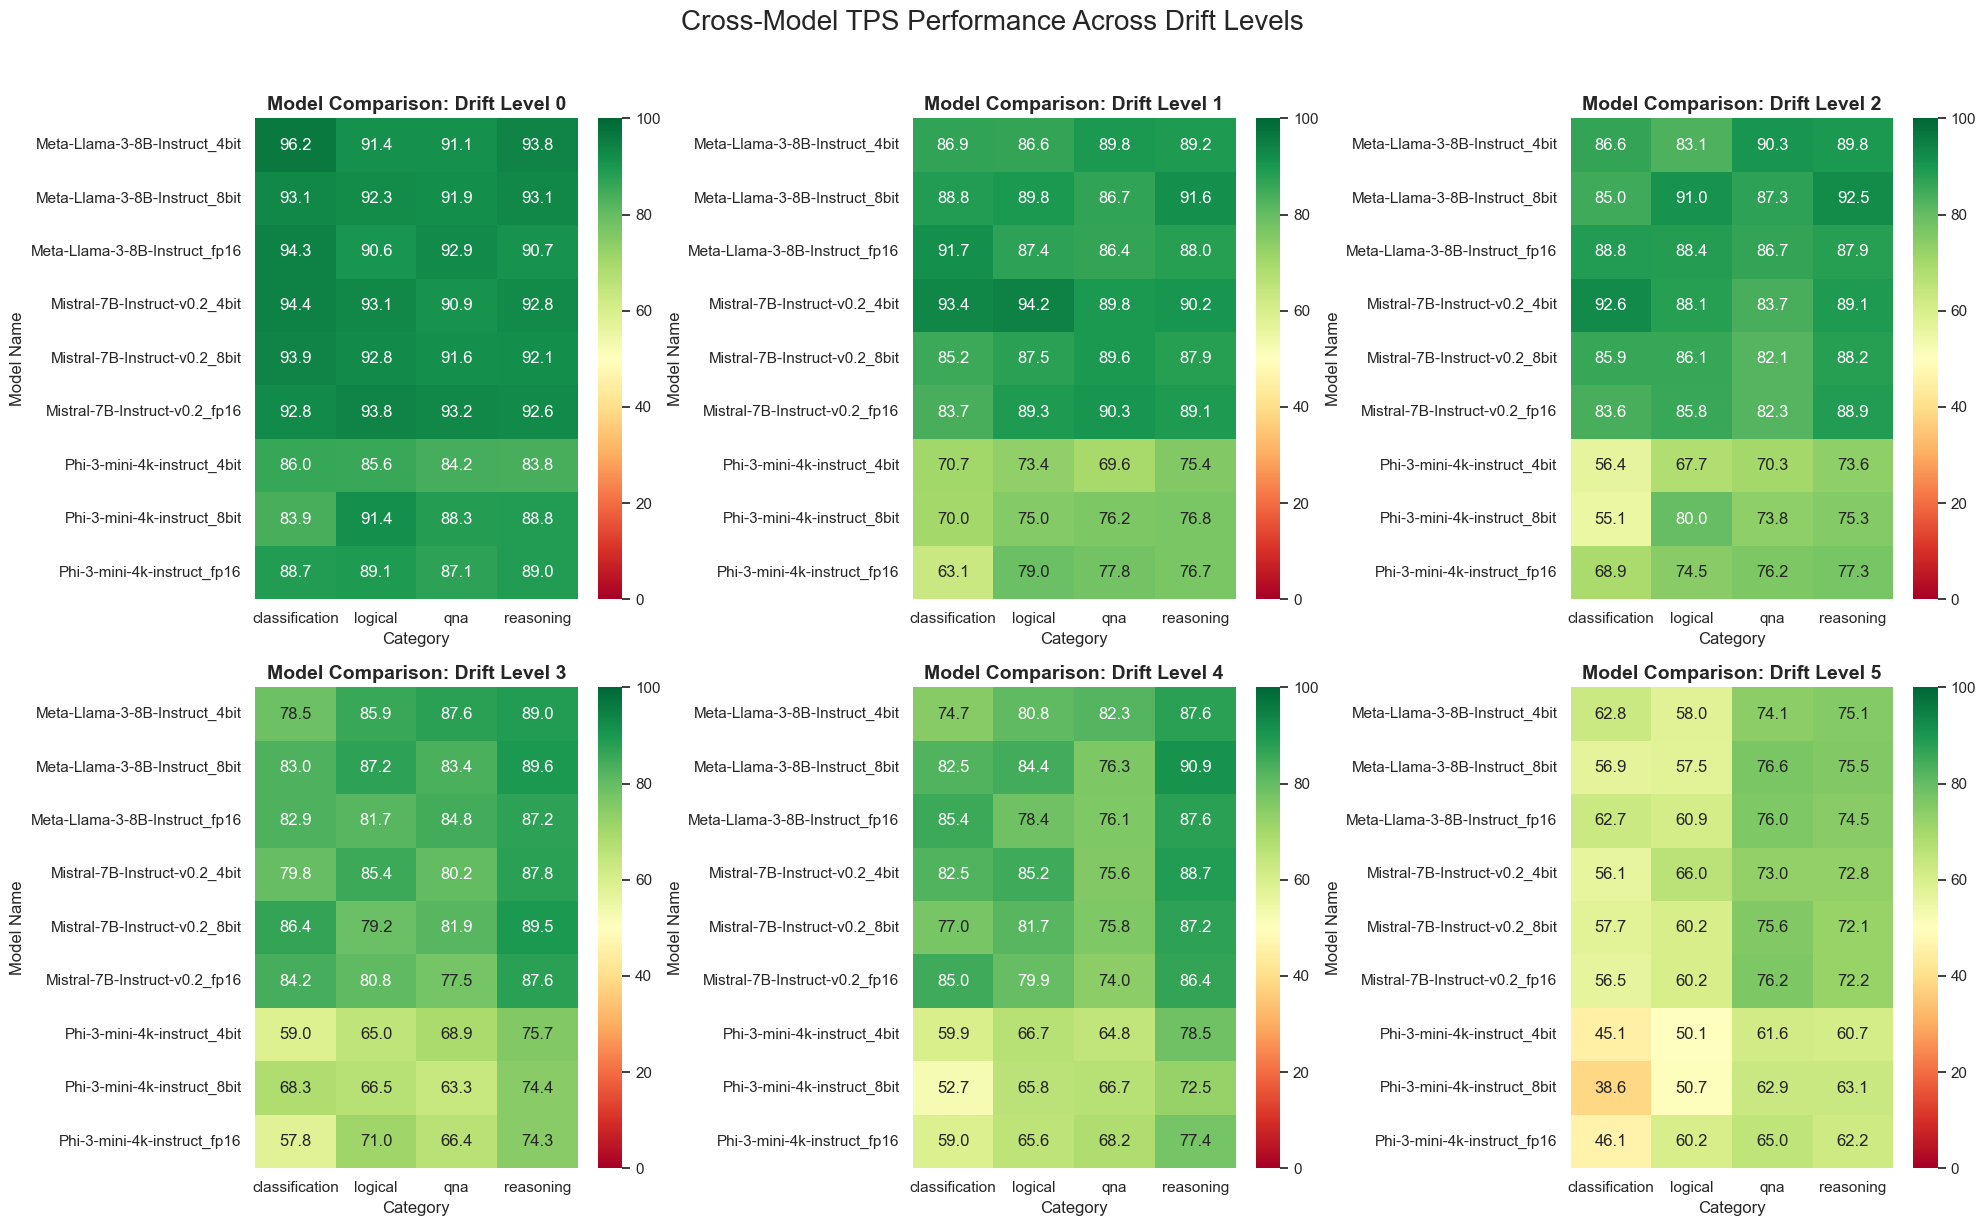

In [11]:
def plot_model_comparison_heatmaps(base_tps_dir):
    """Generates a 3x2 grid of heatmaps: Model Name (Y) vs Category (X)."""
    base_path = Path(base_tps_dir)
    all_model_data = []

    # 1. Collect and aggregate data from all models
    for json_file in base_path.glob("**/tps_scores_structured.json"):
        model_name = json_file.parent.name
        
        with open(json_file, 'r') as f:
            data = json.load(f)
            
        for entry in data:
            drift_lvl = entry.get("Drift_Level")
            for key, value in entry.items():
                if key == "Drift_Level" or value is None:
                    continue
                
                # Parse Category
                category = key.split(" (")[1].replace(")", "")
                
                # Calculate Average for this specific prompt/category
                if isinstance(value, dict):
                    valid_vals = [v for v in value.values() if v is not None]
                    avg_score = sum(valid_vals) / len(valid_vals) if valid_vals else 0
                else:
                    avg_score = value
                
                all_model_data.append({
                    "Model": model_name,
                    "Drift": drift_lvl,
                    "Category": category,
                    "Score": avg_score
                })

    df_all = pd.DataFrame(all_model_data)
    if df_all.empty:
        print("No data found to compare models.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    levels = sorted(df_all['Drift'].unique())

    for i, lvl in enumerate(levels):
        subset = df_all[df_all['Drift'] == lvl]
        
        # Pivot: Index is Model, Columns are Category, Values are Average of all 10 prompts
        pivot_df = subset.pivot_table(index="Model", columns="Category", values="Score", aggfunc='mean')
        
        sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", vmin=0, vmax=100, fmt=".1f", ax=axes[i])
        axes[i].set_title(f"Model Comparison: Drift Level {lvl}", fontweight='bold', fontsize=14)
        axes[i].set_ylabel("Model Name")
        axes[i].set_xlabel("Category")

    plt.suptitle("Cross-Model TPS Performance Across Drift Levels", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# To run this specific visualization:
plot_model_comparison_heatmaps(r"../5_TPS_calculation/TPS")

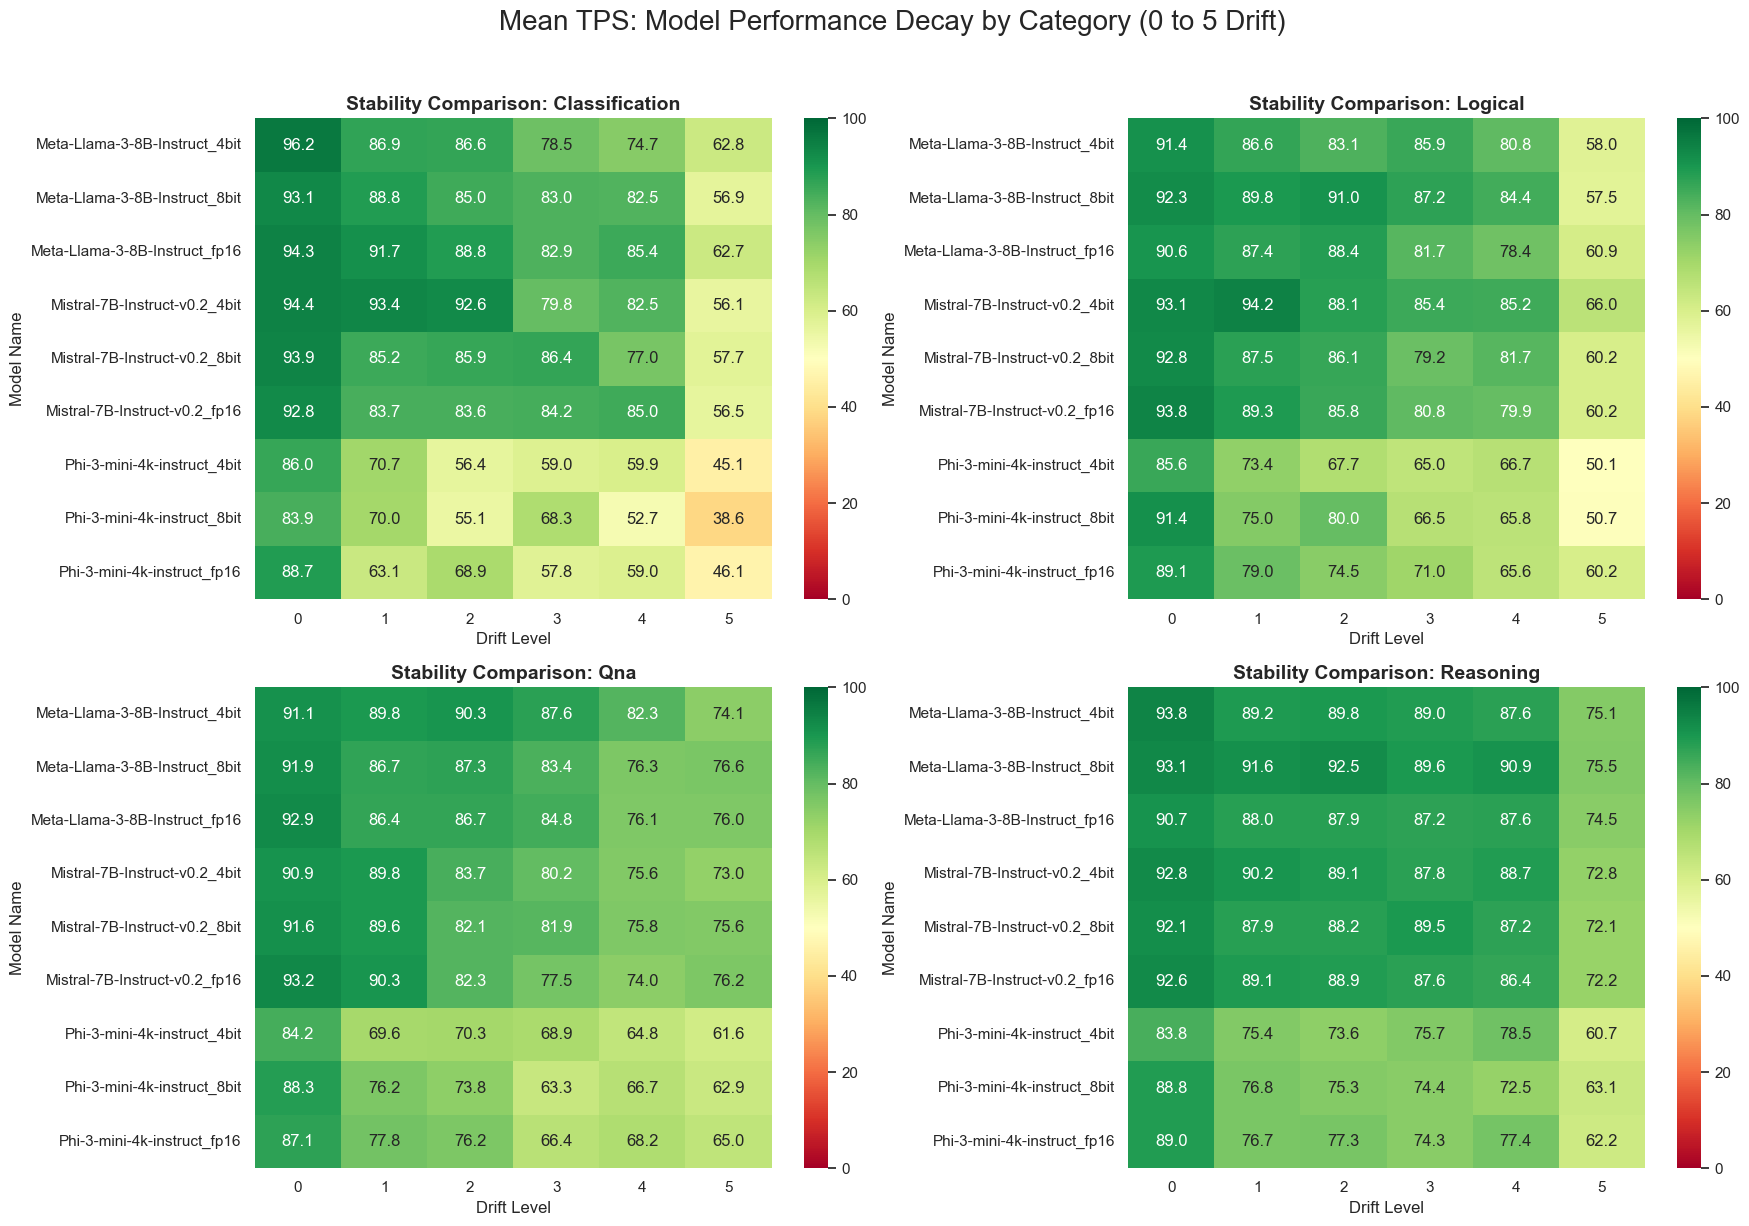

In [12]:
def plot_category_drift_heatmaps(base_tps_dir):
    """
    Generates a 2x2 grid of heatmaps (one per category).
    X-axis: Drift Level (0-5)
    Y-axis: Model Name
    Value: Average TPS of all 10 prompts.
    """
    base_path = Path(base_tps_dir)
    all_data = []

    # 1. Collect all model data
    for json_file in base_path.glob("**/tps_scores_structured.json"):
        model_name = json_file.parent.name
        with open(json_file, 'r') as f:
            data = json.load(f)
            
        for entry in data:
            drift_lvl = entry.get("Drift_Level")
            for key, value in entry.items():
                if key == "Drift_Level" or value is None:
                    continue
                
                # Parse Category from "Prompt X (Category)"
                category = key.split(" (")[1].replace(")", "")
                
                # Average variants (V1, V2, V3) or take single value (V0)
                if isinstance(value, dict):
                    valid_vals = [v for v in value.values() if v is not None]
                    avg_score = sum(valid_vals) / len(valid_vals) if valid_vals else 0
                else:
                    avg_score = value
                
                all_data.append({
                    "Model": model_name,
                    "Drift": drift_lvl,
                    "Category": category,
                    "Score": avg_score
                })

    df_all = pd.DataFrame(all_data)
    if df_all.empty:
        print("No data found for heatmaps.")
        return

    # 2. Setup 2x2 Grid
    categories = sorted(df_all['Category'].unique())
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    for i, cat in enumerate(categories):
        subset = df_all[df_all['Category'] == cat]
        
        # Pivot: X = Drift Level, Y = Model, Value = Average TPS
        pivot_df = subset.pivot_table(index="Model", columns="Drift", values="Score", aggfunc='mean')
        
        sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", vmin=0, vmax=100, fmt=".1f", ax=axes[i])
        axes[i].set_title(f"Stability Comparison: {cat.capitalize()}", fontweight='bold', fontsize=14)
        axes[i].set_xlabel("Drift Level")
        axes[i].set_ylabel("Model Name")

    plt.suptitle("Mean TPS: Model Performance Decay by Category (0 to 5 Drift)", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the category-drift comparison
plot_category_drift_heatmaps(r"../5_TPS_calculation/TPS")

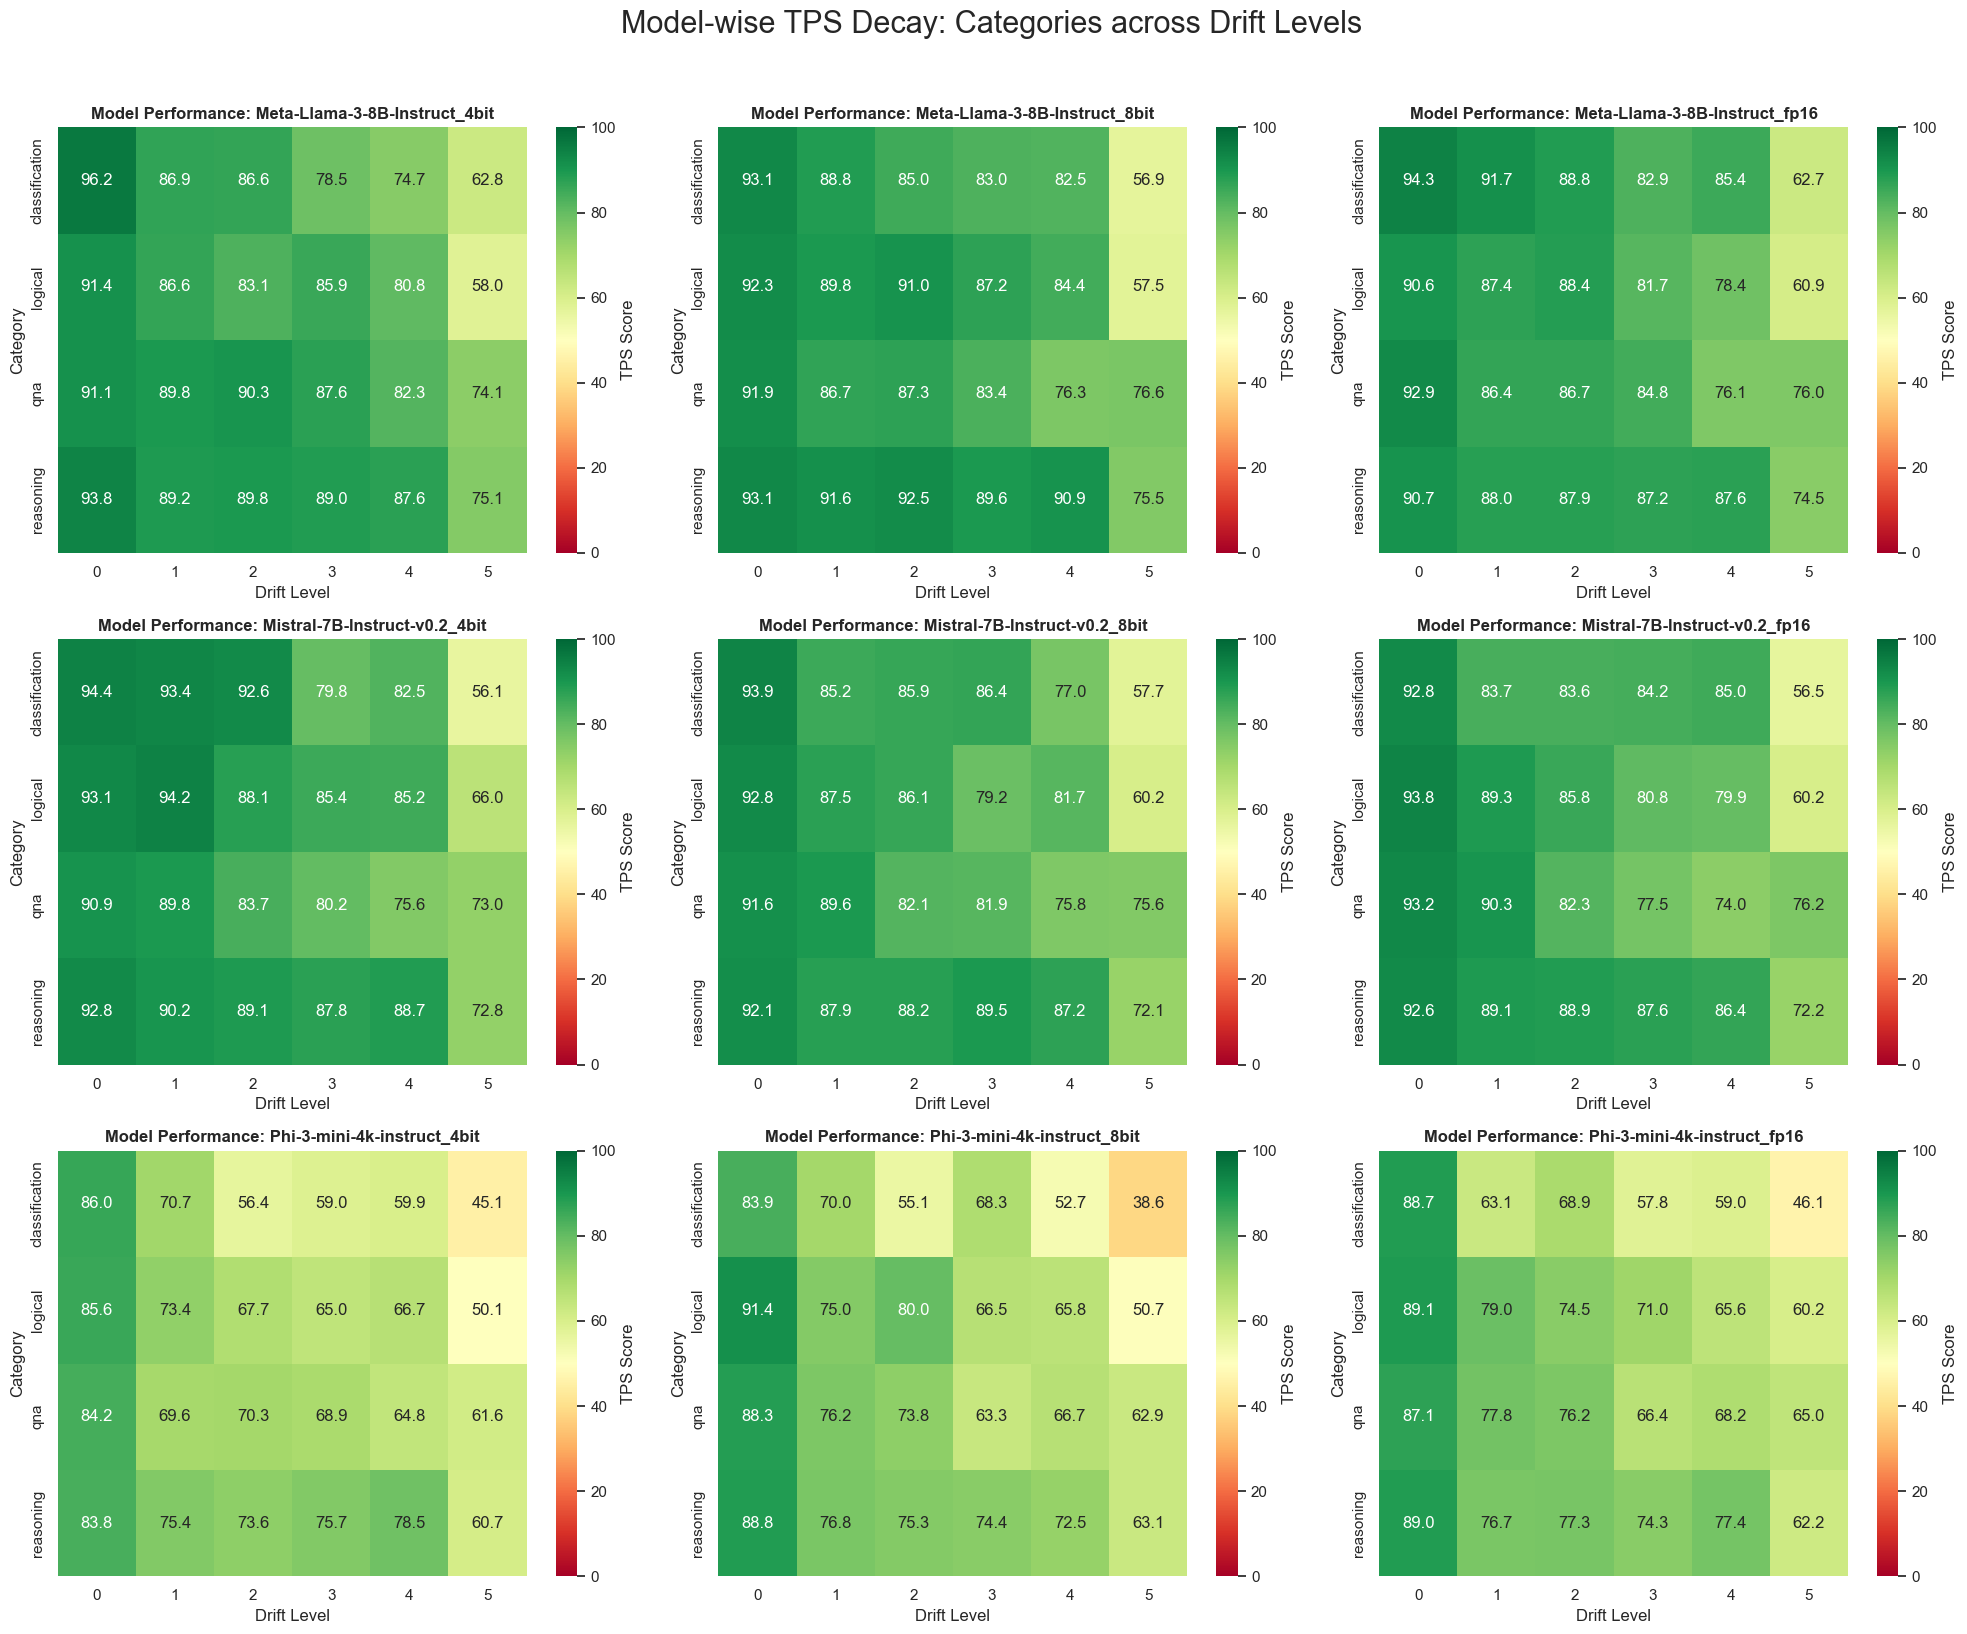

In [13]:
def plot_modelwise_tps_heatmaps(base_tps_dir):
    """
    Generates a 3x3 grid of heatmaps (one per model).
    X-axis: Drift Level (0-5)
    Y-axis: Category (Classification, Logical, QnA, Reasoning)
    Value: Average TPS of all 10 prompts.
    """
    base_path = Path(base_tps_dir)
    all_data = []

    # 1. Collect all model data
    for json_file in base_path.glob("**/tps_scores_structured.json"):
        model_name = json_file.parent.name
        with open(json_file, 'r') as f:
            data = json.load(f)
            
        for entry in data:
            drift_lvl = entry.get("Drift_Level")
            for key, value in entry.items():
                if key == "Drift_Level" or value is None:
                    continue
                
                # Parse Category
                category = key.split(" (")[1].replace(")", "")
                
                # Average variants (V1, V2, V3) or take single value (V0)
                if isinstance(value, dict):
                    valid_vals = [v for v in value.values() if v is not None]
                    avg_score = sum(valid_vals) / len(valid_vals) if valid_vals else 0
                else:
                    avg_score = value
                
                all_data.append({
                    "Model": model_name,
                    "Drift": drift_lvl,
                    "Category": category,
                    "Score": avg_score
                })

    df_all = pd.DataFrame(all_data)
    if df_all.empty:
        print("No data found for heatmaps.")
        return

    # 2. Setup 3x3 Grid
    models = sorted(df_all['Model'].unique())
    # Adjust grid size if you have more than 9 models, or use axes.flatten()
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    axes = axes.flatten()

    for i, model in enumerate(models):
        if i >= len(axes): break # Prevent error if more models than subplots
        
        subset = df_all[df_all['Model'] == model]
        
        # Pivot: X = Drift Level, Y = Category, Value = Average TPS
        pivot_df = subset.pivot_table(index="Category", columns="Drift", values="Score", aggfunc='mean')
        
        sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", vmin=0, vmax=100, fmt=".1f", ax=axes[i], 
                    cbar_kws={'label': 'TPS Score'})
        
        axes[i].set_title(f"Model Performance: {model}", fontweight='bold', fontsize=12)
        axes[i].set_xlabel("Drift Level")
        axes[i].set_ylabel("Category")

    # Hide any unused subplots in the 3x3 grid
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Model-wise TPS Decay: Categories across Drift Levels", fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the model-wise comparison
plot_modelwise_tps_heatmaps(r"../5_TPS_calculation/TPS")

# 3D Interaction Graph

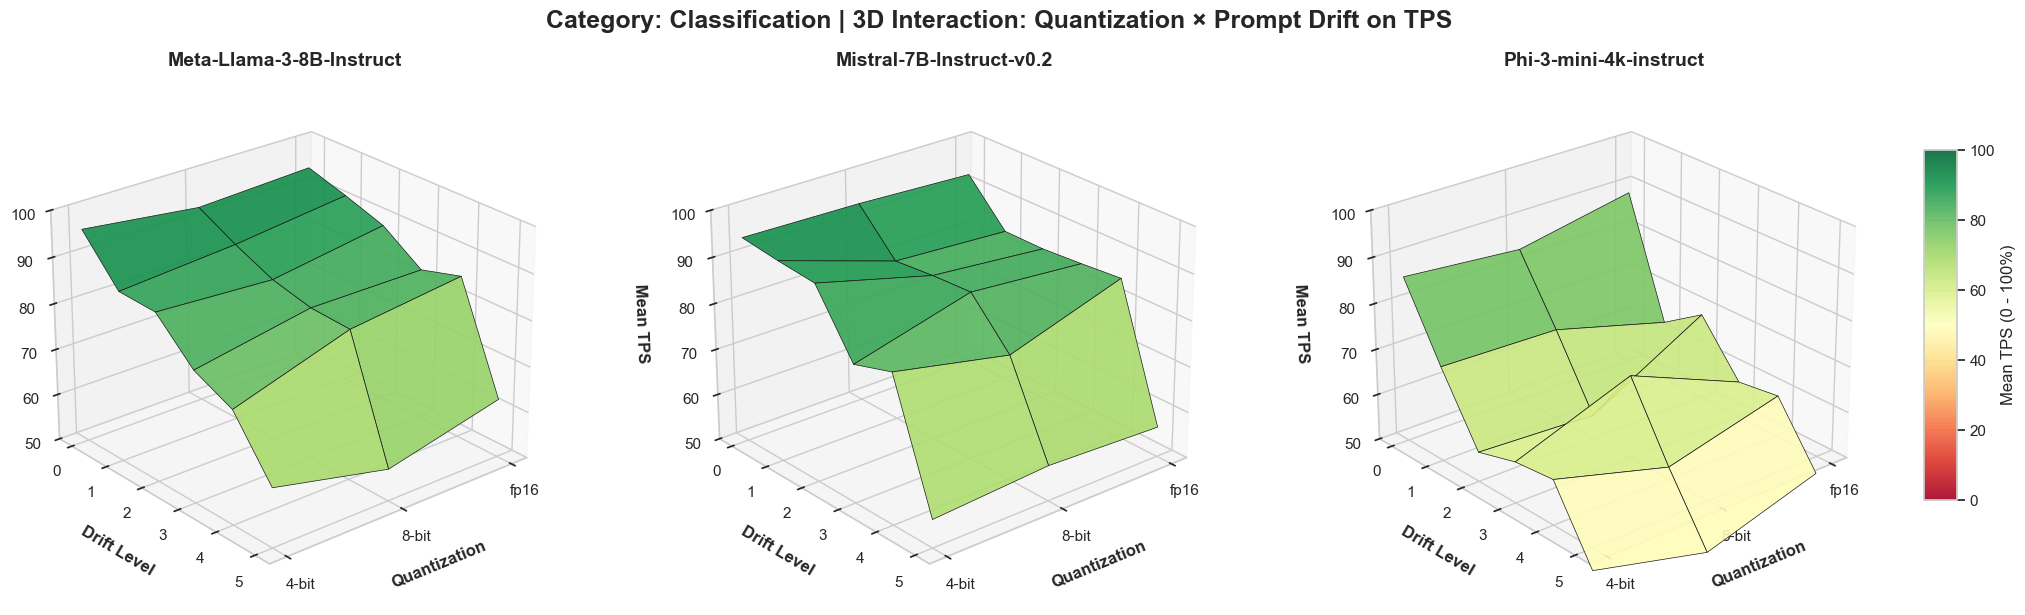

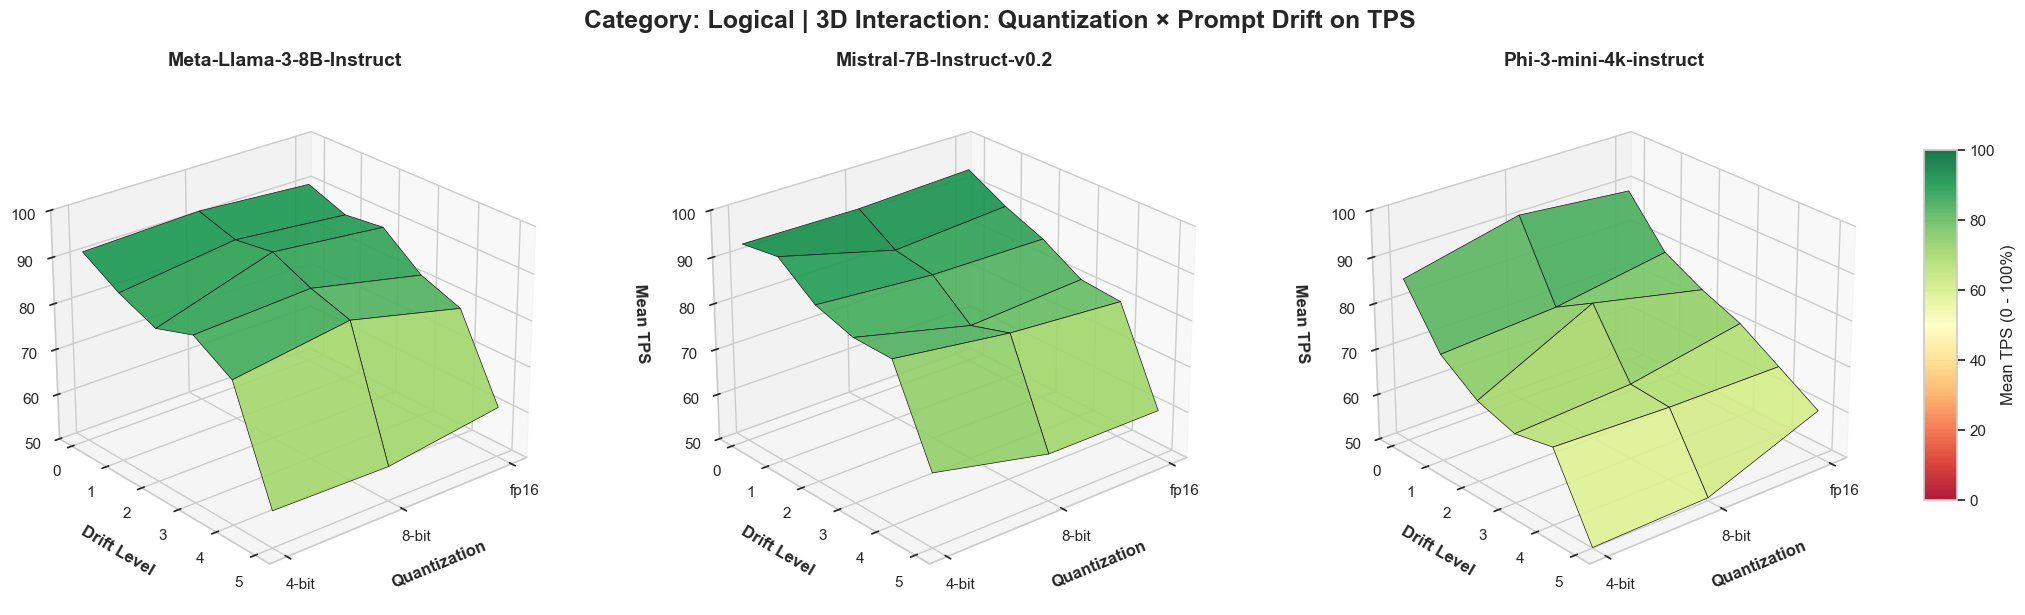

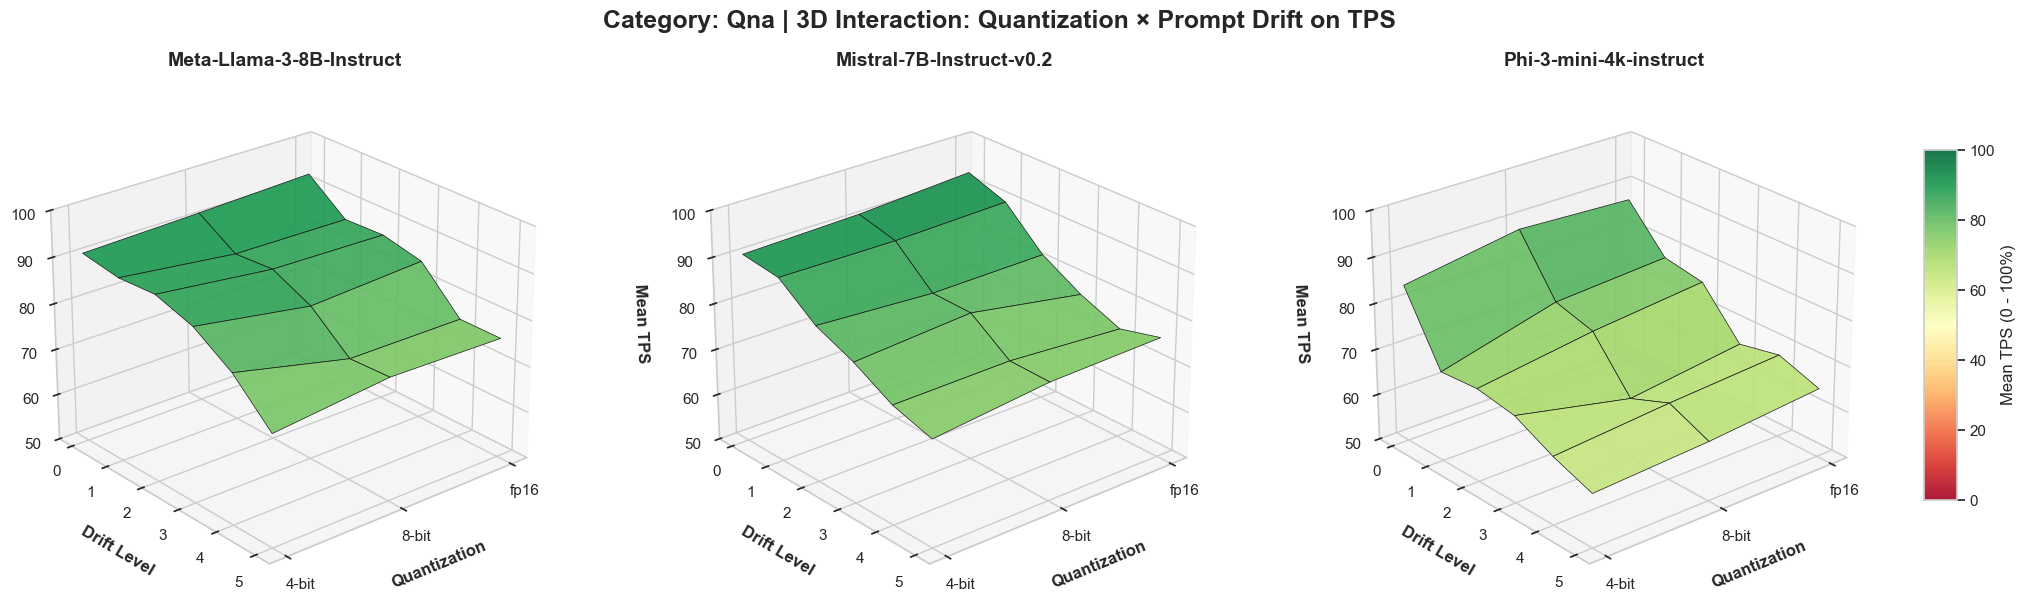

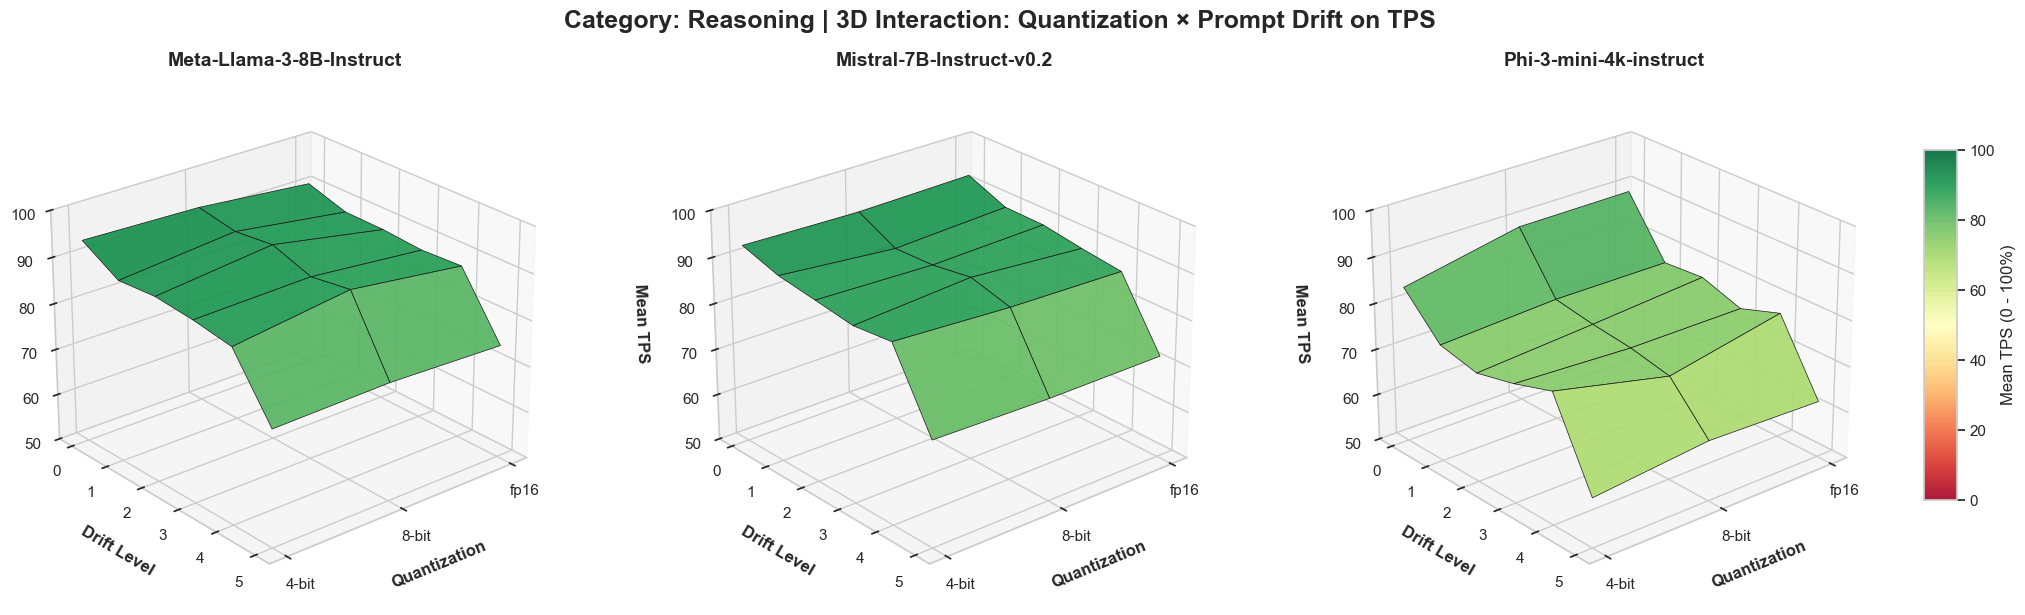

In [15]:

def plot_tps_3d_interaction(base_tps_dir):
    """
    Generates 4 separate figures (one for each Category).
    Each figure is a 1x3 grid of 3D surface plots showing: 
    Quantization × Drift → Mean TPS.
    """
    base_path = Path(base_tps_dir)
    all_scores = []

    # 1. Collect and Parse RAW prompt scores
    for json_file in base_path.rglob("tps_scores_structured.json"):
        model_string = json_file.parent.name
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
                
            base_model = model_string.rsplit('_', 1)[0]
            quant = model_string.rsplit('_', 1)[1]
                
            for entry in data:
                drift_lvl = entry.get("Drift_Level")
                for key, val in entry.items():
                    if key == "Drift_Level": continue
                    
                    # Extract the category from the prompt string (e.g., "Prompt 1 (classification)")
                    category_match = re.search(r'\((.*?)\)', key)
                    category = category_match.group(1).capitalize() if category_match else "Unknown"
                    
                    # Handle both scalar (Drift 0) and nested dict (Drift 1-5) TPS scores
                    if isinstance(val, dict):
                        score = sum(val.values()) / len(val)
                    else:
                        score = float(val)
                        
                    all_scores.append({
                        "Base_Model": base_model,
                        "Quantization": quant,
                        "Drift": drift_lvl,
                        "Category": category,
                        "Score": score
                    })
        except Exception as e:
            print(f"⚠️ Error loading {model_string}: {e}")

    df_scores = pd.DataFrame(all_scores)
    if df_scores.empty:
        print("❌ No prompt scores found.")
        return

    # Map Quantization to numerical values for the 3D X-axis
    quant_mapping = {'4bit': 0, '8bit': 1, 'fp16': 2}
    df_scores['Quant_Num'] = df_scores['Quantization'].map(quant_mapping)

    base_models = sorted(df_scores['Base_Model'].unique())
    categories = sorted(df_scores['Category'].unique())
    
    # 2. Generate a separate 3D Grid Figure for EACH Category
    for cat in categories:
        if cat == "Unknown": continue # Skip any malformed keys
        
        fig = plt.figure(figsize=(22, 7))
        subset_cat = df_scores[df_scores['Category'] == cat]

        for i, base_model in enumerate(base_models):
            ax = fig.add_subplot(1, len(base_models), i + 1, projection='3d')
            
            subset = subset_cat[subset_cat['Base_Model'] == base_model]
            if subset.empty: continue
                
            # Aggregate data to get the mean score for each (Drift, Quantization) pair
            agg_df = subset.groupby(['Drift', 'Quant_Num'])['Score'].mean().reset_index()
            
            # Pivot into a 2D grid required for plot_surface
            pivot = agg_df.pivot(index='Drift', columns='Quant_Num', values='Score')
            
            # Create Meshgrid for X (Quantization) and Y (Drift)
            X, Y = np.meshgrid(pivot.columns, pivot.index)
            Z = pivot.values
            
            # 3. Plot the 3D Surface
            surf = ax.plot_surface(X, Y, Z, cmap='RdYlGn', edgecolor='k', 
                                   linewidth=0.5, alpha=0.9, antialiased=True,
                                   vmin=0, vmax=100)
            
            # 4. Format Axes
            ax.set_title(f"{base_model}", fontsize=14, fontweight='bold', pad=10)
            
            ax.set_xlabel('Quantization', fontweight='bold', labelpad=10)
            ax.set_xticks([0, 1, 2])
            ax.set_xticklabels(['4-bit', '8-bit', 'fp16'])
            
            ax.set_ylabel('Drift Level', fontweight='bold', labelpad=10)
            drift_ticks = sorted(subset['Drift'].unique())
            ax.set_yticks(drift_ticks)
            ax.invert_yaxis() # Drift 0 in back, Drift 5 in front
            
            ax.set_zlabel('Mean TPS', fontweight='bold', labelpad=10)
            ax.set_zlim(50, 100) # Lock to 0-100%
            
            ax.view_init(elev=25, azim=230) 

        # 5. Global Formatting for the Current Category
        cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5]) 
        fig.colorbar(surf, cax=cbar_ax, label='Mean TPS (0 - 100%)')
        
        plt.suptitle(f"Category: {cat} | 3D Interaction: Quantization × Prompt Drift on TPS", 
                     fontsize=18, fontweight='bold', y=0.95)
        
        plt.subplots_adjust(left=0.05, right=0.9, top=0.85, bottom=0.1)
        plt.show()

# To run:
plot_tps_3d_interaction(r"../5_TPS_calculation/TPS")